# Physical Track Analysis — SLSNe Detection with Rubin LSST

Parallel to `analysis_multimodel_comparison.ipynb` (GP track).
Physical templates use MOSFiT posteriors (Gómez+2024), full SED synthesis via `synthesize_mag_at_z()`. Valid z=0.1–5.0.

GP canonical runs (260409) are untouched by this notebook.

**Reload flags:** Templates NO — Population NO — Mag grid NO (not used in physical path)

In [1]:
# ============================================================================
# CELL 1: Setup and configuration
# ============================================================================
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import healpy as hp
from pathlib import Path
from importlib import reload

def find_latest_npy(model, cadence, metric):
    """Find most recent datestamped z0.1-5.0 npy file for model/cadence/metric."""
    model_dir = get_output_dir('SLSNe', subdir=model)
    pattern = f'metric_values_{metric}_{model}_{cadence}_z0.1-5.0_*.npy'
    files = sorted(model_dir.glob(pattern), key=lambda f: f.stat().st_mtime)
    return files[-1] if files else None

def find_latest_z_values(model, cadence):
    """Find most recent datestamped z0.1-5.0 z_values npy file."""
    model_dir = get_output_dir('SLSNe', subdir=model)
    pattern = f'z_values_{model}_{cadence}_z0.1-5.0_*.npy'
    files = sorted(model_dir.glob(pattern), key=lambda f: f.stat().st_mtime)
    return files[-1] if files else None

# --- Repo path ---
REPO = Path('/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric')
sys.path.insert(0, str(REPO / 'py_files'))
from slsn_metrics.paths import get_shared_output_dir, get_output_dir, get_rate_csv_path
import slsn_metrics.diagnostics as diag_mod
reload(diag_mod)
from slsn_metrics.diagnostics import (
    plot_population_rate_vs_redshift,
    plot_healpix_efficiency,
)

# --- Configuration ---
MODELS = [
    'naive_physical',
    'o_dependent_physical',
    'fe_dependent_physical',
]
CADENCES = [
    'baseline_v5.1.1_10yrs',
    'baseline_v5.3.0_10yrs',
]
SURVEY_YEARS = 10
Z_MIN, Z_MAX = 0.1, 5.0

# --- Paths ---
SHARED_DIR   = get_shared_output_dir('SLSNe')
ADAPTIVE_DIR = REPO / 'output/SLSNe/adaptive'

# --- Load adaptive efficiency results ---
# Each model has one adaptive_results.csv with columns:
#   z_lo, z_hi, cadence, metric, n_events, n_success, efficiency, sigma
print('=== Adaptive Results Check ===')
ADAPTIVE = {}
for model in MODELS:
    csv = ADAPTIVE_DIR / f'{model}_adaptive_results.csv'
    if csv.exists():
        df = pd.read_csv(csv)
        ADAPTIVE[model] = df
        zmax = df['z_hi'].max()
        n_bins = df['z_hi'].nunique()
        print(f'  OK  {model}: {n_bins} z-bins, z_max={zmax:.1f}')
    else:
        print(f'  MISSING  {model}: {csv}')

print(f'\nLoaded {len(ADAPTIVE)}/{len(MODELS)} adaptive result files')

# -----------------------------------------------------------------------
# Canonical lookup dicts — defined ONCE here, used throughout notebook.
# Never redefine these in downstream cells.
# -----------------------------------------------------------------------

MODEL_LABELS = {
    'naive_physical':        'Naive SFR',
    'o_dependent_physical':  'O-dependent',
    'fe_dependent_physical': 'Fe-dependent',
}

MODEL_COLORS = {
    'naive_physical':        '#808080',   #2196F3',   # blue
    'o_dependent_physical':  '#BF6360',   #'#FF9800',   # orange
    'fe_dependent_physical': '#377E7F',   #'#4CAF50',   # green
}


CADENCE_LABELS = {
    'baseline_v5.1.1_10yrs':     'Baseline v5.1.1',
    'baseline_v5.3.0_10yrs':     'Baseline v5.3.0',
    'noroll_v5.0.0_10yrs':       'No Roll',
    'poor_weather_v5.0.1_10yrs': 'Poor Weather',
}

MODEL_LINESTYLES = {
    'naive_physical':        '-',      # solid
    'o_dependent_physical':  '--',     # dashed
    'fe_dependent_physical': '-.',  # dash dot
}

# short key → full MAF class name (used for npy loading, CSV filtering)
METRIC_MAP = {
    'detect':       'SLSN_Detect_Physical_Metric',
    'characterize': 'SLSN_Characterize_Physical_Metric',
    'villar':       'SLSN_Villar_Physical_Metric',
    'elasticc':     'SLSN_ELAsTiCC_Metric',
    'spectrigger':  'SLSN_SpecTrigger_Physical_Metric',
}
# full MAF class name → display label (derived from METRIC_MAP, single source of truth)
METRIC_LABELS = {v: k.replace('_', ' ').title() for k, v in METRIC_MAP.items()}
METRIC_LABELS['SLSN_ELAsTiCC_Metric']             = 'ELAsTiCC'
METRIC_LABELS['SLSN_SpecTrigger_Physical_Metric'] = 'SpecTrigger'

print('Canonical dicts loaded: MODEL_LABELS, MODEL_COLORS, CADENCE_LABELS, METRIC_MAP, METRIC_LABELS')

=== Adaptive Results Check ===
  OK  naive_physical: 48 z-bins, z_max=4.9
  OK  o_dependent_physical: 49 z-bins, z_max=5.0
  OK  fe_dependent_physical: 49 z-bins, z_max=5.0

Loaded 3/3 adaptive result files
Canonical dicts loaded: MODEL_LABELS, MODEL_COLORS, CADENCE_LABELS, METRIC_MAP, METRIC_LABELS


✓ Saved rate evolution plot → /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/rate_evolution_comparison_physical.png


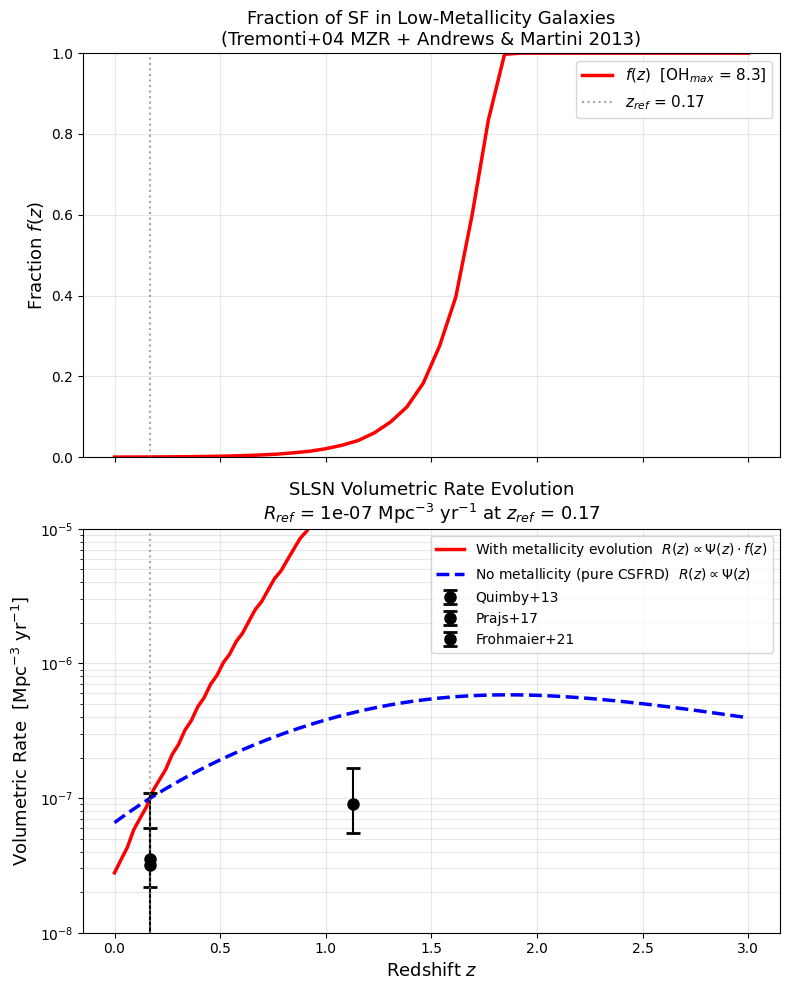

Saved: rate_evolution_comparison_physical.png


In [2]:
# ============================================================================
# CELL 2: Rate evolution comparison — analytical R(z) curves (model-agnostic)
# Shows SFR x metallicity fraction vs pure-SFR curve + observed measurements.
# No population needed — call once for all models.
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_rate_evolution_comparison

out_rate_fig = get_output_dir('SLSNe') / 'rate_evolution_comparison_physical.png'
plot_rate_evolution_comparison(save_path=out_rate_fig)
print(f'Saved: {out_rate_fig.name}')


In [3]:
# Cell 3 - AUDIT TABLE — summary of figure above
# Rate evolution: observed data points used in Cell A's R(z) comparison
# Analytical curves (SFR x metallicity_fraction) are not stored in this namespace.
# Shown here: the 3 published observed rate measurements plotted against the models.
from slsn_metrics.population import OBSERVED_RATES as _obs2
import pandas as pd
_tbl2 = pd.DataFrame(_obs2)
_tbl2['rate_Gpc3yr'] = (_tbl2['rate'] * 1e9).round(1)
_tbl2['err_low_Gpc3yr'] = (_tbl2['err_low'] * 1e9).round(1)
_tbl2['err_high_Gpc3yr'] = (_tbl2['err_high'] * 1e9).round(1)
print("Observed SLSN-I rate measurements plotted in Cell A (rate_evolution_comparison)")
print(_tbl2[['ref','z','rate_Gpc3yr','err_low_Gpc3yr','err_high_Gpc3yr']].to_string(index=False))

Observed SLSN-I rate measurements plotted in Cell A (rate_evolution_comparison)
         ref    z  rate_Gpc3yr  err_low_Gpc3yr  err_high_Gpc3yr
   Quimby+13 0.17         32.0            26.0             77.0
    Prajs+17 1.13         91.0            36.0             76.0
Frohmaier+21 0.17         35.0            13.0             25.0


In [4]:
# ============================================================================
# CELL 4: Build per-model efficiency data from adaptive results CSV
# No population pkl or .npy loading needed — adaptive CSV has everything.
# Builds pop_data dict compatible with downstream plotting cells.
# METRIC_MAP and METRIC_KEYS come from Cell 1 — do not redefine here.
# ============================================================================

METRIC_KEYS = list(METRIC_MAP.keys())

pop_data = {}

for model in MODELS:
    if model not in ADAPTIVE:
        print(f'Skipping {model} — no adaptive results')
        continue

    df = ADAPTIVE[model]
    print(f'\n{model}:')

    metric_arrays = {m: {} for m in METRIC_KEYS}
    z_bins = sorted(df[['z_lo','z_hi']].drop_duplicates().values.tolist())

    for short, full in METRIC_MAP.items():
        for cadence in CADENCES:
            sub = df[(df['metric']==full) & (df['cadence']==cadence)].copy()
            if sub.empty:
                metric_arrays[short][cadence] = None
                continue
            eff_dict = dict(zip(
                zip(sub['z_lo'], sub['z_hi']),
                sub['efficiency']
            ))
            n_dict = dict(zip(
                zip(sub['z_lo'], sub['z_hi']),
                sub['n_events']
            ))
            metric_arrays[short][cadence] = {
                'z_bins':     [(z0,z1) for z0,z1 in z_bins],
                'efficiency': [float(eff_dict.get((z0,z1), np.nan)) for z0,z1 in z_bins],
                'n_events':   [int(n_dict.get((z0,z1), 0))          for z0,z1 in z_bins],
            }

    z_lo_arr  = np.array([b[0] for b in z_bins])
    z_hi_arr  = np.array([b[1] for b in z_bins])
    z_centers = 0.5 * (z_lo_arr + z_hi_arr)

    pop_data[model] = {
        'z_bins':      z_bins,
        'z_lo':        z_lo_arr,
        'z_hi':        z_hi_arr,
        'z_centers':   z_centers,
        'detect':       metric_arrays['detect'],
        'characterize': metric_arrays['characterize'],
        'spectrigger':  metric_arrays['spectrigger'],
        'villar':       metric_arrays['villar'],
        'elasticc':     metric_arrays['elasticc'],
    }
    print(f'  z-bins: {len(z_bins)}, cadences with data: {CADENCES}')

print('\n=== Adaptive efficiency data loaded for all models ===')


naive_physical:
  z-bins: 48, cadences with data: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs']

o_dependent_physical:
  z-bins: 49, cadences with data: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs']

fe_dependent_physical:
  z-bins: 49, cadences with data: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs']

=== Adaptive efficiency data loaded for all models ===


Loading physical templates...
[load_magnitude_grid] Loaded with filters: ['u', 'g', 'r', 'i', 'z', 'y'], shape=(265, 100, 79), convention=apparent ✓
Templates loaded: 265 events

=== Population diagnostics: naive_physical ===
[LOAD] Loaded 2034661 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_naive_physical.pkl
[LOAD] z-filtered to 2034661 events (z_min=0.1, z_max=5.0)


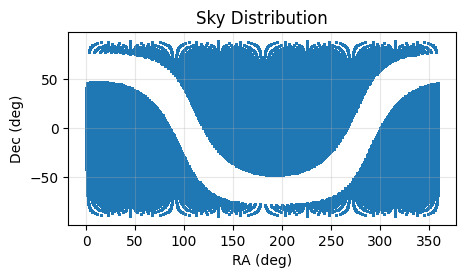

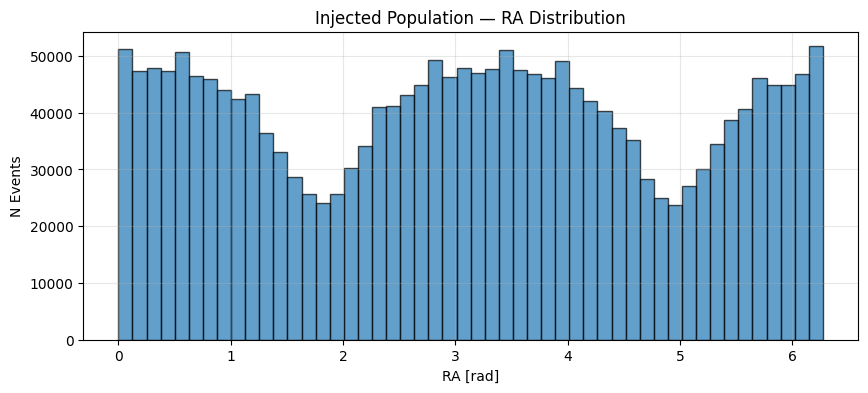

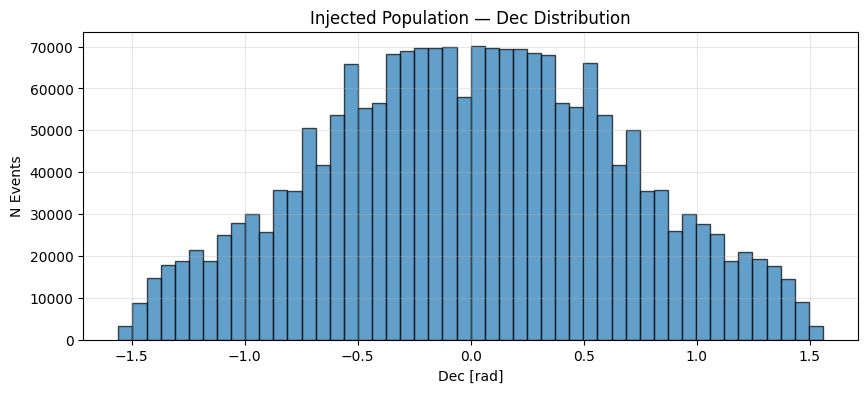

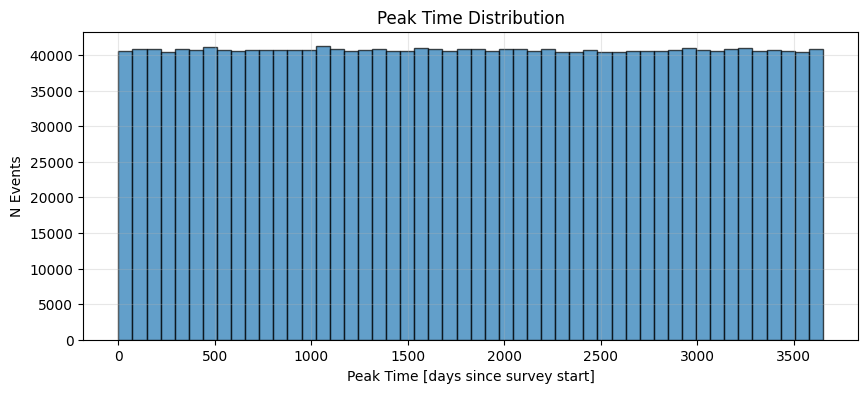

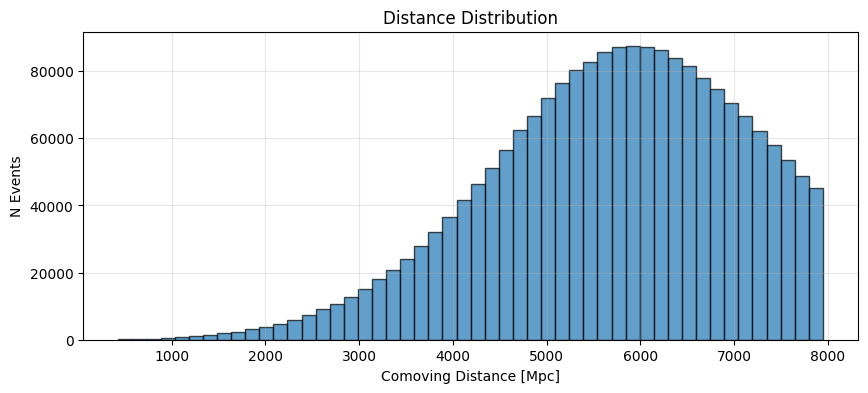

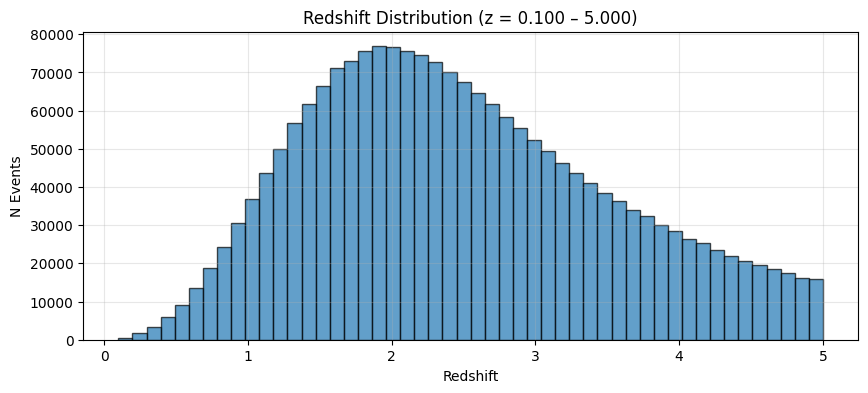

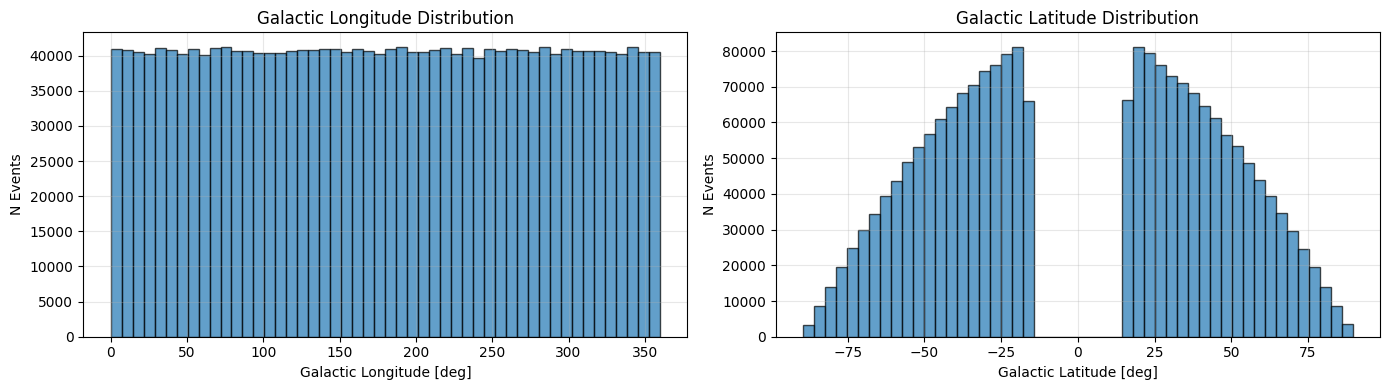

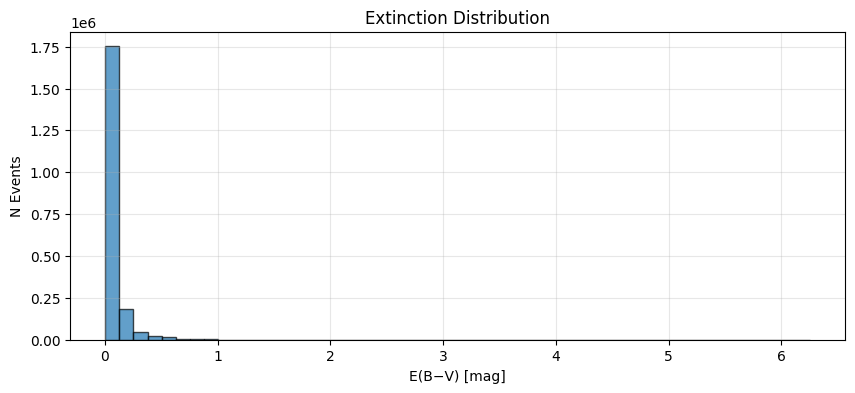

  Diagnostics saved to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/naive_physical

=== Population diagnostics: o_dependent_physical ===
[LOAD] Loaded 7033255 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_o_dependent_physical.pkl
[LOAD] z-filtered to 7033255 events (z_min=0.1, z_max=5.0)


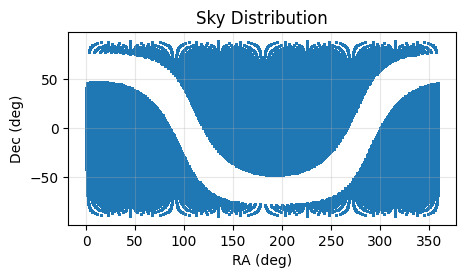

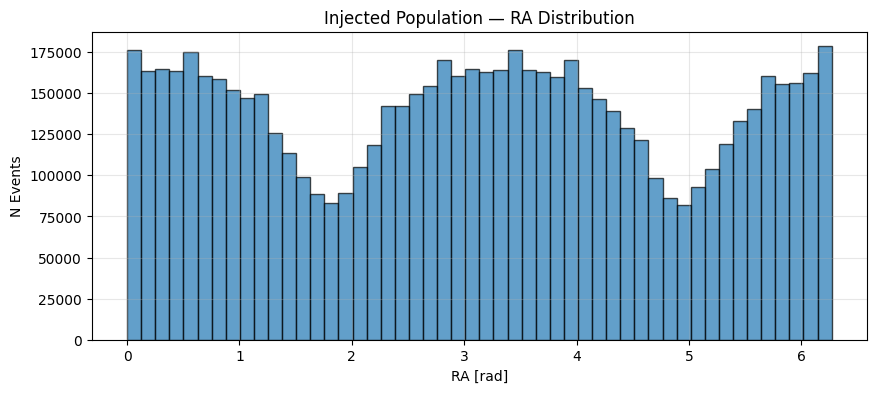

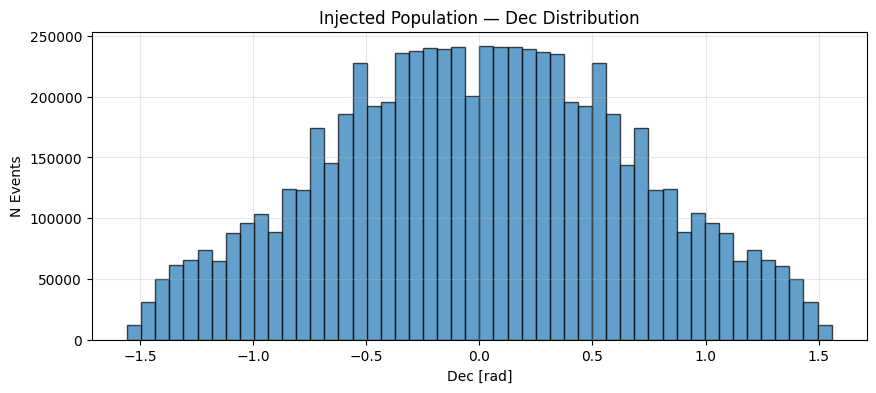

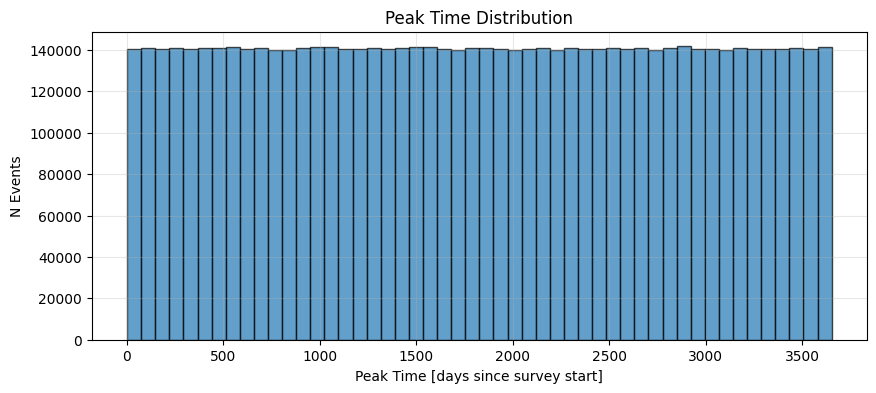

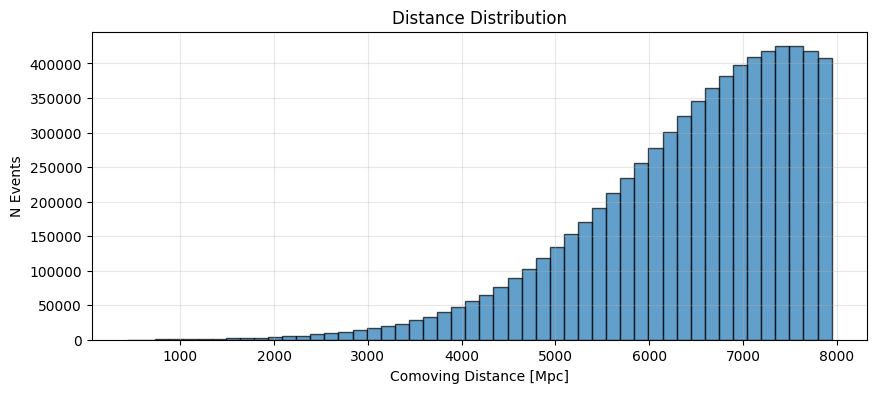

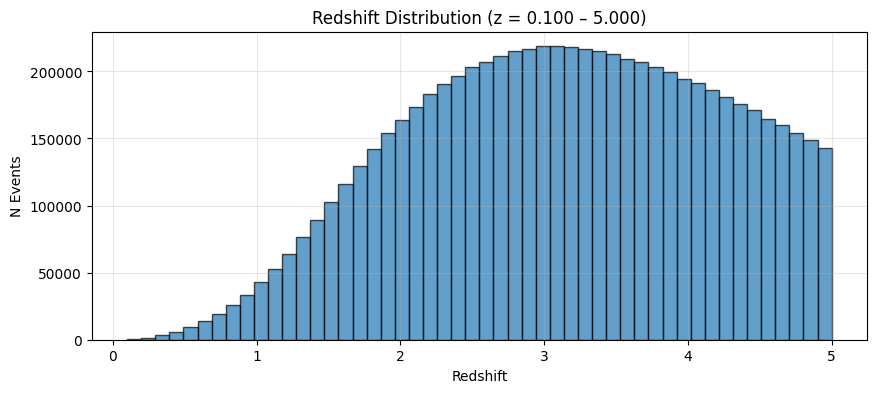

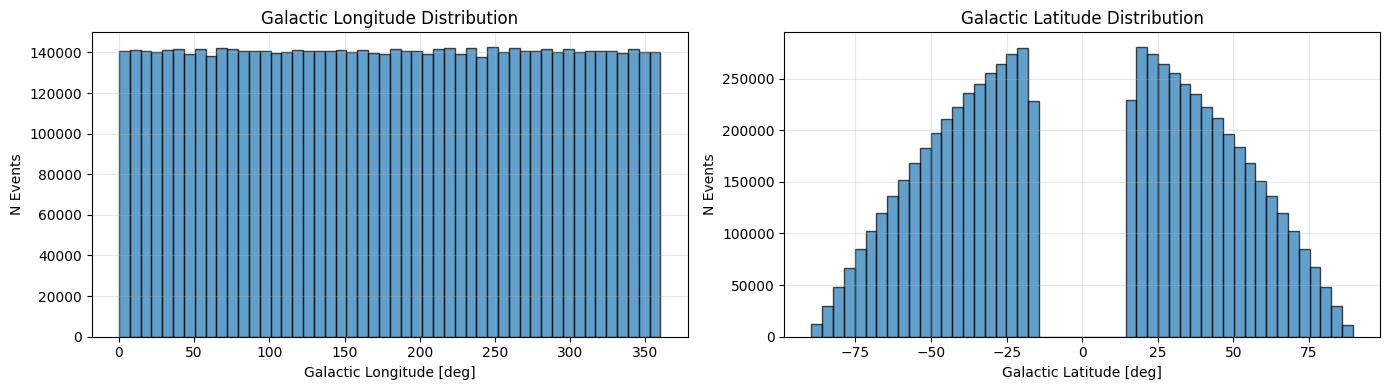

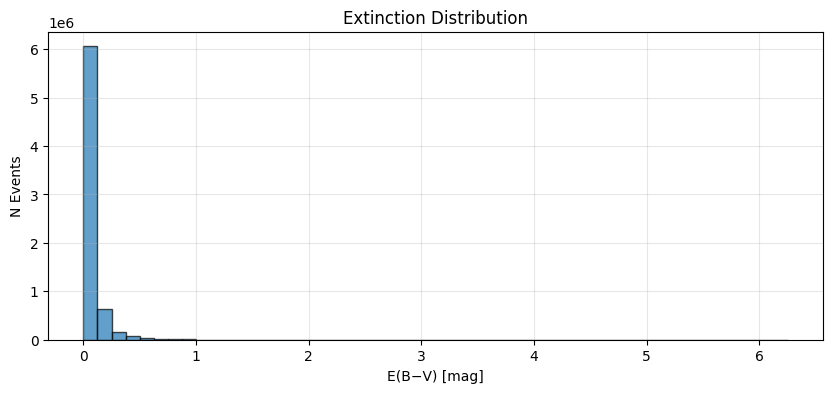

  Diagnostics saved to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/o_dependent_physical

=== Population diagnostics: fe_dependent_physical ===
[LOAD] Loaded 14432797 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_fe_dependent_physical.pkl
[LOAD] z-filtered to 14432797 events (z_min=0.1, z_max=5.0)


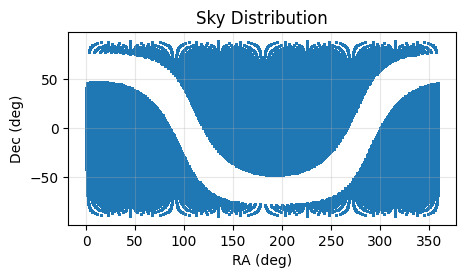

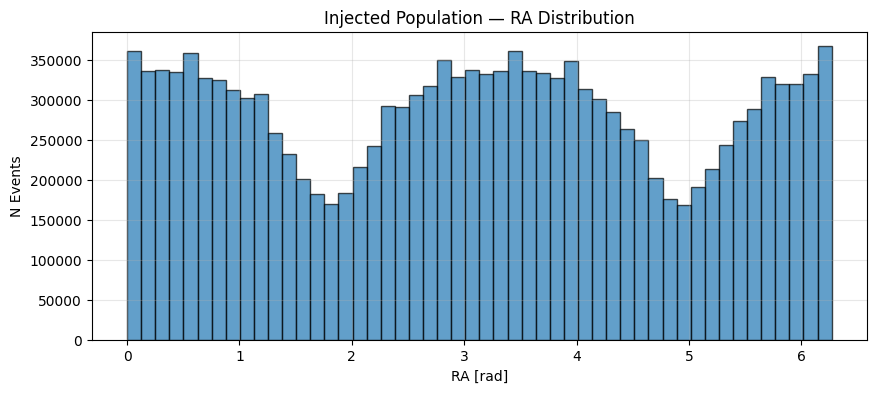

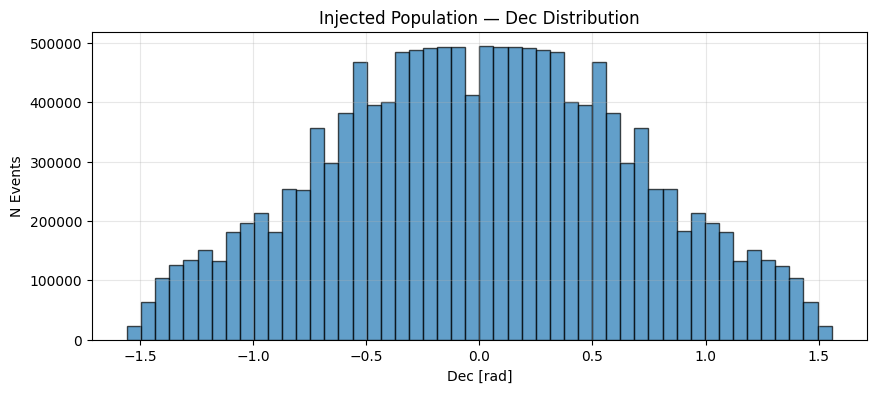

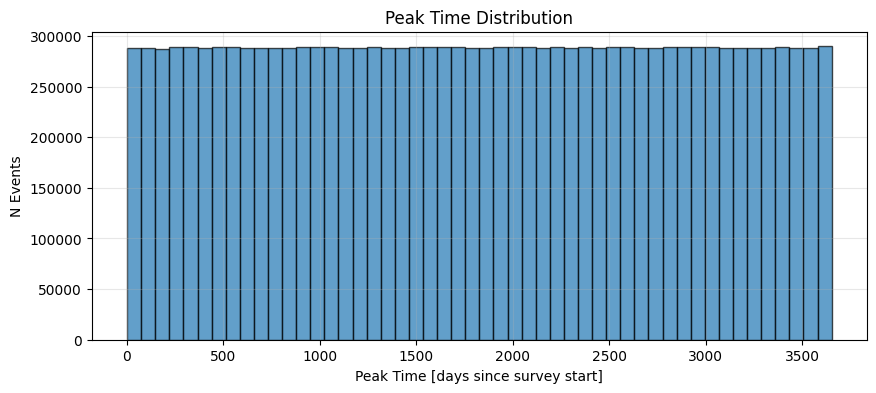

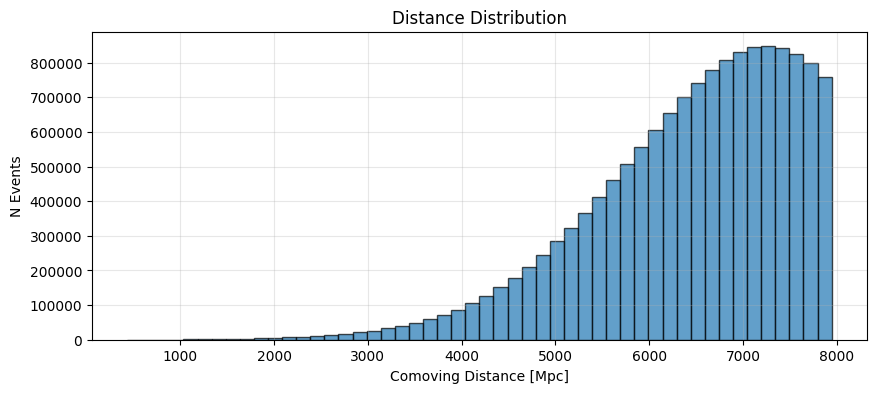

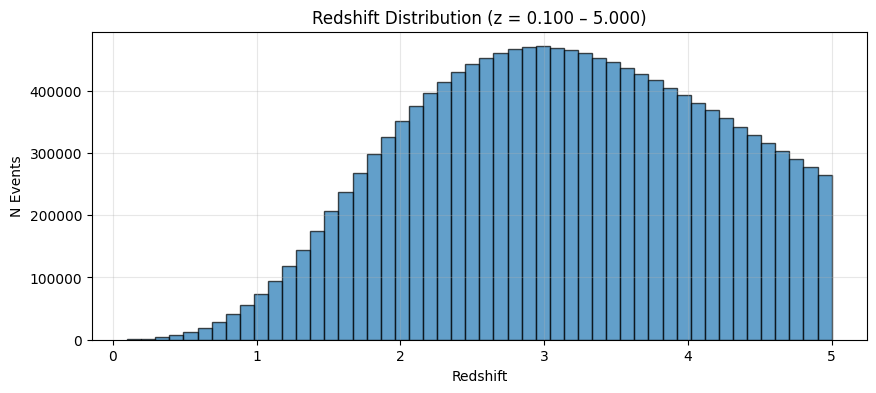

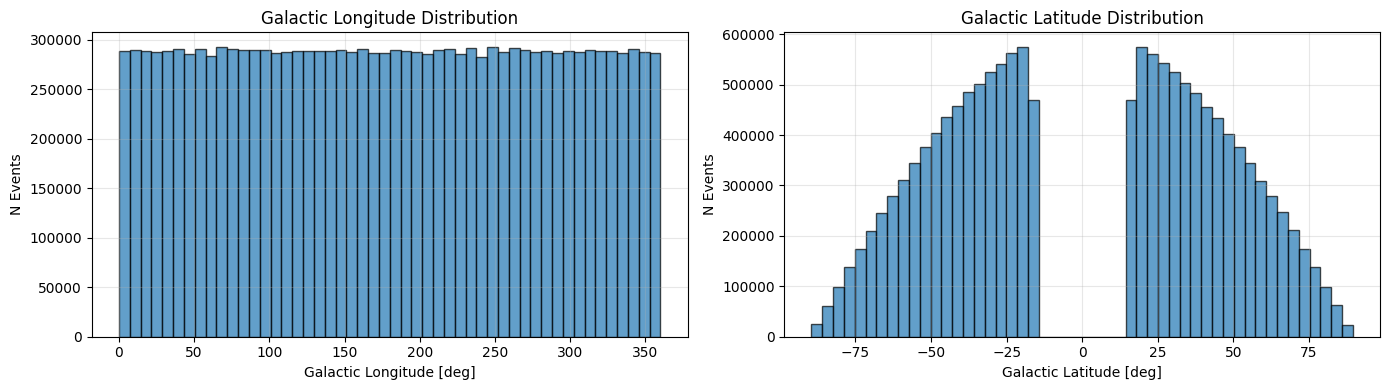

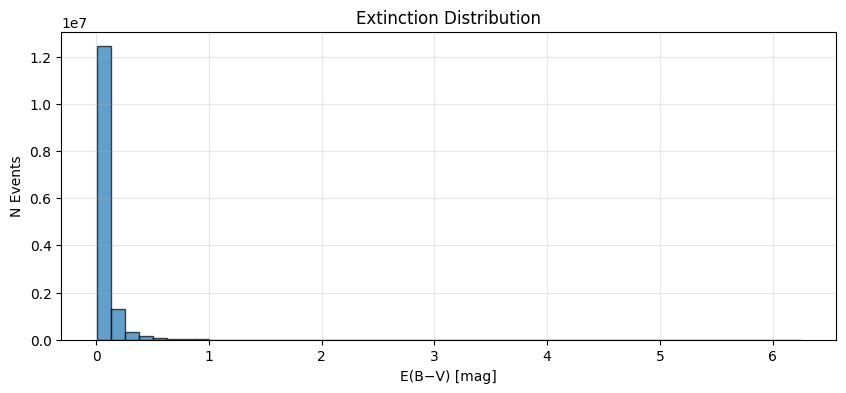

  Diagnostics saved to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/fe_dependent_physical

=== Population diagnostics complete ===


In [5]:
# ============================================================================
# CELL 5: Population diagnostics — all 3 models
# Loads templates and population slicers for diagnostics.
# Also caches pop_slicers dict for Cells C and D.
# ============================================================================
from slsn_metrics.model import LC
from slsn_metrics.population import generate_SLSN_PopSlicer
reload(diag_mod)
from slsn_metrics.diagnostics import plot_population_diagnostics

# Load templates (needed by generate_SLSN_PopSlicer)
print('Loading physical templates...')
templates = LC(load_from=str(SHARED_DIR / 'physical_templates.pkl'))
templates.load_magnitude_grid(str(SHARED_DIR / 'physical_mag_grid.pkl'))
print(f'Templates loaded: {len(templates.sed_grid)} events')

pop_slicers = {}

for model in MODELS:
    print(f'\n=== Population diagnostics: {model} ===')
    pop_pkl   = SHARED_DIR / f'population_{model}.pkl'
    model_dir = get_output_dir('SLSNe', subdir=model)

    pop = generate_SLSN_PopSlicer(
    lc_model=templates,
    load_from=str(pop_pkl),
    z_min=0.1,        
    z_max=5.0,        
    make_debug_plots=False
    )

    pop_slicers[model] = pop
    sp = pop.slice_points

    plot_population_diagnostics(
        ra_rad        = sp['ra'],
        dec_rad       = sp['dec'],
        peak_times    = sp['peak_time'],
        distances_mpc = sp['distance'],
        z_vals        = sp['z'],
        ebv           = sp.get('ebv', None),
        gall          = sp.get('gall', None),
        galb          = sp.get('galb', None),
        outdir        = str(model_dir),
        prefix        = f'population_{model}'
    )
    print(f'  Diagnostics saved to {model_dir}')

print('\n=== Population diagnostics complete ===')


In [6]:
# ============================================================================
# CELL 6: Build combined DataFrame from adaptive results
# Columns: z_lo, z_hi, cadence, metric, n_events, n_success, efficiency,
#          sigma, model, per_year, cadence_short, model_label
# MODEL_LABELS and CADENCE_LABELS come from Cell 1 — do not redefine here.
# ============================================================================

rows = []
for model, df_adap in ADAPTIVE.items():
    df_s = df_adap.copy()
    df_s['model']    = model
    df_s['per_year'] = df_s['n_success'] / SURVEY_YEARS
    rows.append(df_s)

df_all = pd.concat(rows, ignore_index=True)
df_all['cadence_short'] = df_all['cadence'].map(CADENCE_LABELS)
df_all['model_label']   = df_all['model'].map(MODEL_LABELS)

print(f'Loaded {len(df_all)} rows across {df_all["model"].nunique()} models')
print(f'Metrics present: {df_all["metric"].unique().tolist()}')
print(f'Cadences present: {df_all["cadence"].unique().tolist()}')
print(f'Z-bins: {df_all["z_lo"].nunique()} unique bins')
print(f'\nSample rows:')
print(df_all[df_all['metric']=='SLSN_ELAsTiCC_Metric'].head(4).to_string())


Loaded 1460 rows across 3 models
Metrics present: ['SLSN_Detect_Physical_Metric', 'SLSN_Characterize_Physical_Metric', 'SLSN_Villar_Physical_Metric', 'SLSN_ELAsTiCC_Metric', 'SLSN_SpecTrigger_Physical_Metric']
Cadences present: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs']
Z-bins: 49 unique bins

Sample rows:
                  cadence                metric  n_events  n_success  efficiency  z_lo  z_hi     sigma           model  per_year    cadence_short model_label
3   baseline_v5.1.1_10yrs  SLSN_ELAsTiCC_Metric       564        368    0.652482   0.1   0.2  0.020051  naive_physical      36.8  Baseline v5.1.1   Naive SFR
8   baseline_v5.3.0_10yrs  SLSN_ELAsTiCC_Metric       564        362    0.641844   0.1   0.2  0.020189  naive_physical      36.2  Baseline v5.3.0   Naive SFR
13  baseline_v5.1.1_10yrs  SLSN_ELAsTiCC_Metric      1735       1100    0.634006   0.2   0.3  0.011565  naive_physical     110.0  Baseline v5.1.1   Naive SFR
18  baseline_v5.3.0_10yrs  SLSN_ELAsTiCC_Metric     

In [7]:
# ============================================================================
# CELL 7: Summary table — detections/yr and efficiency, all combinations
# Sums n_success across all z-bins per model × cadence × metric.
# METRIC_LABELS, MODEL_LABELS, CADENCE_LABELS come from Cell 1.
# ============================================================================

MODEL_ORDER   = [MODEL_LABELS[m] for m in MODELS]
CADENCE_ORDER = [CADENCE_LABELS[c] for c in CADENCES]

agg = df_all.groupby(['model_label', 'cadence_short', 'metric']).agg(
    n_success=('n_success', 'sum'),
    n_events=('n_events',  'sum'),
).reset_index()
agg['per_year']     = agg['n_success'] / SURVEY_YEARS
agg['efficiency']   = agg['n_success'] / agg['n_events']
agg['metric_short'] = agg['metric'].map(METRIC_LABELS)

for metric_full, metric_short in METRIC_LABELS.items():
    sub = agg[agg['metric'] == metric_full]
    if sub.empty:
        print(f'No data for {metric_short}')
        continue

    pivot = sub.pivot_table(
        index='model_label',
        columns='cadence_short',
        values='per_year',
        aggfunc='first'
    ).reindex(index=MODEL_ORDER, columns=CADENCE_ORDER)

    print(f'\n=== {metric_short} — detections per year ===')
    print(pivot.round(1).to_string())

print('\n=== Detect — overall efficiency [%] (all z-bins combined) ===')
det = agg[agg['metric'] == METRIC_MAP['detect']]
pivot_eff = det.pivot_table(
    index='model_label',
    columns='cadence_short',
    values='efficiency',
    aggfunc='first'
).reindex(index=MODEL_ORDER, columns=CADENCE_ORDER) * 100
print(pivot_eff.round(3).to_string())



=== Detect — detections per year ===
cadence_short  Baseline v5.1.1  Baseline v5.3.0
model_label                                    
Naive SFR              16630.9          16549.9
O-dependent            24471.8          24410.9
Fe-dependent           46303.4          46260.8

=== Characterize — detections per year ===
cadence_short  Baseline v5.1.1  Baseline v5.3.0
model_label                                    
Naive SFR              13516.7          13418.5
O-dependent            19174.4          19087.5
Fe-dependent           35678.2          35636.2

=== Villar — detections per year ===
cadence_short  Baseline v5.1.1  Baseline v5.3.0
model_label                                    
Naive SFR              11367.4          11004.3
O-dependent            15865.8          15356.0
Fe-dependent           29262.6          28331.5

=== ELAsTiCC — detections per year ===
cadence_short  Baseline v5.1.1  Baseline v5.3.0
model_label                                    
Naive SFR              2

In [8]:
# ============================================================================
# CELL 8: Simulated vs observed rates — all 3 models
# Reuses pop_slicers cached by Cell 5. MODEL_LABELS from Cell 1.
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import compare_simulated_vs_observed_rates

rate_tables = {}
for model in MODELS:
    print(f'\n{"="*65}')
    print(f'Model: {MODEL_LABELS[model]}')
    df_rate = compare_simulated_vs_observed_rates(pop_slicers[model])
    rate_tables[model] = df_rate



Model: Naive SFR

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50e-01 1.75e-01      1197     3.25e+09        3.68e-08       3.20e-08       1.15e+00 Quimby+13
2.50e-01 4.00e-01 3.25e-01      4594     9.22e+09        4.99e-08            NaN            NaN         —
4.00e-01 7.00e-01 5.50e-01     30536     4.05e+10        7.53e-08            NaN            NaN         —
7.00e-01 1.00e+00 8.50e-01     77788     6.83e+10        1.14e-07            NaN            NaN         —
1.00e+00 1.50e+00 1.25e+00    261386     1.57e+11        1.66e-07       9.10e-08       1.83e+00  Prajs+17
1.50e+00 2.00e+00 1.75e+00    374221     1.86e+11        2.02e-07            NaN            NaN         —


Model: O-dependent

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50e-01 1.75e-01      129

SED spot check — apparent mags from synthesize_mag_at_z()
 event     z  filt      mag
--------------------------------
     0   0.3     g   26.206
     0   0.3     r   24.980
     0   0.3     i   24.363
     0   0.3     z   24.054
     0   1.5     g   36.849
     0   1.5     r   33.518
     0   1.5     i   31.389
     0   1.5     z   30.135
     0   3.0     g   46.009
     0   3.0     r   42.243
     0   3.0     i   38.890
     0   3.0     z   36.840
     1   0.3     g   23.860
     1   0.3     r   22.653
     1   0.3     i   22.319
     1   0.3     z   22.183
     1   1.5     g   33.648
     1   1.5     r   30.824
     1   1.5     i   29.015
     1   1.5     z   27.904
     1   3.0     g   42.131
     1   3.0     r   38.237
     1   3.0     i   35.477
     1   3.0     z   33.776
     2   0.3     g   21.802
     2   0.3     r   20.933
     2   0.3     i   20.706
     2   0.3     z   20.631
     2   1.5     g   30.347
     2   1.5     r   28.009
     2   1.5     i   26.561
     2   1.5 

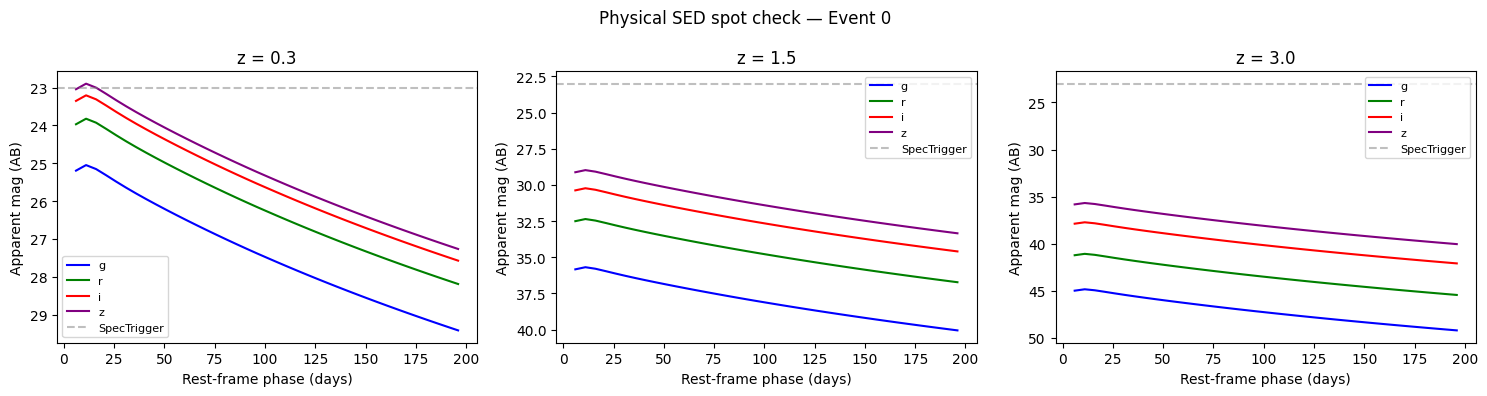

In [9]:
# Cell 10 - SED spot check — physical track only
# Verify synthesize_mag_at_z() produces sensible magnitudes
# at representative redshifts before trusting metric results.
# GP templates do not use this code path.

from slsn_metrics.model import synthesize_mag_at_z

test_redshifts = [0.3, 1.5, 3.0]
test_phase     = 50.0   # mid-range post-peak phase
test_filters   = ['g', 'r', 'i', 'z']
n_events_check = 5

print('SED spot check — apparent mags from synthesize_mag_at_z()')
print(f'{"event":>6} {"z":>5} {"filt":>5} {"mag":>8}')
print('-' * 32)
for ev_idx in range(n_events_check):
    sed_entry = templates.sed_grid[ev_idx]
    for z_test in test_redshifts:
        for filt in test_filters:
            m = synthesize_mag_at_z(sed_entry, test_phase, z_test, filt)
            status = f'{m:.3f}' if np.isfinite(m) else 'NaN'
            print(f'{ev_idx:>6} {z_test:>5.1f} {filt:>5} {status:>8}')

# Light curve plot at three redshifts for event 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
phases_plot = np.arange(1, 200, 5).astype(float)
filt_colors = {'g': 'blue', 'r': 'green', 'i': 'red', 'z': 'purple'}
for ax, z_test in zip(axes, test_redshifts):
    sed_entry = templates.sed_grid[0]
    for filt, col in filt_colors.items():
        mags_plot = np.array([synthesize_mag_at_z(sed_entry, ph, z_test, filt)
                              for ph in phases_plot])
        finite = np.isfinite(mags_plot)
        if finite.sum() > 0:
            ax.plot(phases_plot[finite], mags_plot[finite], color=col, label=filt)
    ax.invert_yaxis()
    ax.set_xlabel('Rest-frame phase (days)')
    ax.set_ylabel('Apparent mag (AB)')
    ax.set_title(f'z = {z_test}')
    ax.axhline(23.0, ls='--', color='gray', alpha=0.5, label='SpecTrigger')
    ax.legend(fontsize=8)
plt.suptitle('Physical SED spot check — Event 0')
plt.tight_layout()
plt.savefig(get_output_dir('SLSNe', subdir='physical_figures') / 'sed_spot_check.png', dpi=150)
plt.show()


In [10]:
# Cell 11 - AUDIT TABLE — summary of figure above
# SED spot check: apparent magnitudes at phase=50d for events 0-4
# Same synthesize_mag_at_z calls as printed above; presented as a pivot table.
import pandas as pd
_rows8 = []
for _ev8 in range(n_events_check):
    _sed8 = templates.sed_grid[_ev8]
    for _z8 in test_redshifts:
        for _f8 in test_filters:
            _m8 = synthesize_mag_at_z(_sed8, test_phase, _z8, _f8)
            _rows8.append({'event': _ev8, 'z': _z8, 'filter': _f8,
                           'mag': round(float(_m8), 3) if np.isfinite(_m8) else float('nan')})
_tbl8 = pd.DataFrame(_rows8)
_tbl8_wide = _tbl8.pivot_table(index=['event', 'z'], columns='filter', values='mag')
print(f"SED spot check — apparent mag at phase={test_phase:.0f}d  (events 0-{n_events_check-1})")
print(_tbl8_wide.to_string())

SED spot check — apparent mag at phase=50d  (events 0-4)
filter          g       i       r       z
event z                                  
0     0.3  26.206  24.363  24.980  24.054
      1.5  36.849  31.389  33.518  30.135
      3.0  46.009  38.890  42.243  36.840
1     0.3  23.860  22.319  22.653  22.183
      1.5  33.648  29.015  30.824  27.904
      3.0  42.131  35.477  38.237  33.776
2     0.3  21.802  20.706  20.933  20.631
      1.5  30.347  26.561  28.009  25.689
      3.0  37.868  32.024  34.330  30.621
3     0.3  21.062  20.429  20.581  20.398
      1.5  29.231  25.499  26.940  24.700
      3.0  36.510  30.890  33.111  29.527
4     0.3  23.591  21.463  21.931  21.363
      1.5  33.544  28.835  30.692  27.677
      3.0  41.975  35.378  38.124  33.671


Saved: efficiency_vs_z_naive_physical.png


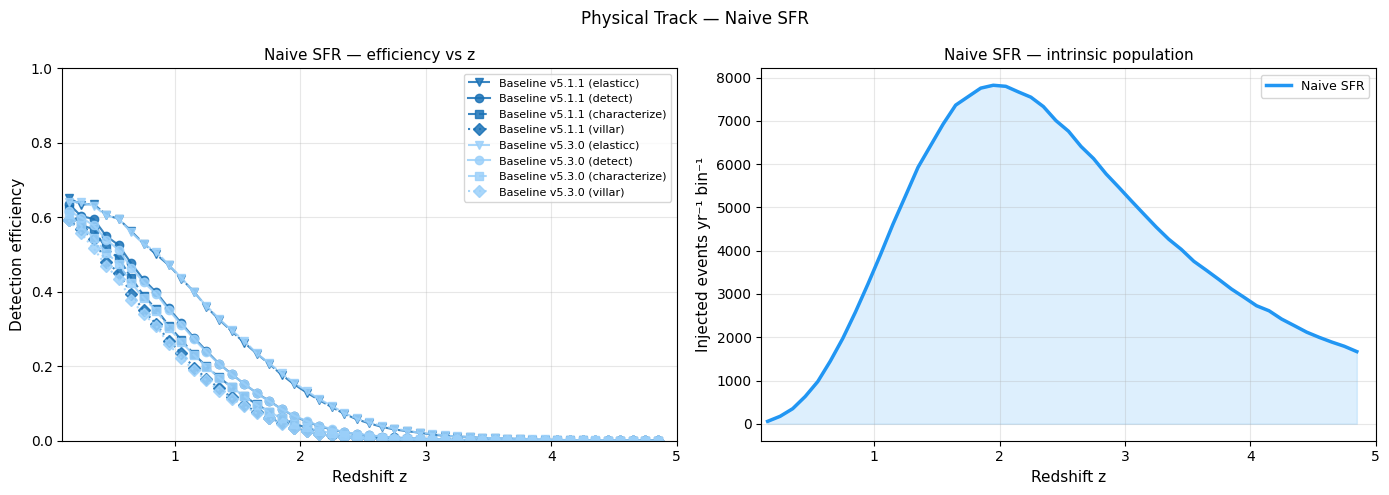

Saved: efficiency_vs_z_o_dependent_physical.png


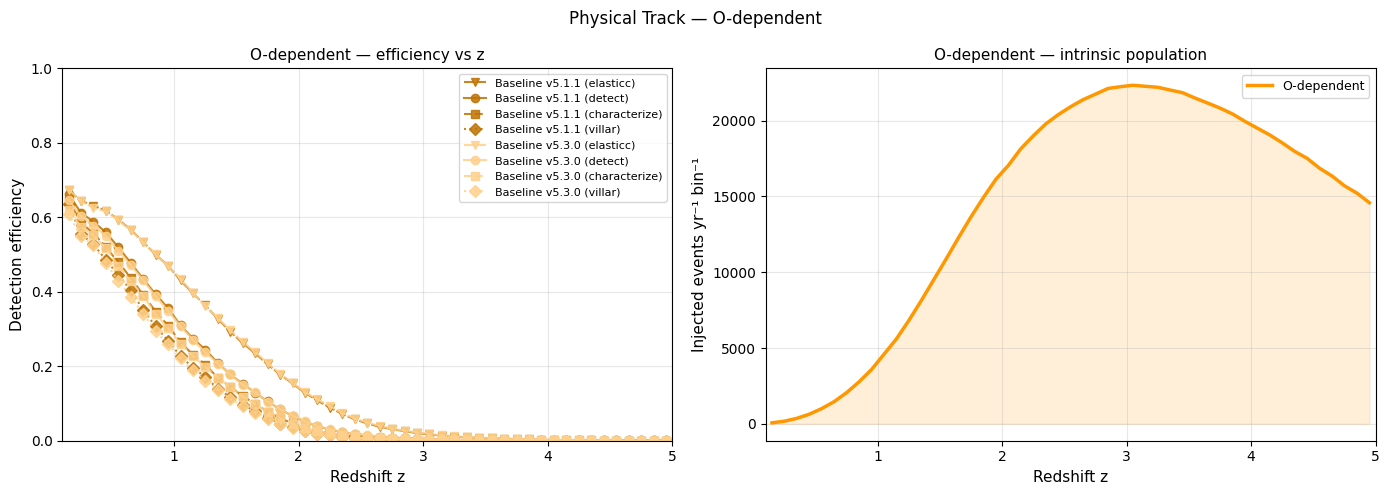

Saved: efficiency_vs_z_fe_dependent_physical.png


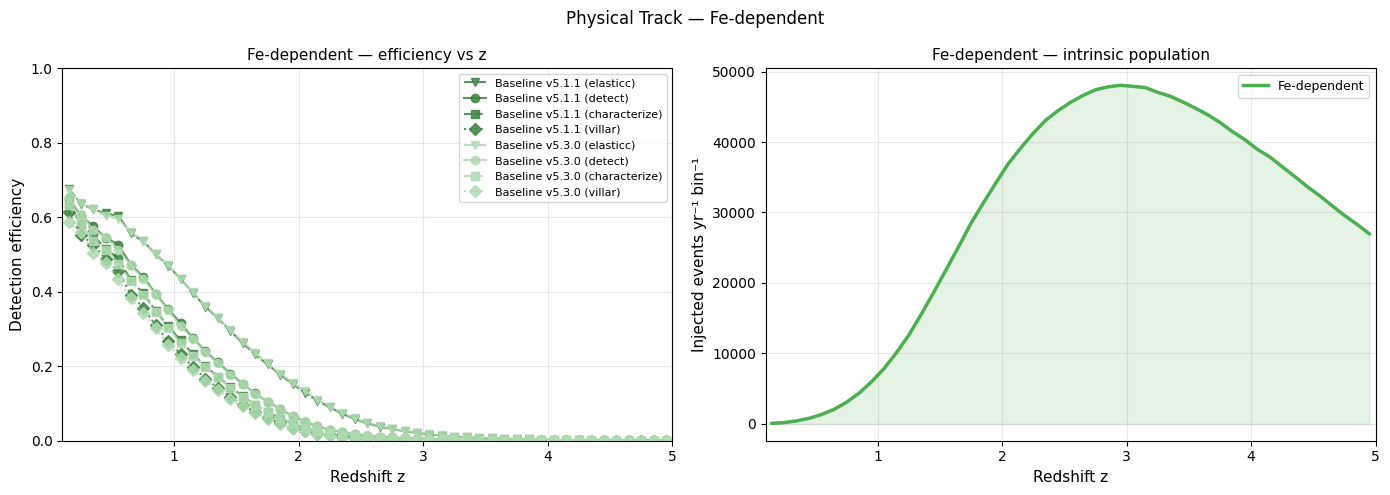

In [11]:
# ============================================================================
# CELL 11: Efficiency vs redshift — per model, all cadences, all metrics
# Left:  Detection efficiency per metric per cadence
# Right: Intrinsic population per model (one line, no metric breakdown)
# MODEL_LABELS, MODEL_COLORS, CADENCE_LABELS, METRIC_MAP come from Cell 1.
#
# Cadence is distinguished by shade (darker = v5.1.1, lighter = v5.3.0),
# derived from MODEL_COLORS so it stays anchored to the canonical model color
# rather than introducing a separate color scheme. Metric is still
# distinguished by line style + marker shape.
# ============================================================================

import matplotlib.colors as mcolors

def shade_color(hex_color, factor):
    """factor < 1 darkens, factor > 1 lightens (toward white)."""
    rgb = mcolors.to_rgb(hex_color)
    if factor < 1:
        return tuple(c * factor for c in rgb)
    else:
        return tuple(c + (1 - c) * (factor - 1) for c in rgb)

# One shade per cadence — darker for the primary/older cadence, lighter for the newer one
CADENCE_SHADE = {
    'baseline_v5.1.1_10yrs': 0.75,   # darker
    'baseline_v5.3.0_10yrs': 1.55,   # lighter
}

ls_metric = {
    'detect':       '-',
    'characterize': '--',
    'villar':       ':',
    'elasticc':     (0, (5, 1)),
}
markers_metric = {
    'detect':       'o',
    'characterize': 's',
    'villar':       'D',
    'elasticc':     'v',
}

PLOT_CADENCES_11 = ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs']
PLOT_METRICS_11  = ['elasticc', 'detect', 'characterize', 'villar']

for model in MODELS:
    if model not in pop_data:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    z_centers = pop_data[model]['z_centers']
    base_color = MODEL_COLORS[model]

    # Left panel — efficiency per metric per cadence
    for cadence in PLOT_CADENCES_11:
        shade = CADENCE_SHADE.get(cadence, 1.0)
        line_color = shade_color(base_color, shade)
        for metric in PLOT_METRICS_11:
            entry = pop_data[model][metric].get(cadence)
            if entry is None:
                continue
            label = f'{CADENCE_LABELS[cadence]} ({metric})'
            axes[0].plot(z_centers, entry['efficiency'],
                         marker=markers_metric[metric],
                         color=line_color,
                         ls=ls_metric[metric], lw=1.5,
                         label=label, alpha=0.85)

    axes[0].set_xlabel('Redshift z', fontsize=11)
    axes[0].set_ylabel('Detection efficiency', fontsize=11)
    axes[0].set_title(f'{MODEL_LABELS[model]} — efficiency vs z', fontsize=11)
    axes[0].legend(fontsize=8, loc='upper right')
    axes[0].grid(alpha=0.3)
    axes[0].set_xlim(0.1, 5.0)
    axes[0].set_ylim(0, 1.0)

    # Right panel — intrinsic population only (use elasticc n_events)
    ref_cadence = PLOT_CADENCES_11[0]
    entry = pop_data[model]['elasticc'].get(ref_cadence)
    if entry is not None:
        n_ev_bins  = entry['n_events']
        count_bins = [n / SURVEY_YEARS for n in n_ev_bins]
        axes[1].plot(z_centers, count_bins,
                     color=base_color, lw=2.5,
                     label=MODEL_LABELS[model])
        axes[1].fill_between(z_centers, 0, count_bins,
                             color=base_color, alpha=0.15)

    axes[1].set_xlabel('Redshift z', fontsize=11)
    axes[1].set_ylabel('Injected events yr⁻¹ bin⁻¹', fontsize=11)
    axes[1].set_title(f'{MODEL_LABELS[model]} — intrinsic population', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)
    axes[1].set_xlim(0.1, 5.0)

    plt.suptitle(f'Physical Track — {MODEL_LABELS[model]}', fontsize=12)
    plt.tight_layout()
    out_fig = get_output_dir('SLSNe') / f'efficiency_vs_z_{model}.png'
    plt.savefig(str(out_fig), dpi=150, bbox_inches='tight')
    print(f'Saved: {out_fig.name}')
    plt.show()

In [12]:
# Cell 13 - AUDIT TABLE — summary of figure above
# Detect efficiency per z-bin — baseline_v5.1.1, detect metric (representative slice)
# Full pop_data available for all 4 cadences × 4 metrics × 3 models.
import pandas as pd
_rows9, _ref9 = [], 'baseline_v5.1.1_10yrs'
for _mdl9 in MODELS:
    if _mdl9 not in pop_data:
        continue
    _ent9 = pop_data[_mdl9]['detect'].get(_ref9)
    if _ent9 is None:
        continue
    for _z9, _e9, _n9 in zip(pop_data[_mdl9]['z_centers'],
                              _ent9['efficiency'], _ent9['n_events']):
        _rows9.append({'model': _mdl9.replace('_physical',''), 'z_center': round(_z9, 2),
                       'n_events': int(_n9), 'efficiency': round(_e9, 4)})
_tbl9 = pd.DataFrame(_rows9)
print(f"Detect efficiency vs z — cadence={_ref9}")
print(_tbl9[_tbl9['efficiency'] > 0].to_string(index=False))

Detect efficiency vs z — cadence=baseline_v5.1.1_10yrs
       model  z_center  n_events  efficiency
       naive      0.15       564      0.6365
       naive      0.25      1735      0.6035
       naive      0.35      3492      0.5954
       naive      0.45      6309      0.5498
       naive      0.55      9755      0.5252
       naive      0.65     14472      0.4762
       naive      0.75     19744      0.4322
       naive      0.85     25776      0.3984
       naive      0.95     32268      0.3556
       naive      1.05     39058      0.3156
       naive      1.15     46121      0.2766
       naive      1.25     52667      0.2413
       naive      1.35     59270      0.2070
       naive      1.45     64270      0.1792
       naive      1.55     69241      0.1528
       naive      1.65     73624      0.1283
       naive      1.75     75591      0.1069
       naive      1.85     77551      0.0848
       naive      1.95     78214      0.0660
       naive      2.05     77970      0.0514


Saved: n_success_per_year_detect_baseline_v5.3.0_10yrs.png


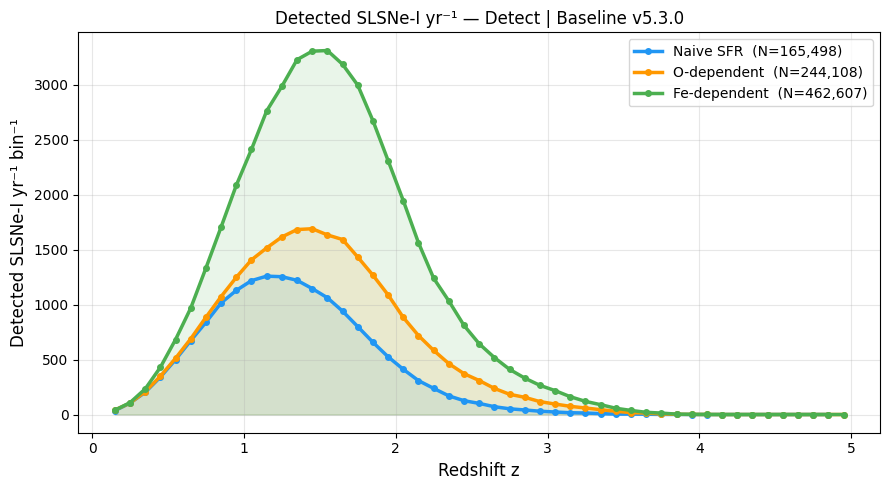

In [13]:
# ============================================================================
# CELL 13: Detected SLSNe-I per year per z-bin — all 3 models, one metric
# MODEL_LABELS, MODEL_COLORS, CADENCE_LABELS come from Cell 1.
# ============================================================================
# Toggles — change these to switch metric or cadence:
PLOT_METRIC  = 'detect'
PLOT_CADENCE = 'baseline_v5.3.0_10yrs'

metric_label_13 = METRIC_LABELS[METRIC_MAP[PLOT_METRIC]]

fig, ax = plt.subplots(figsize=(9, 5))

for model in MODELS:
    if model not in pop_data:
        continue
    entry = pop_data[model][PLOT_METRIC].get(PLOT_CADENCE)
    if entry is None:
        print(f'[skip] {model} / {PLOT_CADENCE} not in pop_data')
        continue

    z_centers  = pop_data[model]['z_centers']
    efficiency = np.array(entry['efficiency'])
    n_events   = np.array(entry['n_events'])
    n_success  = efficiency * n_events
    n_per_year = n_success / SURVEY_YEARS

    total = n_success.sum()
    label = f'{MODEL_LABELS[model]}  (N={int(total):,})'

    ax.plot(z_centers, n_per_year,
            color=MODEL_COLORS[model],
            lw=2.5, marker='o', ms=4,
            label=label)
    ax.fill_between(z_centers, 0, n_per_year,
                    color=MODEL_COLORS[model], alpha=0.12)

ax.set_xlabel('Redshift z', fontsize=12)
ax.set_ylabel('Detected SLSNe-I yr⁻¹ bin⁻¹', fontsize=12)
ax.set_title(
    f'Detected SLSNe-I yr⁻¹ — {metric_label_13} | '
    f'{CADENCE_LABELS[PLOT_CADENCE]}',
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()

out_fig = get_output_dir('SLSNe') / f'n_success_per_year_{PLOT_METRIC}_{PLOT_CADENCE}.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()


In [14]:
# Cell 15 - AUDIT TABLE — summary of figure above
# Detected SLSNe-I yr⁻¹ per z-bin — all 3 models at PLOT_METRIC/PLOT_CADENCE
# Matches the plotted curves; zero-efficiency bins omitted.
import pandas as pd
_rows10 = []
for _mdl10 in MODELS:
    if _mdl10 not in pop_data:
        continue
    _ent10 = pop_data[_mdl10][PLOT_METRIC].get(PLOT_CADENCE)
    if _ent10 is None:
        continue
    _zc10 = pop_data[_mdl10]['z_centers']
    _ef10 = np.array(_ent10['efficiency'])
    _ne10 = np.array(_ent10['n_events'])
    _ny10 = _ef10 * _ne10 / SURVEY_YEARS
    for _z, _e, _n, _p in zip(_zc10, _ef10, _ne10.astype(int), _ny10):
        _rows10.append({'model': _mdl10.replace('_physical',''), 'z_center': round(_z, 2),
                        'n_events': _n, 'efficiency': round(_e, 4), 'n_per_yr': round(_p, 2)})
_tbl10 = pd.DataFrame(_rows10)
print(f"Detected SLSNe-I yr⁻¹ per z-bin — metric={PLOT_METRIC} | cadence={CADENCE_LABELS.get(PLOT_CADENCE, PLOT_CADENCE)}")
print(_tbl10[_tbl10['n_per_yr'] > 0].to_string(index=False))

Detected SLSNe-I yr⁻¹ per z-bin — metric=detect | cadence=Baseline v5.3.0
       model  z_center  n_events  efficiency  n_per_yr
       naive      0.15       564      0.6170      34.8
       naive      0.25      1735      0.5994     104.0
       naive      0.35      3492      0.5785     202.0
       naive      0.45      6309      0.5403     340.9
       naive      0.55      9755      0.5123     499.7
       naive      0.65     14472      0.4648     672.6
       naive      0.75     19744      0.4252     839.5
       naive      0.85     25776      0.3942    1016.0
       naive      0.95     32268      0.3501    1129.7
       naive      1.05     39058      0.3120    1218.8
       naive      1.15     46121      0.2731    1259.5
       naive      1.25     52667      0.2382    1254.4
       naive      1.35     59270      0.2061    1221.8
       naive      1.45     64270      0.1784    1146.4
       naive      1.55     69241      0.1535    1062.9
       naive      1.65     73624      0.1278  


naive_physical: 395,117 events at z=3.0-4.0

--- naive_physical x baseline_v5.1.1_10yrs ---
  detect: 627 detected pixels / 36416 injected pixels (1.7%)
  characterize: 279 detected pixels / 36416 injected pixels (0.8%)
  villar: 170 detected pixels / 36416 injected pixels (0.5%)


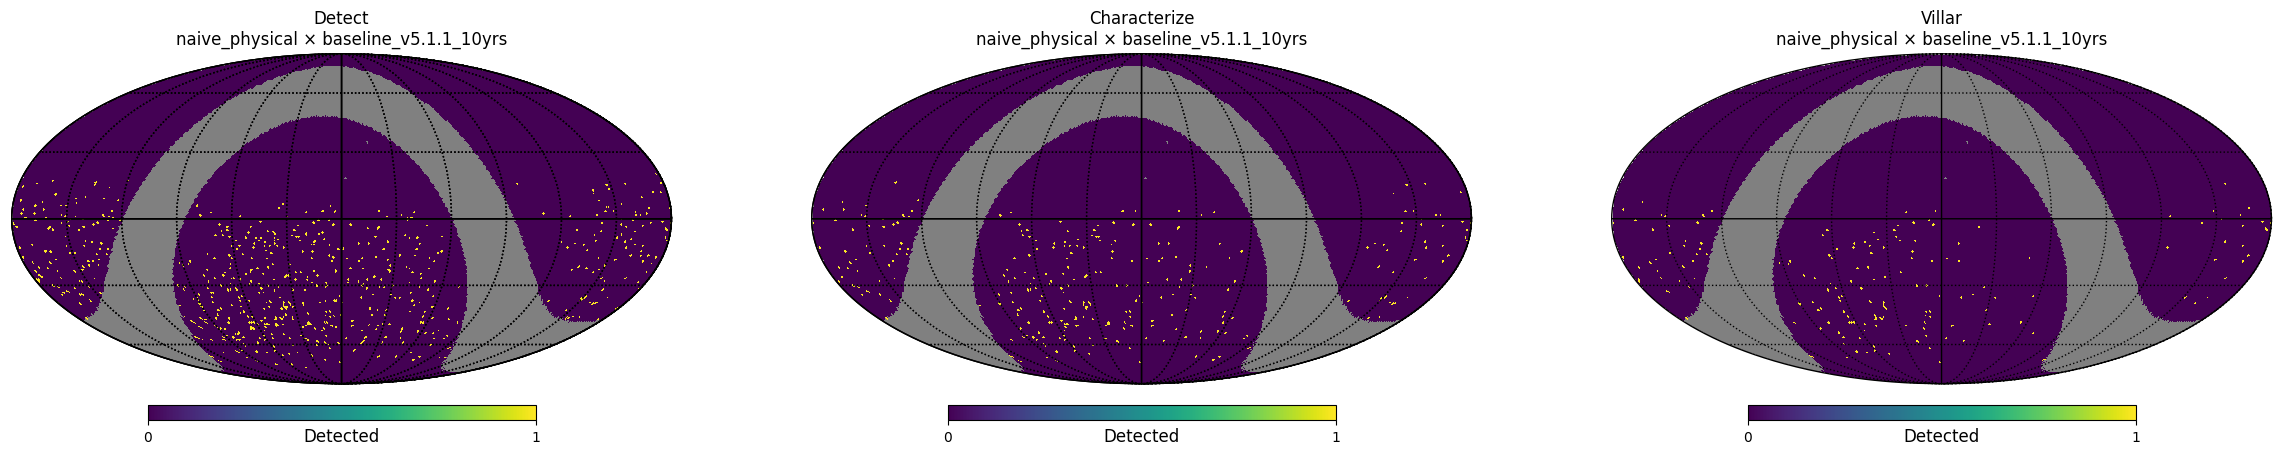

  Saved row: healpix_row_naive_physical_baseline_v5.1.1_10yrs_physical.png

--- naive_physical x baseline_v5.3.0_10yrs ---
  detect: 720 detected pixels / 36416 injected pixels (2.0%)
  characterize: 367 detected pixels / 36416 injected pixels (1.0%)
  villar: 239 detected pixels / 36416 injected pixels (0.7%)


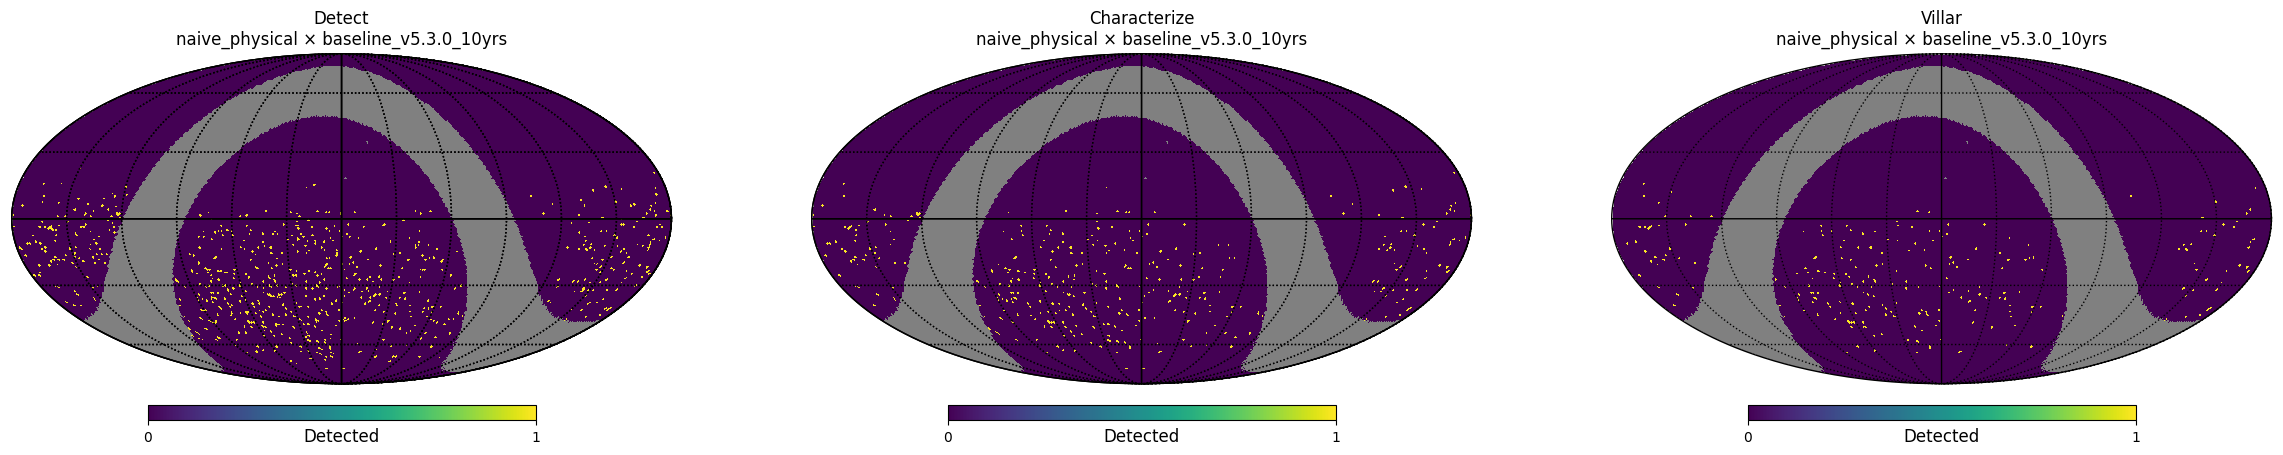

  Saved row: healpix_row_naive_physical_baseline_v5.3.0_10yrs_physical.png

o_dependent_physical: 2,145,478 events at z=3.0-4.0

--- o_dependent_physical x baseline_v5.1.1_10yrs ---
  detect: 2910 detected pixels / 36418 injected pixels (8.0%)
  characterize: 1291 detected pixels / 36418 injected pixels (3.5%)
  villar: 846 detected pixels / 36418 injected pixels (2.3%)


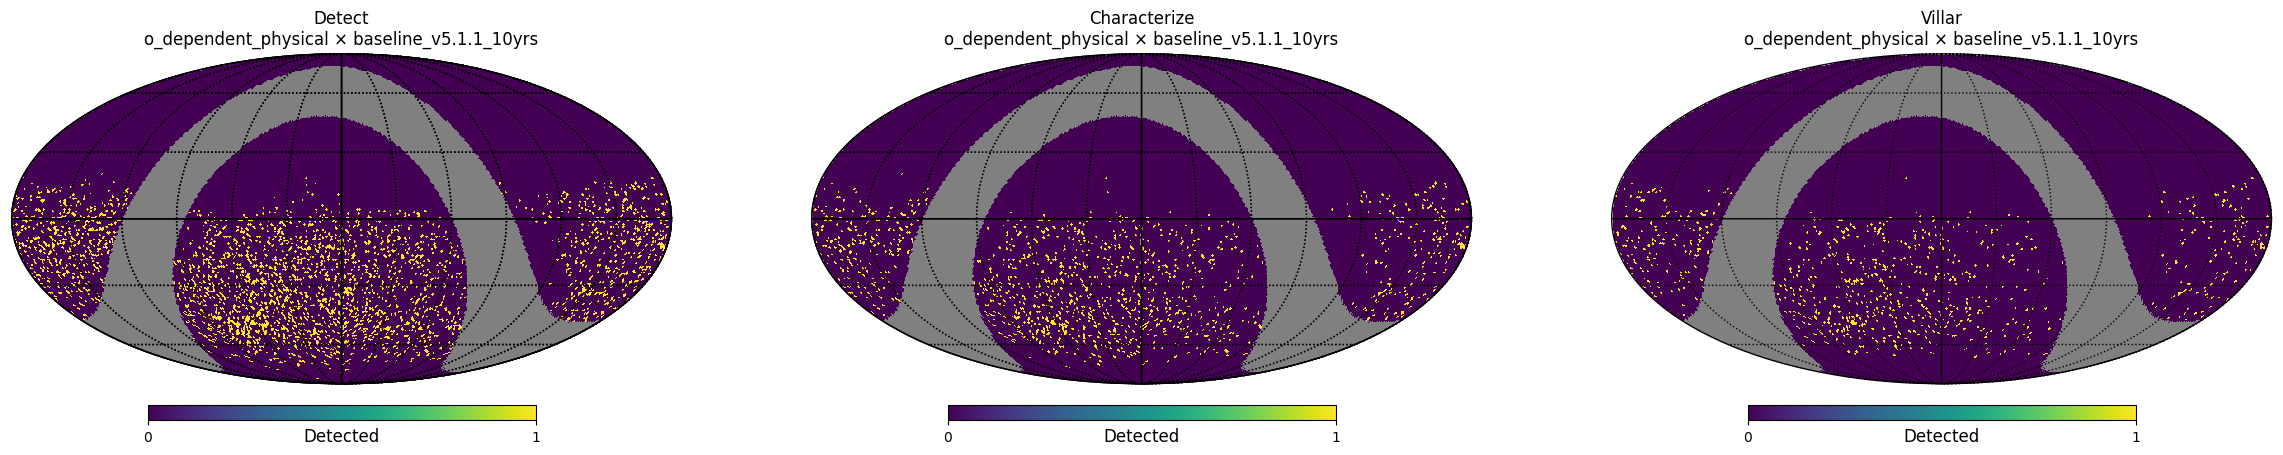

  Saved row: healpix_row_o_dependent_physical_baseline_v5.1.1_10yrs_physical.png

--- o_dependent_physical x baseline_v5.3.0_10yrs ---
  detect: 3104 detected pixels / 36418 injected pixels (8.5%)
  characterize: 1462 detected pixels / 36418 injected pixels (4.0%)
  villar: 942 detected pixels / 36418 injected pixels (2.6%)


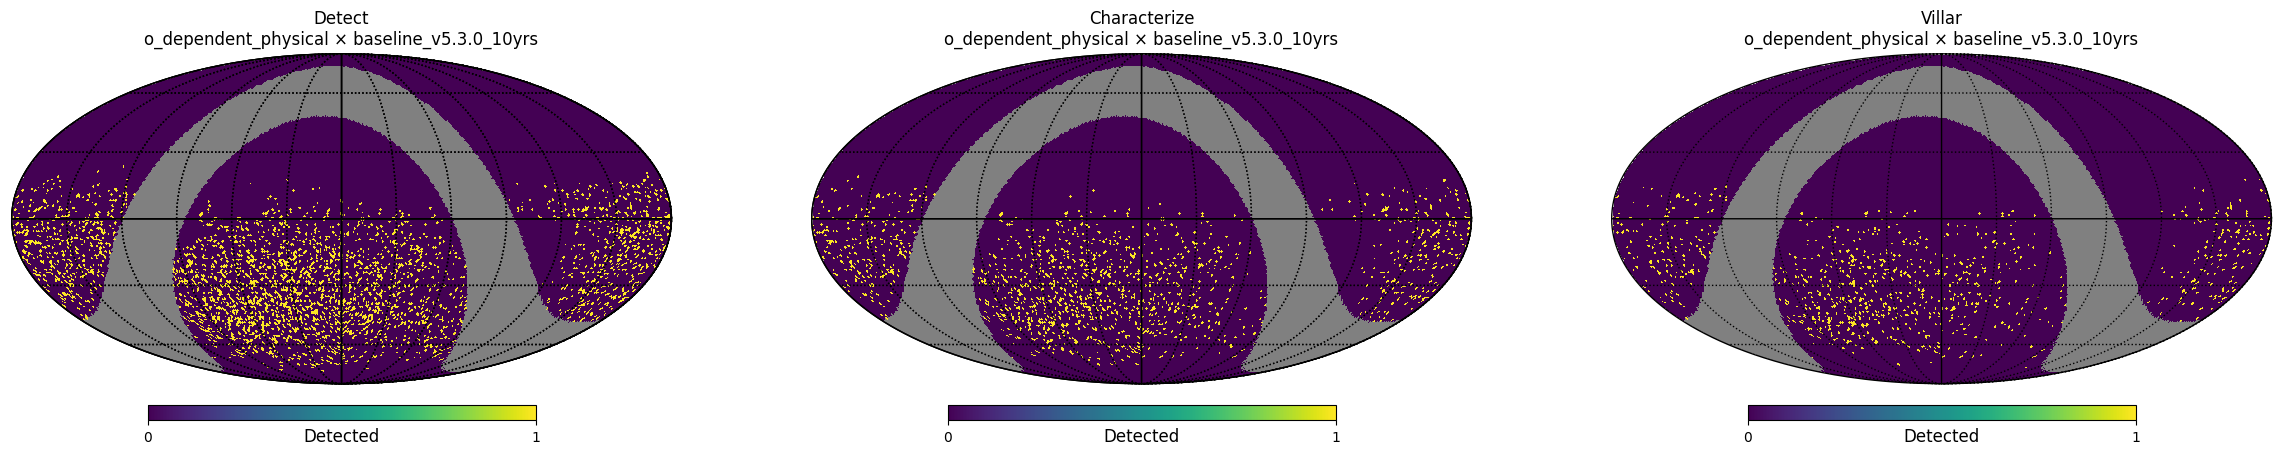

  Saved row: healpix_row_o_dependent_physical_baseline_v5.3.0_10yrs_physical.png

fe_dependent_physical: 4,481,881 events at z=3.0-4.0

--- fe_dependent_physical x baseline_v5.1.1_10yrs ---
  detect: 5514 detected pixels / 36418 injected pixels (15.1%)
  characterize: 2642 detected pixels / 36418 injected pixels (7.3%)
  villar: 1783 detected pixels / 36418 injected pixels (4.9%)


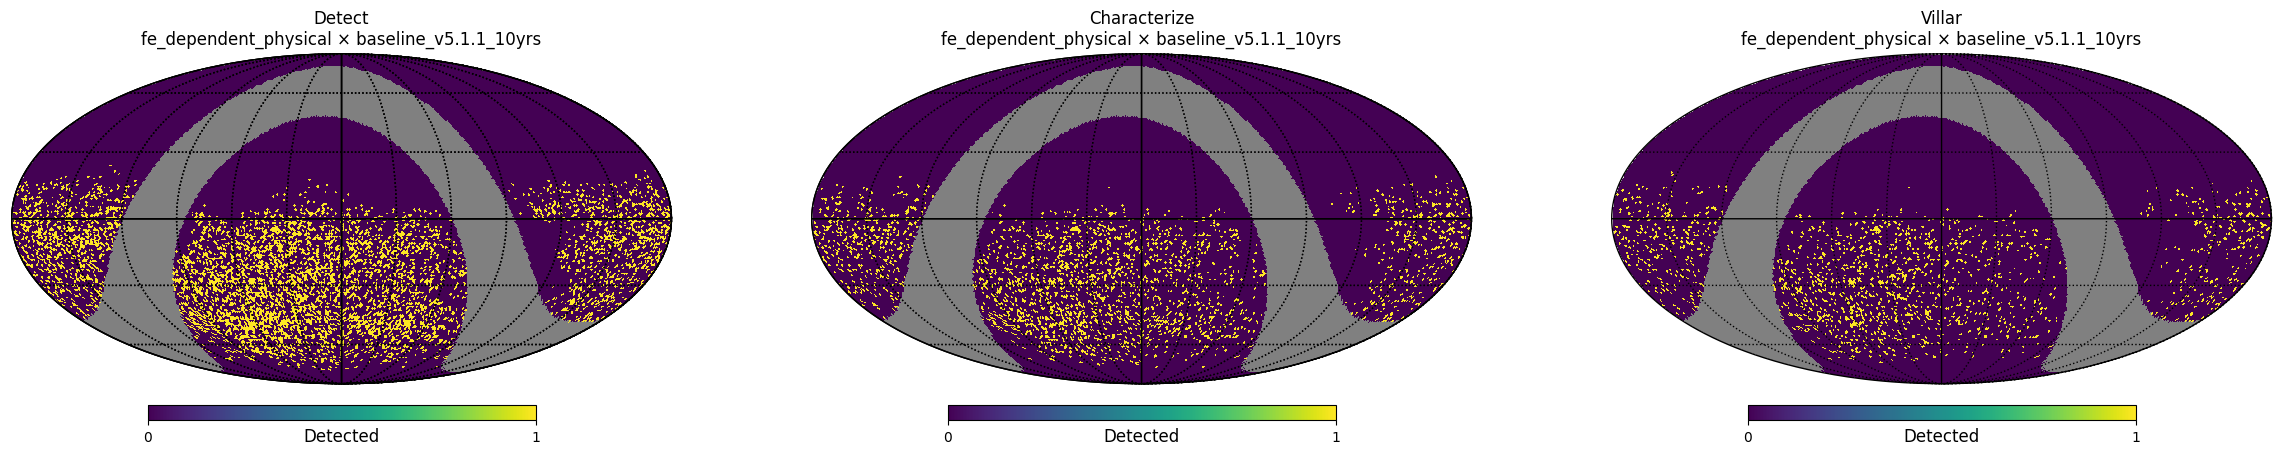

  Saved row: healpix_row_fe_dependent_physical_baseline_v5.1.1_10yrs_physical.png

--- fe_dependent_physical x baseline_v5.3.0_10yrs ---
  detect: 5816 detected pixels / 36418 injected pixels (16.0%)
  characterize: 2972 detected pixels / 36418 injected pixels (8.2%)
  villar: 1901 detected pixels / 36418 injected pixels (5.2%)


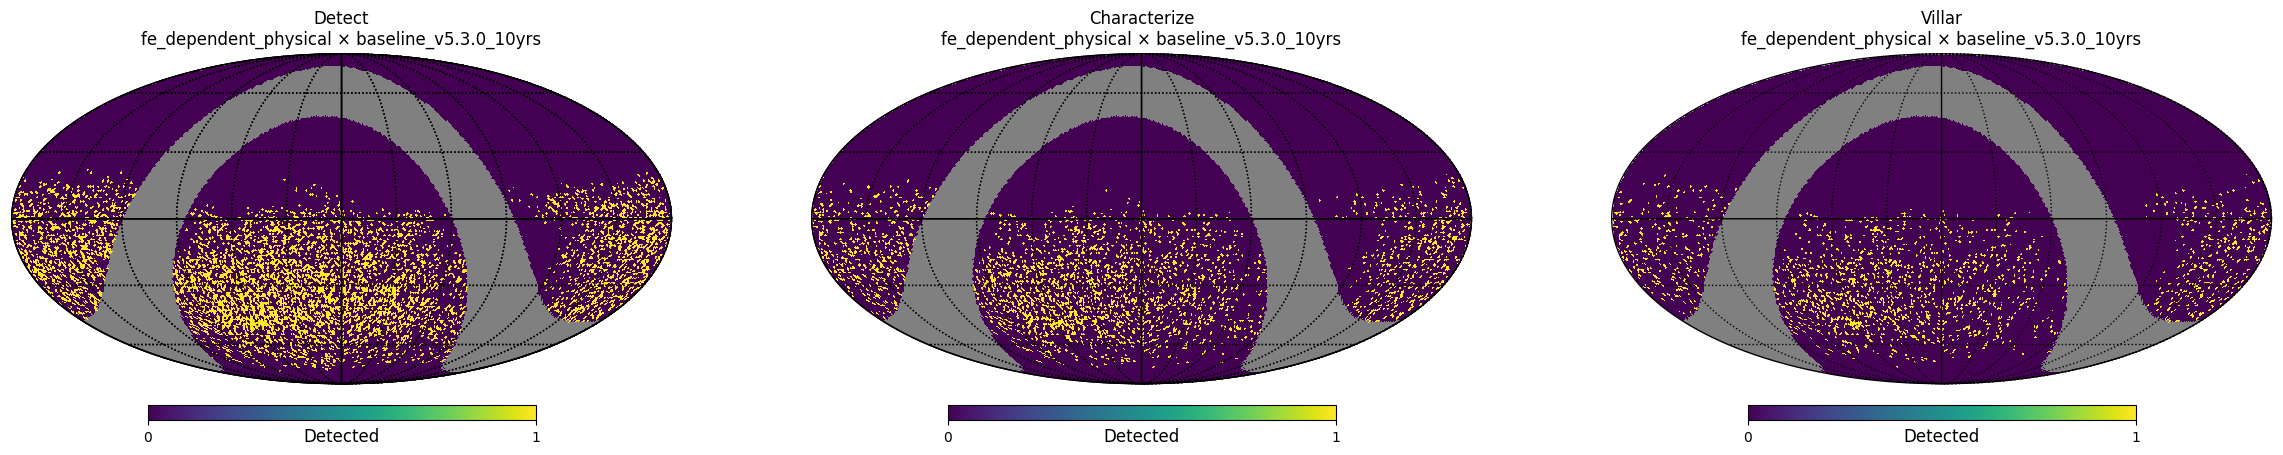

  Saved row: healpix_row_fe_dependent_physical_baseline_v5.3.0_10yrs_physical.png


In [15]:
# ============================================================================
# CELL 16: HEALPix sky maps — all 3 models × all 4 cadences
# Shows detection efficiency per pixel within Rubin observed footprint.
# Grey   = outside injected population (galactic plane + truly empty pixels)
# Purple = injected AND in-footprint (evaluated by MAF), not detected
# Yellow = detected (MAF enforces Rubin footprint)
#
# NOTE: -1 sentinel (out-of-footprint) events are excluded from both
# the purple background and detection count. This makes the Rubin
# footprint boundary visible naturally without an explicit mask.
# ============================================================================
reload(diag_mod)
import healpy as hp

METRIC_KEYS     = ['detect', 'characterize', 'villar']
HEALPIX_FIGSIZE = (24, 4)
NSIDE           = 64
# Toggle — only show cadences with clean badval-fixed npy files
PLOT_CADENCES_9 = ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs']
# Z-range for HEALPix map — restrict to a redshift slice to show cadence structure
# At z=3.0-4.0 efficiency drops to ~1-2%, making cadence patterns visible
HEALPIX_Z_RANGE = (3.0, 4.0)  # (z_lo, z_hi) — set to (0.1, 5.0) for full range

for model in MODELS:
    sp    = pop_slicers[model].slice_points
    z_all = np.asarray(sp['z'])

    # Find the most recent z0.1-5.0 npy and verify it matches the full population
    test_npy = find_latest_npy(model, CADENCES[0], 'elasticc')
    if test_npy is None:
        print(f'{model}: no z0.1-5.0 npy found — skipping')
        continue
    test_arr = np.load(str(test_npy))
    if len(test_arr) != (z_all >= 0.1).sum():  # npy always covers z=0.1-5.0 full range
        print(f'{model}: size mismatch — skipping')
        continue

    mask_z  = (z_all >= HEALPIX_Z_RANGE[0]) & (z_all <= HEALPIX_Z_RANGE[1])
    ra_map  = np.asarray(sp['ra'])[mask_z]
    dec_map = np.asarray(sp['dec'])[mask_z]
    print(f'\n{model}: {mask_z.sum():,} events at z={HEALPIX_Z_RANGE[0]}-{HEALPIX_Z_RANGE[1]}')

    # Precompute pixel indices once per model
    npix  = hp.nside2npix(NSIDE)
    theta = 0.5 * np.pi - dec_map
    pix   = hp.ang2pix(NSIDE, theta, ra_map)

    for cadence in PLOT_CADENCES_9:
        print(f'\n--- {model} x {cadence} ---')

        fig = plt.figure(figsize=HEALPIX_FIGSIZE)

        for col_idx, metric in enumerate(METRIC_KEYS):
            npy_path = find_latest_npy(model, cadence, metric)
            if npy_path is None:
                print(f'  Skipping {metric} — no z0.1-5.0 npy found')
                continue

            metric_map   = np.load(str(npy_path))              # full z=0.1-5.0 array
            if len(metric_map) != (z_all >= 0.1).sum():
                print(f'  Size mismatch: npy={len(metric_map)}, '
                      f'pop={(z_all >= 0.1).sum()} — skipping {metric}')
                continue
            metric_slice = metric_map[mask_z]                  # subset matching z-range

           # Build three-layer map:
            # UNSEEN  = no injected events (grey — galactic plane, empty sky)
            # 0.0     = injected but not detected (deep purple)
            # 1.0     = at least one detection (yellow)
            injected_map = np.zeros(npix)   # all injected events
            detected_map = np.zeros(npix)   # detected events

            for i, p in enumerate(pix):
                injected_map[p] += 1
                if metric_slice[i] == 1:
                    detected_map[p] += 1

            eff_map = np.full(npix, hp.UNSEEN)
            eff_map[injected_map > 0] = 0.0   # purple — injected, not detected
            eff_map[detected_map > 0] = 1.0   # yellow — detected

            n_det_pix  = int((detected_map > 0).sum())
            n_inj_pix  = int((injected_map > 0).sum())
            print(f'  {metric}: {n_det_pix} detected pixels / '
                  f'{n_inj_pix} injected pixels '
                  f'({100*n_det_pix/max(n_inj_pix,1):.1f}%)')

            hp.mollview(
                eff_map,
                title  = f'{metric.capitalize()}\n{model} × {cadence}',
                unit   = 'Detected',
                cmap   = 'viridis',
                min    = 0,
                max    = 1,
                hold   = False,
                sub    = (1, len(METRIC_KEYS), col_idx + 1),
                fig    = fig.number
            )
            hp.graticule()

        out_row = get_output_dir('SLSNe', subdir=model) / \
                  f'healpix_row_{model}_{cadence}_physical.png'
        plt.savefig(str(out_row), dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f'  Saved row: {out_row.name}')

In [16]:
# Cell 17 - AUDIT TABLE — summary of figure above
# HEALPix detection summary — baseline_v5.1.1 × detect/characterize/villar
# n_in_footprint excludes -1 (out-of-footprint) events; eff = n_det / n_fp
import pandas as pd
_rows11 = []
for _mdl11 in MODELS:
    _sp11 = pop_slicers[_mdl11].slice_points
    _z11  = np.asarray(_sp11['z'])
    _t11  = find_latest_npy(_mdl11, CADENCES[0], 'elasticc')
    if _t11 is None or len(np.load(str(_t11))) != ((_z11 >= 0.1) & (_z11 <= 5.0)).sum():
        continue
    for _met11 in ['detect', 'characterize', 'villar']:
        _npy11 = find_latest_npy(_mdl11, 'baseline_v5.1.1_10yrs', _met11)
        if _npy11 is None:
            continue
        _mv11 = np.load(str(_npy11))
        _fp11 = (_mv11 >= 0).sum()
        _d11  = (_mv11 == 1).sum()
        _rows11.append({'model': _mdl11.replace('_physical',''), 'metric': _met11,
                        'z_max': 5.0, 'n_in_fp': int(_fp11), 'n_detected': int(_d11),
                        'eff_%': round(100 * _d11 / _fp11, 2) if _fp11 > 0 else 0.0})
print("HEALPix detect summary — baseline_v5.1.1  (badval=-1 excluded from denominator)")
print(pd.DataFrame(_rows11).to_string(index=False))

HEALPix detect summary — baseline_v5.1.1  (badval=-1 excluded from denominator)
       model       metric  z_max  n_in_fp  n_detected  eff_%
       naive       detect    5.0  1403725      166309  11.85
       naive characterize    5.0  1403725      135167   9.63
       naive       villar    5.0  1403725      113674   8.10
 o_dependent       detect    5.0  4849474      244718   5.05
 o_dependent characterize    5.0  4849474      191744   3.95
 o_dependent       villar    5.0  4849474      158658   3.27
fe_dependent       detect    5.0  9949104      463034   4.65
fe_dependent characterize    5.0  9949104      356782   3.59
fe_dependent       villar    5.0  9949104      292626   2.94


  Size mismatch naive_physical baseline_v5.3.0_10yrs: npy=1,000,000 vs peak_times=2,034,661
Naive SFR: 2,034,661 events loaded
  Size mismatch o_dependent_physical baseline_v5.3.0_10yrs: npy=1,000,000 vs peak_times=7,033,255
O-dependent: 7,033,255 events loaded
  Size mismatch fe_dependent_physical baseline_v5.3.0_10yrs: npy=1,000,000 vs peak_times=14,432,797
Fe-dependent: 14,432,797 events loaded

=== MC Rate Uncertainty — Baseline v5.1.1 ===


/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/slsn_metrics/diagnostics.py:2658: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: mc_panel_3panel_characterize_baseline_v5.1.1_10yrs.png


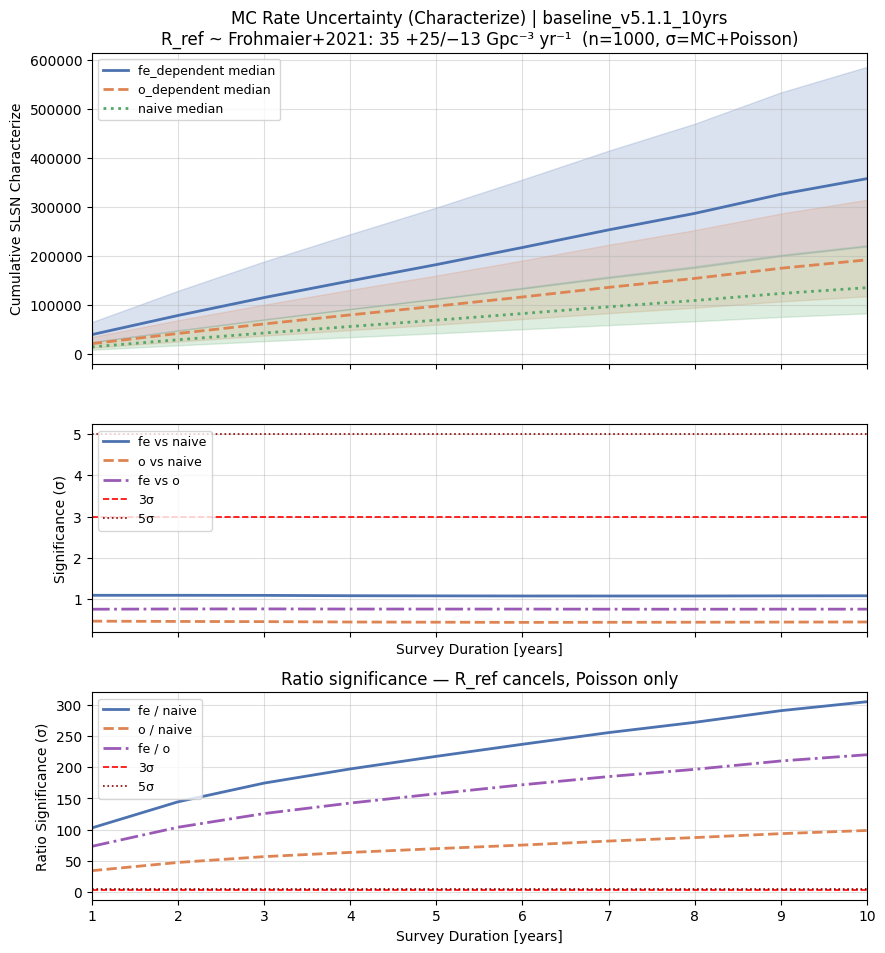


=== MC Rate Uncertainty — Baseline v5.3.0 ===


/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/slsn_metrics/diagnostics.py:2597: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_n.legend(loc='upper left', fontsize=9)


  Saved: mc_panel_3panel_characterize_baseline_v5.3.0_10yrs.png


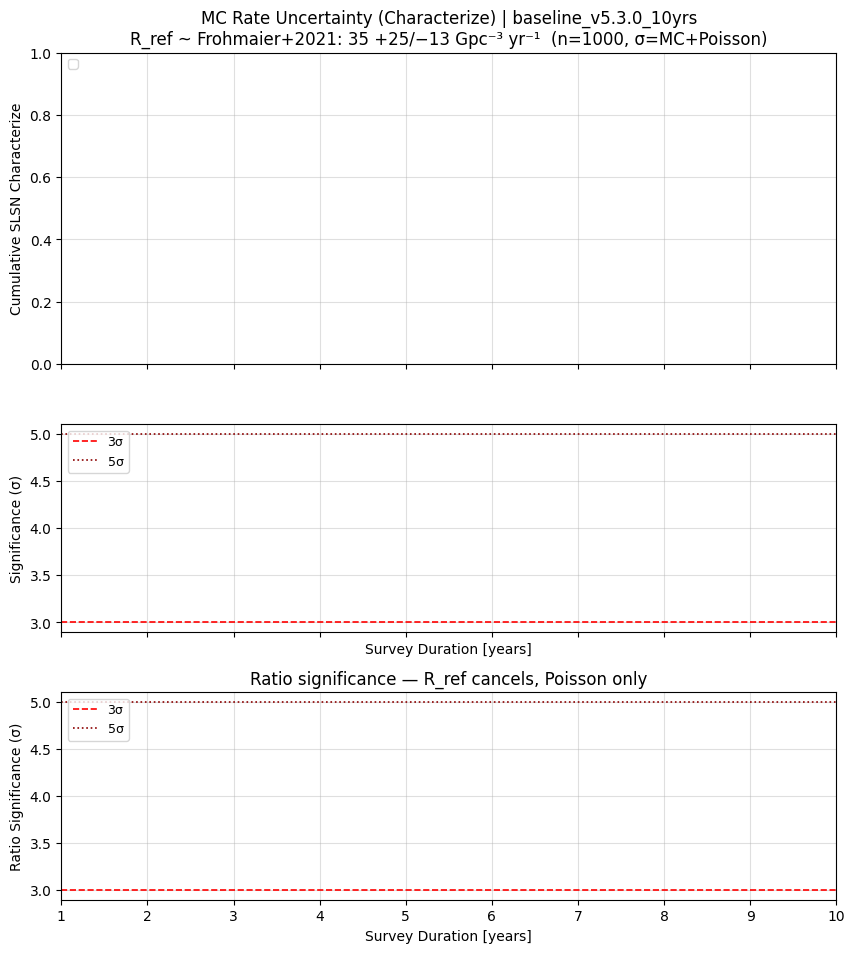

In [10]:
# ============================================================================
# CELL 18: Monte Carlo rate uncertainty — all cadences, all models
# Samples R_ref from Frohmaier+2021 asymmetric distribution to propagate
# rate uncertainty into cumulative detection counts over survey lifetime.
# find_latest_npy comes from Cell 1. MODEL_LABELS, METRIC_LABELS from Cell 1.
#
# Badval (-1) sentinel handling confirmed correct in diagnostics.py —
# see audit table below for verification.
# ============================================================================
import slsn_metrics.diagnostics as diag_mod
from importlib import reload
reload(diag_mod)
from slsn_metrics.diagnostics import plot_mc_rate_uncertainty_panel

METRIC_KEY   = 'characterize'
METRIC_LABEL = METRIC_LABELS[METRIC_MAP[METRIC_KEY]]

pop_data_mc = {}
for model in MODELS:
    short = model.replace('_physical', '')   # 'naive_physical' -> 'naive'
    sp    = pop_slicers[model].slice_points
    z_all = np.asarray(sp['z'])

    test_npy = find_latest_npy(model, CADENCES[0], 'elasticc')
    if test_npy is None:
        print(f'{model}: no z0.1-5.0 npy found — skipping')
        continue
    test_arr = np.load(str(test_npy))
    mask_z   = (z_all >= 0.1) & (z_all <= 5.0)
    if len(test_arr) != mask_z.sum():
        print(f'{model}: size mismatch (npy={len(test_arr):,}, '
              f'pop={mask_z.sum():,}) — skipping')
        continue

    peak_times = np.asarray(sp['peak_time'])[mask_z]
    z_vals     = z_all[mask_z]

    metric_arrays = {}
    for cadence in CADENCES:
        npy_path = find_latest_npy(model, cadence, METRIC_KEY)
        if npy_path is not None:
            arr = np.load(str(npy_path)).astype(int)
            if len(arr) == len(peak_times):
                metric_arrays[cadence] = arr
            else:
                print(f'  Size mismatch {model} {cadence}: '
                      f'npy={len(arr):,} vs peak_times={len(peak_times):,}')
                metric_arrays[cadence] = None
        else:
            print(f'  Missing: no z0.1-5.0 npy for {model} {cadence} {METRIC_KEY}')
            metric_arrays[cadence] = None

    pop_data_mc[short] = {
        METRIC_KEY:  metric_arrays,
        'peak_time': peak_times,
        'z':         z_vals,
    }
    print(f'{MODEL_LABELS[model]}: {len(peak_times):,} events loaded')

# Run MC panel for each cadence
for cadence in CADENCES:
    print(f'\n=== MC Rate Uncertainty — {CADENCE_LABELS[cadence]} ===')
    plot_mc_rate_uncertainty_panel(
        pop_data       = pop_data_mc,
        cadence        = cadence,
        metric_key     = METRIC_KEY,
        metric_label   = METRIC_LABEL,
        n_realizations = 1000,
        survey_years   = np.arange(1, SURVEY_YEARS + 1),
        save_dir       = str(get_output_dir('SLSNe')),
    )


In [11]:
# Cell 19: AUDIT TABLE — detect array breakdown per model
# Confirms badval (-1) sentinel handling in plot_mc_rate_uncertainty_panel.
# diagnostics.py line 2558 uses (detect_vals == 1).sum() — badvals correctly excluded.
# raw_sum is negative (confirms -1 sentinels present) but the MC panel does NOT use it.
# correct_sum matches the MC figure output — no bug remains.

_rows13 = []
_cad13  = 'baseline_v5.1.1_10yrs'
for _ms13, _md13 in pop_data_mc.items():
    _arr13 = _md13['detect'].get(_cad13)
    if _arr13 is None:
        continue
    _n13   = len(_arr13)
    _det13 = int((_arr13 == 1).sum())
    _mis13 = int((_arr13 == 0).sum())
    _bad13 = int((_arr13 == -1).sum())
    _rows13.append({
        'model':        _ms13,
        'n_injected':   _n13,
        'detected_+1':  _det13,
        'missed_0':     _mis13,
        'badval_-1':    _bad13,
        'correct_sum':  _det13,
        'badval_frac':  f'{100*_bad13/_n13:.1f}%',
    })
_tbl13 = pd.DataFrame(_rows13)
print(f"MC detect array breakdown — {_cad13}")
print("diagnostics.py uses (detect_vals == 1).sum() — badval=-1 correctly excluded")
print(_tbl13.to_string(index=False))


KeyError: 'detect'


MODEL: Naive SFR

  Cadence: Baseline v5.3.0
         z-bin   n_events          Detect    Characterize          Villar        ELAsTiCC     SpecTrigger
  -------------------------------------------------------------------------------------------------------
  [0.1,0.2)         564    348 ( 61.7%)    343 ( 60.8%)    334 ( 59.2%)    362 ( 64.2%)    135 ( 23.9%)
  [0.2,0.3)       1,735   1040 ( 59.9%)   1003 ( 57.8%)    966 ( 55.7%)   1110 ( 64.0%)    415 ( 23.9%)
  [0.3,0.4)       3,492   2020 ( 57.8%)   1905 ( 54.6%)   1805 ( 51.7%)   2203 ( 63.1%)    779 ( 22.3%)
  [0.4,0.5)       6,309   3409 ( 54.0%)   3187 ( 50.5%)   2962 ( 46.9%)   3816 ( 60.5%)   1191 ( 18.9%)
  [0.5,0.6)       9,755   4997 ( 51.2%)   4635 ( 47.5%)   4237 ( 43.4%)   5817 ( 59.6%)   1491 ( 15.3%)
  [0.6,0.7)      14,472   6726 ( 46.5%)   6140 ( 42.4%)   5486 ( 37.9%)   8102 ( 56.0%)   1836 ( 12.7%)
  [0.7,0.8)      19,744   8395 ( 42.5%)   7556 ( 38.3%)   6703 ( 33.9%)  10419 ( 52.8%)   2014 ( 10.2%)
  [0.8,0.9)   

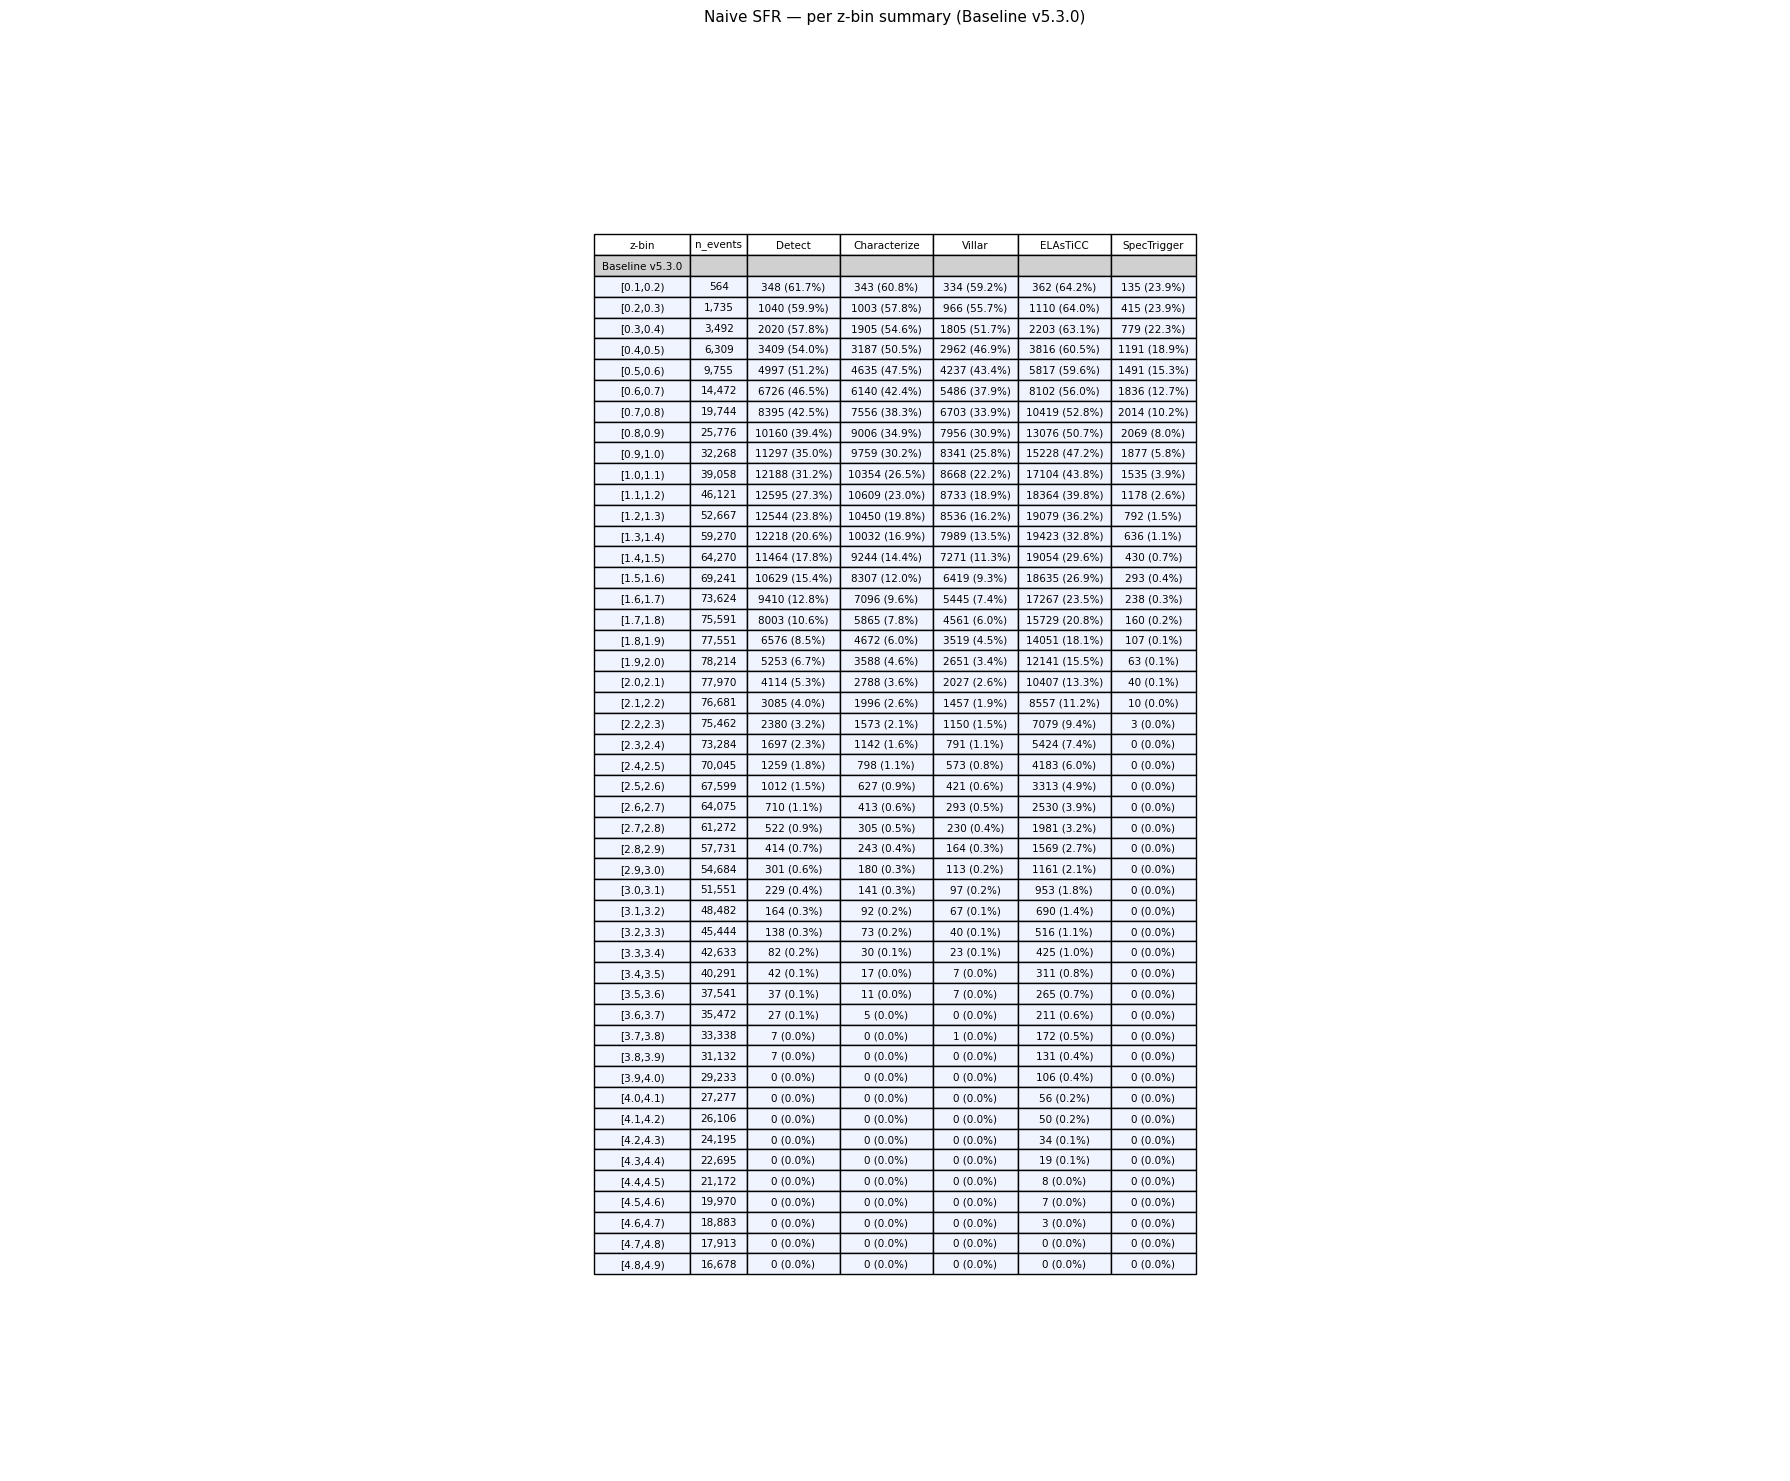


MODEL: O-dependent

  Cadence: Baseline v5.3.0
         z-bin   n_events          Detect    Characterize          Villar        ELAsTiCC     SpecTrigger
  -------------------------------------------------------------------------------------------------------
  [0.1,0.2)         630    408 ( 64.8%)    391 ( 62.1%)    384 ( 61.0%)    425 ( 67.5%)    168 ( 26.7%)
  [0.2,0.3)       1,728   1042 ( 60.3%)    993 ( 57.5%)    949 ( 54.9%)   1114 ( 64.5%)    415 ( 24.0%)
  [0.3,0.4)       3,589   2074 ( 57.8%)   1980 ( 55.2%)   1888 ( 52.6%)   2242 ( 62.5%)    808 ( 22.5%)
  [0.4,0.5)       6,335   3488 ( 55.1%)   3275 ( 51.7%)   3023 ( 47.7%)   3902 ( 61.6%)   1187 ( 18.7%)
  [0.5,0.6)      10,040   5122 ( 51.0%)   4722 ( 47.0%)   4315 ( 43.0%)   5947 ( 59.2%)   1611 ( 16.0%)
  [0.6,0.7)      14,640   6895 ( 47.1%)   6273 ( 42.8%)   5657 ( 38.6%)   8270 ( 56.5%)   1961 ( 13.4%)
  [0.7,0.8)      20,551   8851 ( 43.1%)   7992 ( 38.9%)   7003 ( 34.1%)  10942 ( 53.2%)   2126 ( 10.3%)
  [0.8,0.9) 

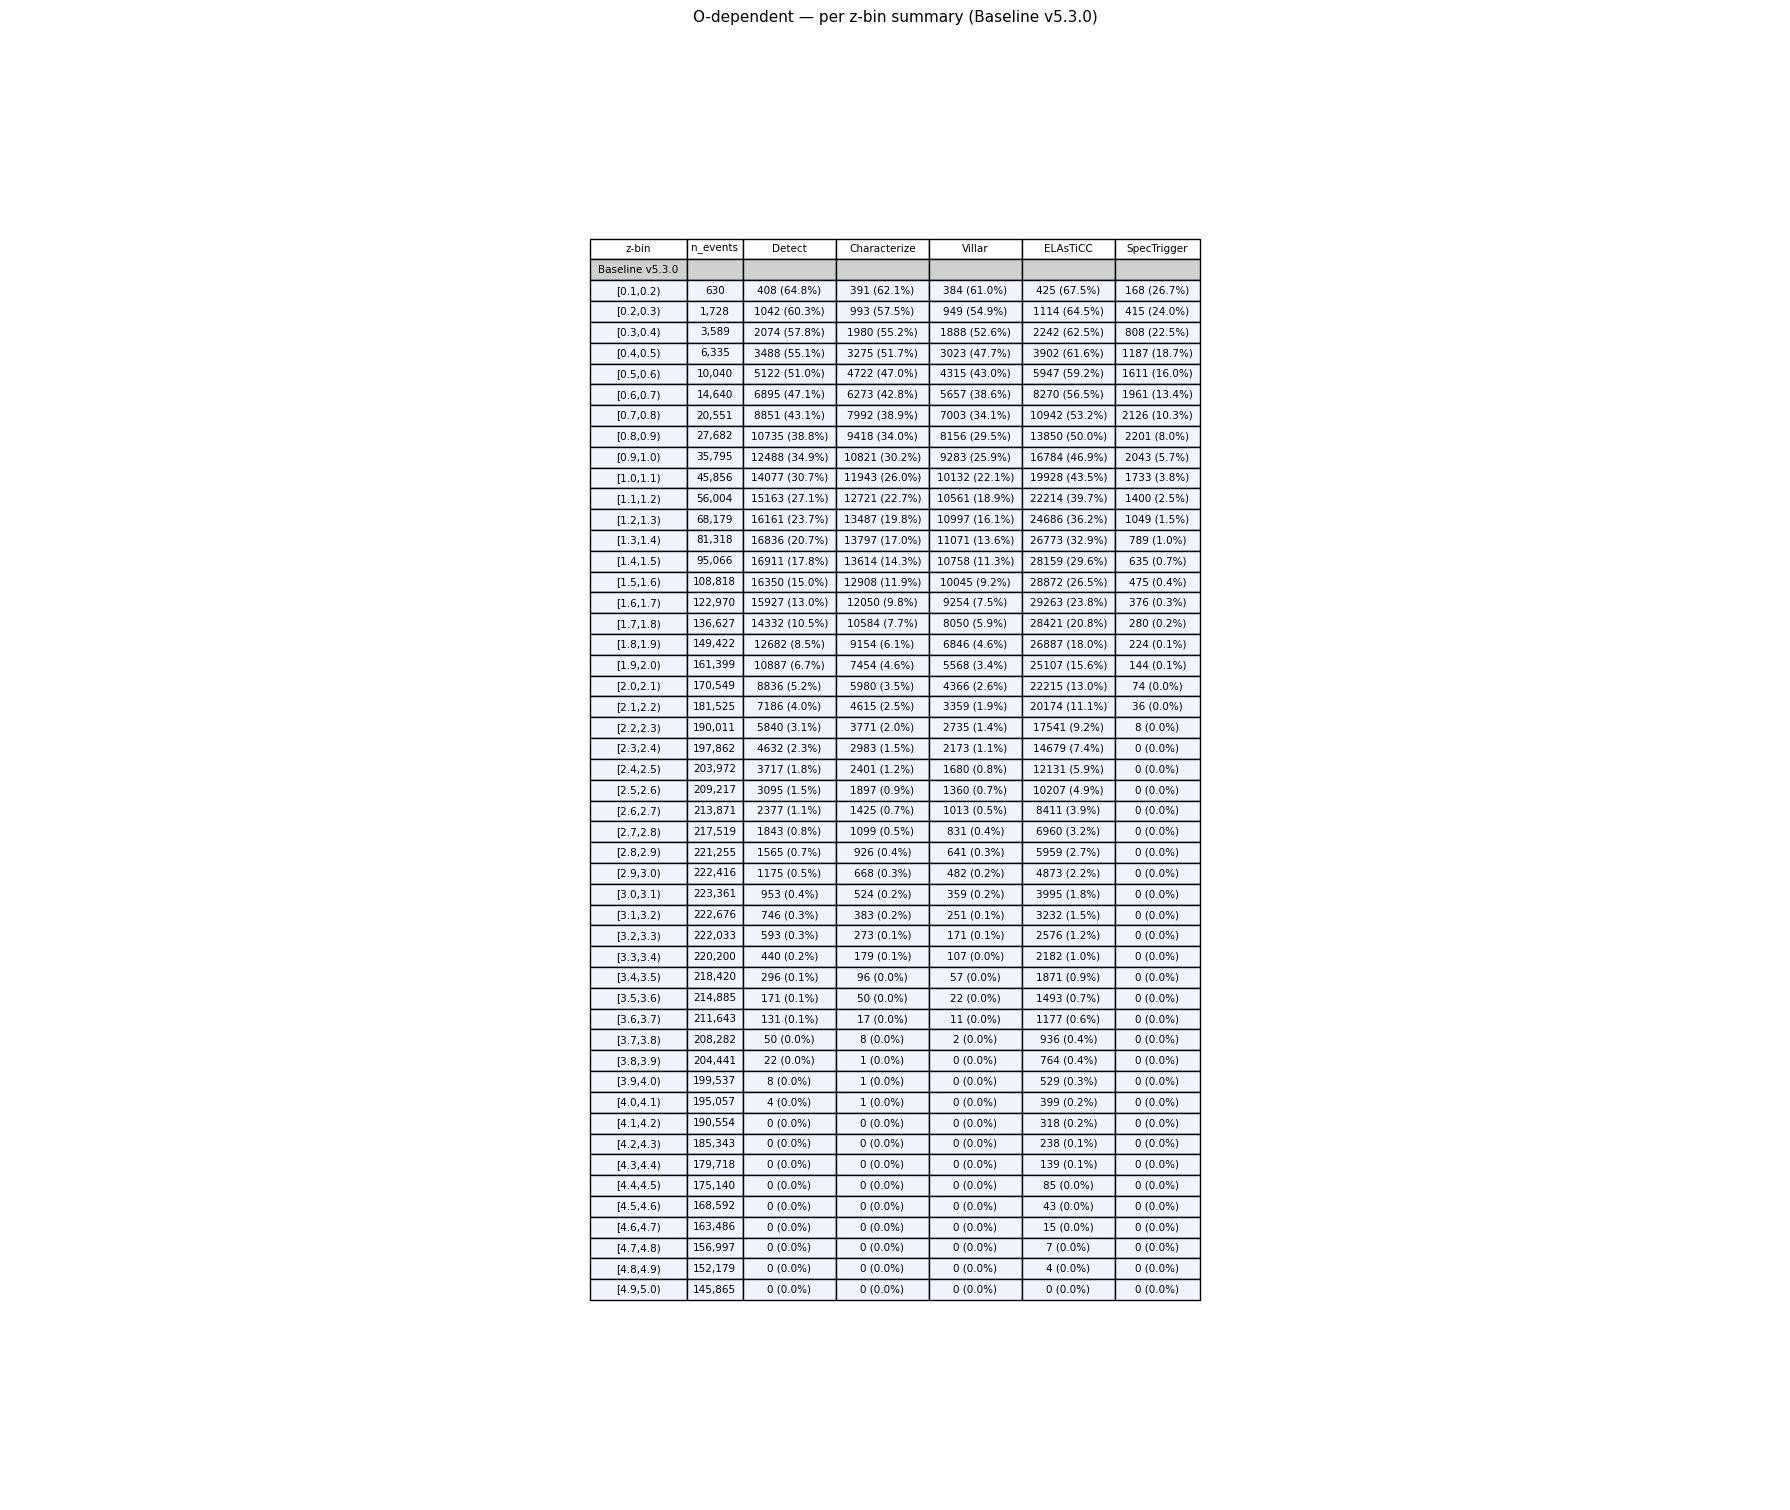


MODEL: Fe-dependent

  Cadence: Baseline v5.3.0
         z-bin   n_events          Detect    Characterize          Villar        ELAsTiCC     SpecTrigger
  -------------------------------------------------------------------------------------------------------
  [0.1,0.2)         607    397 ( 65.4%)    384 ( 63.3%)    356 ( 58.6%)    409 ( 67.4%)    152 ( 25.0%)
  [0.2,0.3)       1,775   1080 ( 60.8%)   1041 ( 58.6%)    995 ( 56.1%)   1133 ( 63.8%)    457 ( 25.7%)
  [0.3,0.4)       4,116   2330 ( 56.6%)   2210 ( 53.7%)   2071 ( 50.3%)   2559 ( 62.2%)    921 ( 22.4%)
  [0.4,0.5)       7,873   4300 ( 54.6%)   4036 ( 51.3%)   3758 ( 47.7%)   4758 ( 60.4%)   1530 ( 19.4%)
  [0.5,0.6)      13,299   6827 ( 51.3%)   6326 ( 47.6%)   5759 ( 43.3%)   7923 ( 59.6%)   2120 ( 15.9%)
  [0.6,0.7)      20,555   9690 ( 47.1%)   8828 ( 42.9%)   7851 ( 38.2%)  11534 ( 56.1%)   2723 ( 13.2%)
  [0.7,0.8)      30,694  13336 ( 43.4%)  12027 ( 39.2%)  10557 ( 34.4%)  16477 ( 53.7%)   3194 ( 10.4%)
  [0.8,0.9)

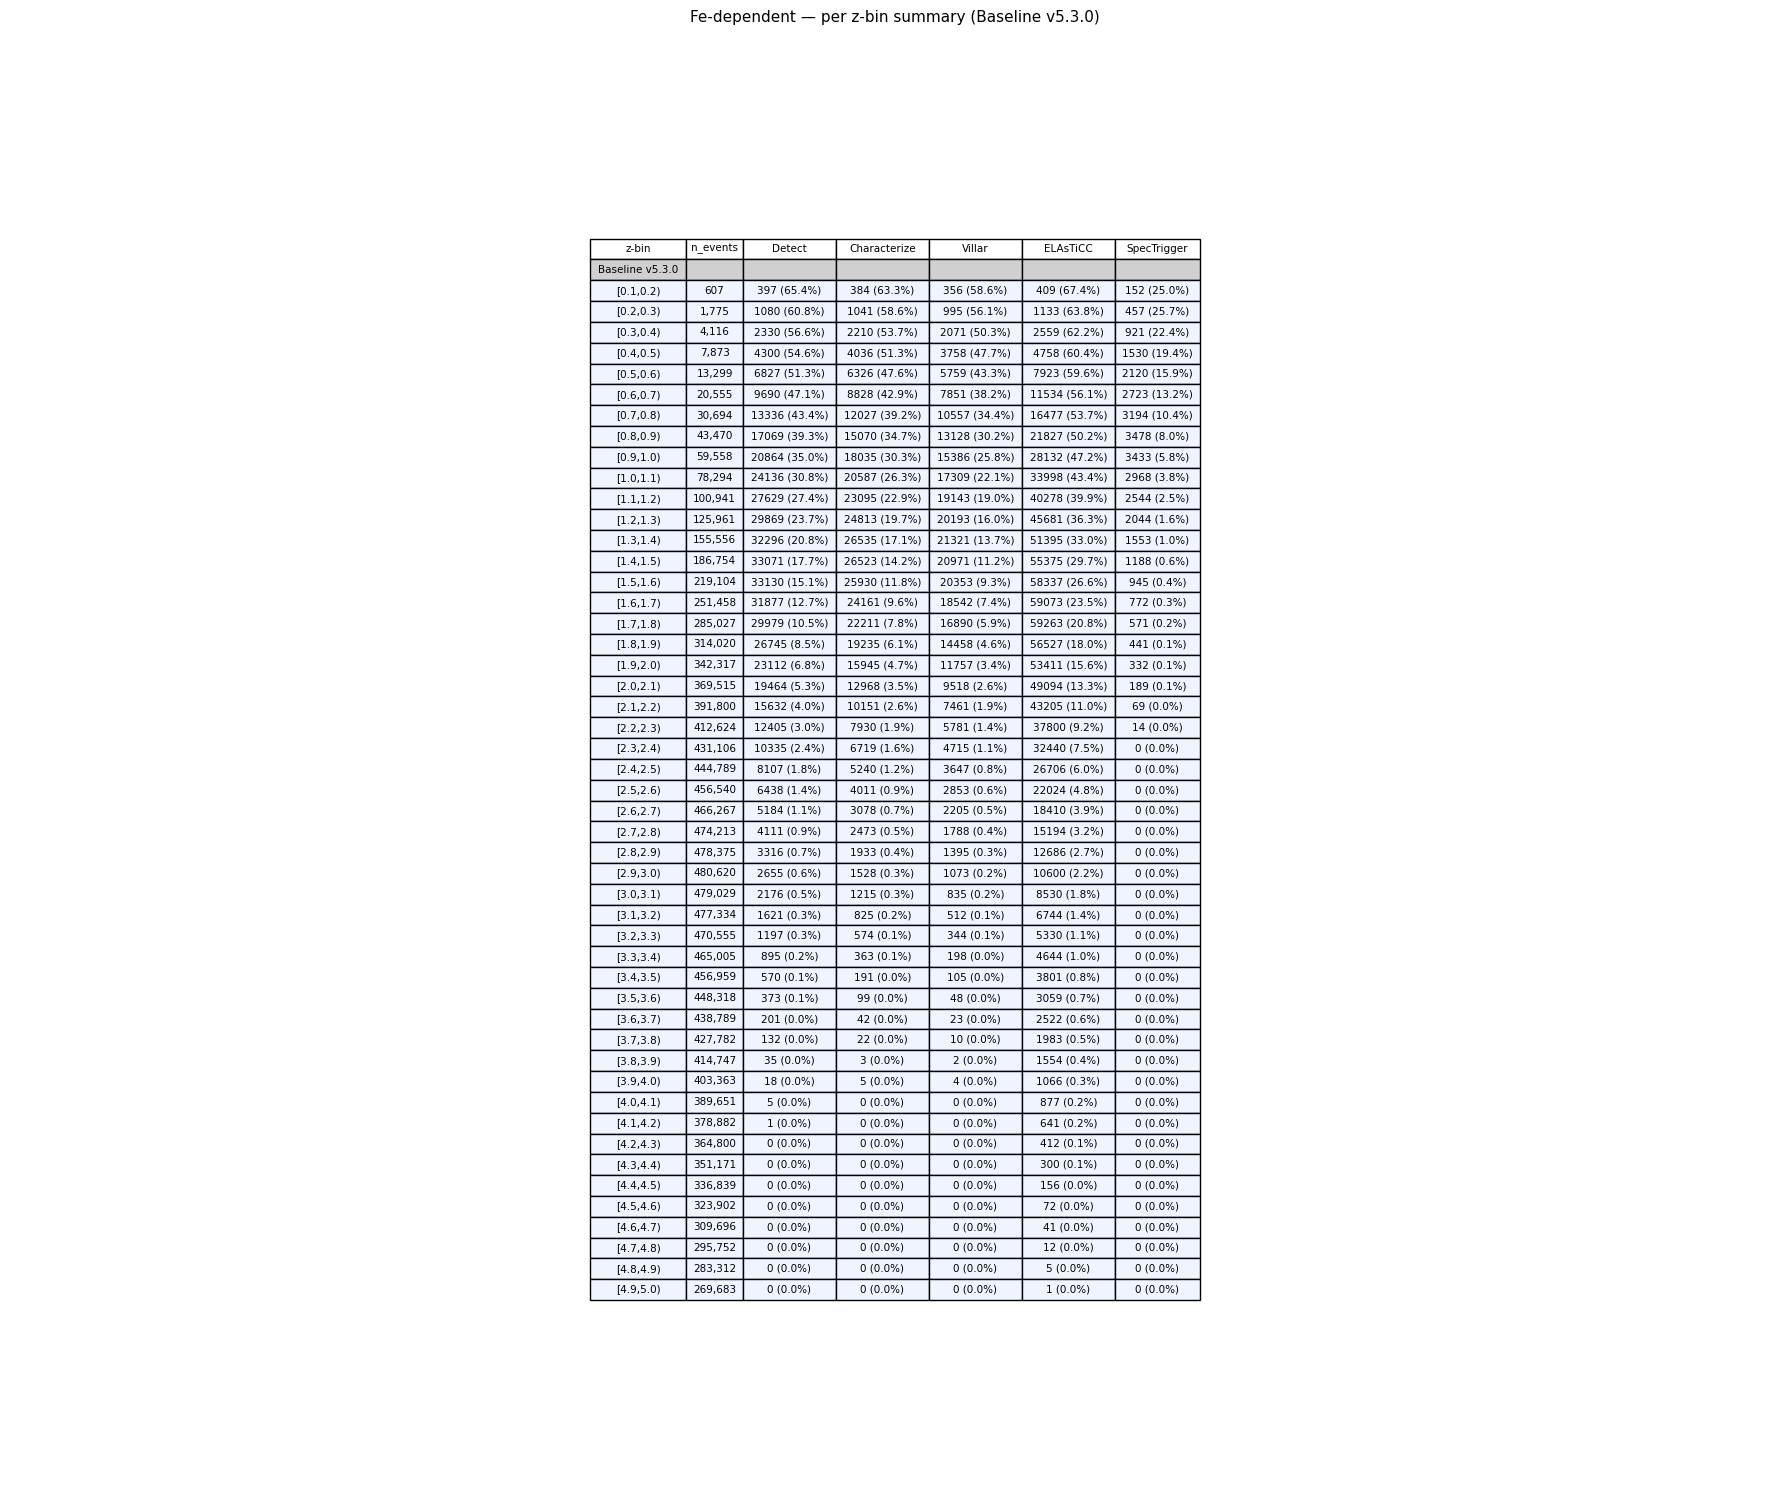

In [12]:
# ============================================================================
# CELL 20: Summary tables — one per model, cadences as row groups
# Rows = z-bins, Columns = metrics, values = n_success (efficiency%)
# METRIC_LABELS, CADENCE_LABELS, MODEL_LABELS come from Cell 1.
# ============================================================================

PLOT_CADENCES_20 = ['baseline_v5.3.0_10yrs']

METRIC_ORDER = list(METRIC_MAP.values())   # full class names, canonical order

for model in MODELS:
    df = ADAPTIVE[model].copy()
    z_bins = sorted(df[['z_lo','z_hi']].drop_duplicates().values.tolist())

    print(f"\n{'='*90}")
    print(f"MODEL: {MODEL_LABELS[model]}")
    print(f"{'='*90}")

    for cadence in PLOT_CADENCES_20:
        print(f"\n  Cadence: {CADENCE_LABELS.get(cadence, cadence)}")
        header = f"  {'z-bin':>12} {'n_events':>10}"
        for m in METRIC_ORDER:
            header += f"  {METRIC_LABELS[m]:>14}"
        print(header)
        print("  " + "-" * (len(header) - 2))

        for z_lo, z_hi in z_bins:
            row_data = df[
                (df['z_lo'] == z_lo) &
                (df['z_hi'] == z_hi) &
                (df['cadence'] == cadence)
            ]
            if row_data.empty:
                continue
            n_ev = int(row_data['n_events'].iloc[0])
            row_str = f"  [{z_lo:.1f},{z_hi:.1f})  {n_ev:>10,}"
            for m in METRIC_ORDER:
                mrow = row_data[row_data['metric'] == m]
                if mrow.empty:
                    row_str += f"  {'—':>14}"
                else:
                    n_suc = int(mrow['n_success'].iloc[0])
                    eff   = float(mrow['efficiency'].iloc[0]) * 100
                    row_str += f"  {n_suc:>5} ({eff:>5.1f}%)"
            print(row_str)

    col_headers = ['z-bin', 'n_events'] + [METRIC_LABELS[m] for m in METRIC_ORDER]
    all_rows    = []
    all_colors  = []
    section_colors = ['#f0f4ff', '#fff8f0']

    for ci, cadence in enumerate(PLOT_CADENCES_20):
        sec_color = section_colors[ci % 2]
        cad_label = CADENCE_LABELS.get(cadence, cadence)

        all_rows.append([cad_label] + [''] * (len(col_headers) - 1))
        all_colors.append(['#d0d0d0'] * len(col_headers))

        for z_lo, z_hi in z_bins:
            row_data = df[
                (df['z_lo'] == z_lo) &
                (df['z_hi'] == z_hi) &
                (df['cadence'] == cadence)
            ]
            if row_data.empty:
                continue
            n_ev = int(row_data['n_events'].iloc[0])
            row = [f'[{z_lo:.1f},{z_hi:.1f})', f'{n_ev:,}']
            for m in METRIC_ORDER:
                mrow = row_data[row_data['metric'] == m]
                if mrow.empty:
                    row.append('—')
                else:
                    n_suc = int(mrow['n_success'].iloc[0])
                    eff   = float(mrow['efficiency'].iloc[0]) * 100
                    row.append(f'{n_suc} ({eff:.1f}%)')
            all_rows.append(row)
            all_colors.append([sec_color] * len(col_headers))

    fig_h = max(4, 0.28 * len(all_rows) + 1.2)
    fig, ax = plt.subplots(figsize=(18, fig_h))
    ax.axis('off')
    tbl = ax.table(
        cellText   = all_rows,
        colLabels  = col_headers,
        cellColours= all_colors,
        loc        = 'center',
        cellLoc    = 'center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7.5)
    tbl.auto_set_column_width(col=list(range(len(col_headers))))
    ax.set_title(f'{MODEL_LABELS[model]} — per z-bin summary ({CADENCE_LABELS.get(PLOT_CADENCES_20[0], "")})',
                 fontsize=11, pad=12)
    plt.tight_layout()
    out_fig = get_output_dir('SLSNe', subdir=model) / f'summary_table_{model}.png'
    plt.savefig(str(out_fig), dpi=150, bbox_inches='tight')
    print(f'\n  Saved: {out_fig.name}')
    plt.show()


In [13]:
# Cell 21 - AUDIT TABLE — summary of figure above
# Detect metric: n_success and efficiency per z-bin — baseline_v5.3.0 only
# Non-zero bins only; matches the figure's PLOT_CADENCES_11 = ['baseline_v5.3.0_10yrs']
import pandas as pd
_rows14 = []
for _mdl14 in MODELS:
    _df14 = ADAPTIVE[_mdl14]
    _sub14 = _df14[
        (_df14['cadence'] == 'baseline_v5.3.0_10yrs') &
        (_df14['metric'] == 'SLSN_Detect_Physical_Metric') &
        (_df14['n_success'] > 0)
    ][['z_lo','z_hi','n_events','n_success','efficiency']].copy()
    _sub14.insert(0, 'model', _mdl14.replace('_physical',''))
    _sub14['eff_%'] = (_sub14['efficiency'] * 100).round(1)
    _rows14.append(_sub14)
_tbl14 = pd.concat(_rows14, ignore_index=True)
print("Detect efficiency summary — baseline_v5.3.0 (non-zero z-bins only)")
print(_tbl14[['model','z_lo','z_hi','n_events','n_success','eff_%']].to_string(index=False))

Detect efficiency summary — baseline_v5.3.0 (non-zero z-bins only)
       model  z_lo  z_hi  n_events  n_success  eff_%
       naive   0.1   0.2       564        348   61.7
       naive   0.2   0.3      1735       1040   59.9
       naive   0.3   0.4      3492       2020   57.8
       naive   0.4   0.5      6309       3409   54.0
       naive   0.5   0.6      9755       4997   51.2
       naive   0.6   0.7     14472       6726   46.5
       naive   0.7   0.8     19744       8395   42.5
       naive   0.8   0.9     25776      10160   39.4
       naive   0.9   1.0     32268      11297   35.0
       naive   1.0   1.1     39058      12188   31.2
       naive   1.1   1.2     46121      12595   27.3
       naive   1.2   1.3     52667      12544   23.8
       naive   1.3   1.4     59270      12218   20.6
       naive   1.4   1.5     64270      11464   17.8
       naive   1.5   1.6     69241      10629   15.4
       naive   1.6   1.7     73624       9410   12.8
       naive   1.7   1.8     755

Saved: sed_peak_suppression_2019qgk.png
Event: 2019qgk
MOSFiT lambda_0 = 5335.3 A, alpha = 0.7974
Visual departure edge = 1814 A


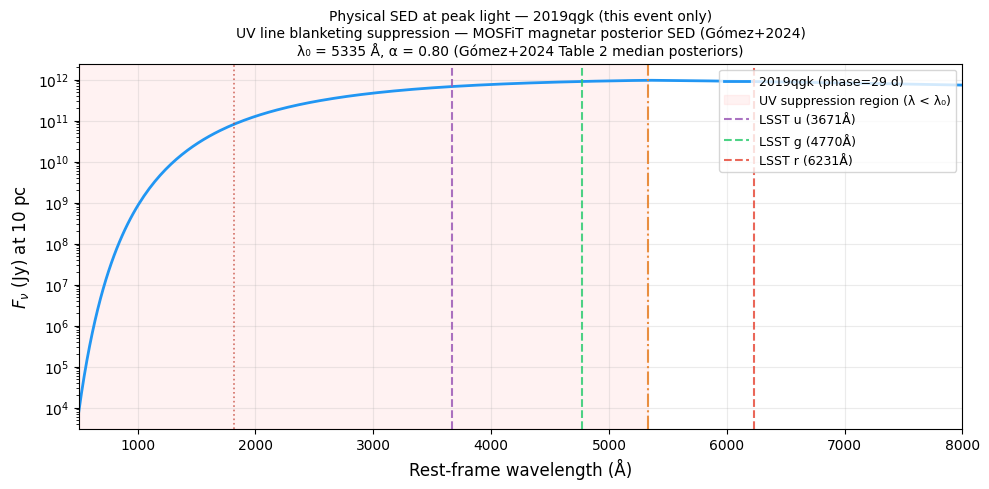

In [14]:
# ============================================================================
# CELL 22: SED at peak light — UV line blanketing suppression
# Shows physical SED Fnu vs rest-frame wavelength for one event at peak
# Illustrates why g-band fails at high z (UV suppression)
# ============================================================================
# Reload flags:
#   Templates  : NO — loads physical_templates.pkl directly
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggles
EVENT_IDX  = 100   # index into sed_grid/names (0–264); 100 = 2019qgk
SHOW_ANNOT = True  # show suppression edge annotation

import joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Load physical templates
tpl_path  = get_output_dir('SLSNe', subdir='shared') / 'physical_templates.pkl'
templates = joblib.load(tpl_path)
sg        = templates['sed_grid']
names     = templates['names']

# --- Select event and find peak phase ---
s         = sg[EVENT_IDX]
event_name = names[EVENT_IDX]
lam        = s['lam_rest_A']          # (500,) Angstroms
fnu        = s['Fnu_abs']             # (161, 500) Jy at 10 pc
phase      = s['phase']               # (161,) days

total_flux = fnu.sum(axis=1)
peak_idx   = np.argmax(total_flux)
peak_phase = phase[peak_idx]
fnu_peak   = fnu[peak_idx, :]        # (500,) Jy at peak

# --- Load MOSFiT posterior parameters for this event ---
params_path = get_output_dir('SLSNe').parent / 'all_events' / 'allparameter.csv'
params_df   = pd.read_csv(params_path)
event_row   = params_df[params_df['name'] == event_name]
if len(event_row) > 0:
    mosfit_lambda0 = float(event_row['cutoff_wavelength_med'].iloc[0])
    mosfit_alpha   = float(event_row['alpha_med'].iloc[0])
else:
    mosfit_lambda0 = None
    mosfit_alpha   = None
    print(f'Warning: {event_name} not found in allparameter.csv')

# --- Visual suppression edge: wavelength where flux drops to 10%
#     of optical mean. This is NOT the MOSFiT lambda_0 parameter —
#     it is the observed departure from the Planck curve. ---
opt_mask   = (lam >= 3000) & (lam < 8000)
opt_mean   = fnu_peak[opt_mask].mean()
supp_candidates = lam[(fnu_peak < 0.1 * opt_mean) & (lam < 4000)]
supp_edge  = supp_candidates.max() if len(supp_candidates) > 0 else None

# --- LSST filter centers (Angstroms) ---
lsst_centers = {
    'u': 3671,
    'g': 4770,
    'r': 6231,
}
lsst_colors = {'u': '#9b59b6', 'g': '#2ecc71', 'r': '#e74c3c'}

# --- Plot ---
LAM_MIN, LAM_MAX = 500, 8000
mask_plot = (lam >= LAM_MIN) & (lam <= LAM_MAX)

fig, ax = plt.subplots(figsize=(10, 5))

# SED line
ax.semilogy(lam[mask_plot], fnu_peak[mask_plot],
            color='#2196F3', lw=2.0,
            label=f'{event_name} (phase={peak_phase:.0f} d)')

# UV suppression shaded region — extends to MOSFiT lambda_0
# Everything blueward of lambda_0 is suppressed by the power law
supp_max = mosfit_lambda0 if mosfit_lambda0 is not None else 3000
ax.axvspan(LAM_MIN, supp_max, color='#ffcccc', alpha=0.25,
           label=f'UV suppression region (λ < λ₀)')

# LSST filter center lines
for fname, fcen in lsst_centers.items():
    ax.axvline(fcen, color=lsst_colors[fname], lw=1.5,
               ls='--', alpha=0.85, label=f'LSST {fname} ({fcen}Å)')

if SHOW_ANNOT:
    # Annotation 1: visual departure from Planck curve
    if supp_edge is not None:
        ax.axvline(supp_edge, color='#c0392b', lw=1.2, ls=':', alpha=0.7)
        ax.annotate(
            f'Visual departure from\nPlanck curve (~{supp_edge:.0f} Å)',
            xy=(supp_edge, 1e2),
            xytext=(supp_edge + 400, 1e3),
            fontsize=8, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.0),
        )

    # Annotation 2: MOSFiT lambda_0
    if mosfit_lambda0 is not None:
        ax.axvline(mosfit_lambda0, color='#e67e22', lw=1.5, ls='-.', alpha=0.85)
        ax.annotate(
            f'MOSFiT λ₀ = {mosfit_lambda0:.0f} Å\n(α = {mosfit_alpha:.2f})',
            xy=(mosfit_lambda0, 1e3),
            xytext=(mosfit_lambda0 - 2500, 1e2),
            fontsize=8, color='#e67e22',
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.0),
        )

ax.set_xlim(LAM_MIN, LAM_MAX)
ax.set_xlabel('Rest-frame wavelength (Å)', fontsize=12)
ax.set_ylabel(r'$F_\nu$ (Jy) at 10 pc', fontsize=12)
ax.set_title(
    f'Physical SED at peak light — {event_name} (this event only)\n'
    f'UV line blanketing suppression — MOSFiT magnetar posterior SED '
    f'(Gómez+2024)\n'
    f'λ₀ = {mosfit_lambda0:.0f} Å, α = {mosfit_alpha:.2f} '
    f'(Gómez+2024 Table 2 median posteriors)',
    fontsize=10
)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.25)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / f'sed_peak_suppression_{event_name}.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
print(f'Event: {event_name}')
print(f'MOSFiT lambda_0 = {mosfit_lambda0:.1f} A, alpha = {mosfit_alpha:.4f}')
print(f'Visual departure edge = {supp_edge:.0f} A' if supp_edge else 'No visual edge found')
plt.show()

In [15]:
# Cell 23 - AUDIT TABLE — summary of figure above
# Physical SED for 2019qgk at peak: Fnu at LSST filter centers + UV wavelengths
# Suppression edge = wavelength where Fnu < 10% of optical mean (Fnu[3000-8000Å])
import pandas as pd
_wls15   = sorted(list(lsst_centers.values()) + [1500, 2000, 2500, 3000])
_rows15  = []
for _wl15 in _wls15:
    _idx15 = np.argmin(np.abs(lam - _wl15))
    _filt15 = next((f'LSST-{k}' for k, v in lsst_centers.items() if v == _wl15), '—')
    _rows15.append({'lam_A': int(lam[_idx15]), 'filter': _filt15,
                    'Fnu_Jy': f"{fnu_peak[_idx15]:.4e}"})
print(f"SED at peak — {event_name}  (phase={peak_phase:.0f} d)")
print(f"MOSFiT lambda0={mosfit_lambda0:.0f} Å  alpha={mosfit_alpha:.2f}")
print(f"Visual suppression edge (flux < 10% opt mean): {supp_edge:.0f} Å" if supp_edge else "No suppression edge found")
print(pd.DataFrame(_rows15).to_string(index=False))

SED at peak — 2019qgk  (phase=29 d)
MOSFiT lambda0=5335 Å  alpha=0.80
Visual suppression edge (flux < 10% opt mean): 1814 Å
 lam_A filter     Fnu_Jy
  1490      — 2.5810e+10
  1997      — 1.2618e+11
  2505      — 2.9036e+11
  2988      — 4.6234e+11
  3680 LSST-u 6.7717e+11
  4763 LSST-g 8.9474e+11
  6238 LSST-r 8.9129e+11


Saved: sed_decomposition_2019qgk.png


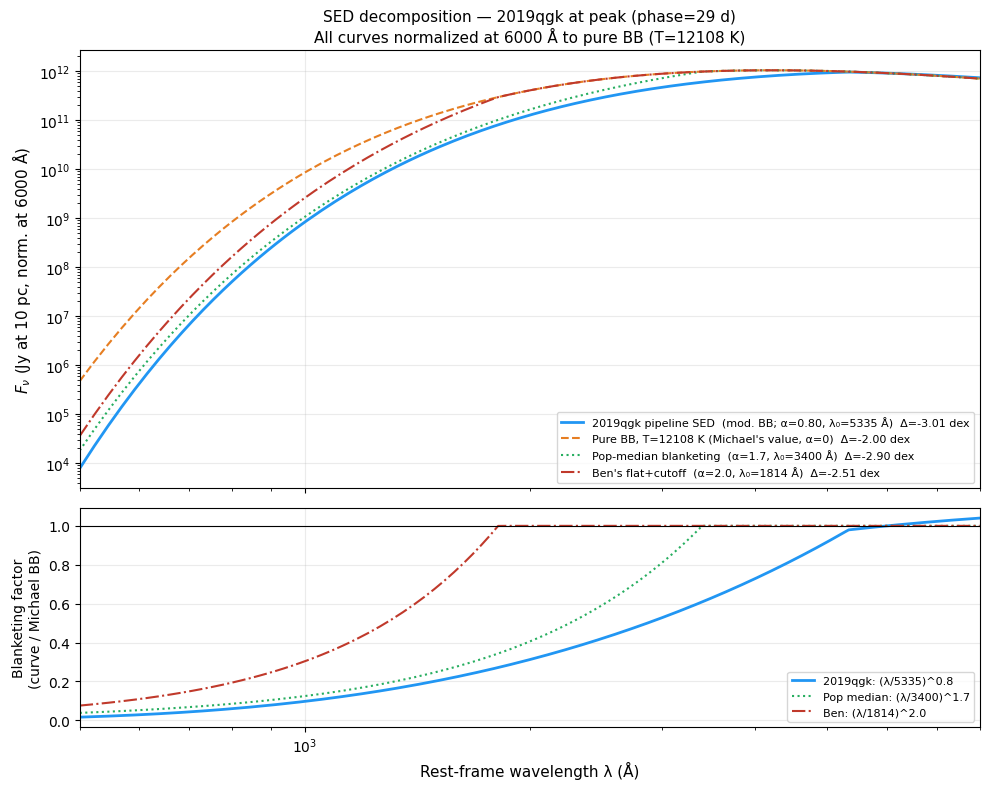

In [16]:
# ============================================================================
# CELL 24: SED decomposition — pipeline vs pure BB vs population median vs Ben
# Replicates Michael's decomposition plot to verify pipeline temperature
# Shows: (1) pipeline SED, (2) pure BB at T=5214K and T=12108K,
#         (3) pop-median blanketing, (4) Ben's flat+cutoff approximation
# ============================================================================
# Reload flags:
#   Templates  : NO — uses physical_templates.pkl already loaded above
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Load pipeline SED for 2019qgk at phase=29 days ---
tpl_path  = get_output_dir('SLSNe', subdir='shared') / 'physical_templates.pkl'
templates = joblib.load(tpl_path)
entry     = templates['sed_grid'][100]  # 2019qgk
lam       = entry['lam_rest_A']         # (500,) Angstrom
fnu_all   = entry['Fnu_abs']            # (161, 500) Jy at 10 pc
phase     = entry['phase']

# Peak phase
total_flux = fnu_all.sum(axis=1)
peak_idx   = np.argmax(total_flux)
peak_phase = phase[peak_idx]
fnu_pipe   = fnu_all[peak_idx, :]       # pipeline SED at peak

# --- Load posterior parameters for 2019qgk ---
params_path = get_output_dir('SLSNe').parent / 'all_events' / 'allparameter.csv'
params_df   = pd.read_csv(params_path)
row         = params_df[params_df['name'] == '2019qgk'].iloc[0]
alpha_event = float(row['alpha_med'])
lam0_event  = float(row['cutoff_wavelength_med'])
Tmin_event  = float(row['temperature_med'])

# --- Population median parameters (Gomez+2024 Table 2) ---
alpha_pop = 1.7
lam0_pop  = 3400.0   # Angstrom

# --- Ben's assumed parameters ---
alpha_ben = 2.0
lam0_ben  = 1814.0   # Angstrom — visual departure point, not MOSFiT lambda0

# --- Build pure blackbody F_nu at two temperatures ---
h    = 6.62607e-34   # J*s
c    = 2.998e8       # m/s
k_B  = 1.38065e-23  # J/K
lam_m = lam * 1e-10  # Angstrom to meters

def planck_fnu(lam_m, T):
    """F_nu proportional to Planck function — dimensionless ratio safe."""
    h   = 6.626e-34   # J*s
    c   = 2.998e8     # m/s  
    k_B = 1.381e-23   # J/K
    x   = h * c / (lam_m * k_B * T)
    # Avoid overflow for large x
    x   = np.clip(x, 0, 500)
    return 1.0 / (lam_m**3 * (np.exp(x) - 1))

# Two temperatures to compare
T_tmin   = Tmin_event   # 5214 K — pipeline Tmin floor
T_michael = 12108.0     # K — from Michael's plot

bb_tmin    = planck_fnu(lam_m, T_tmin)
bb_michael = planck_fnu(lam_m, T_michael)

# --- Apply blanketing to pure BB ---
def apply_blanketing(bb, lam, lam0, alpha):
    """Apply power-law blanketing blueward of lam0."""
    result = bb.copy()
    blue = lam < lam0
    result[blue] *= (lam[blue] / lam0) ** alpha
    return result

bb_pop = apply_blanketing(bb_michael.copy(), lam, lam0_pop, alpha_pop)
bb_ben = apply_blanketing(bb_michael.copy(), lam, lam0_ben, alpha_ben)

# --- Normalize all curves to match pipeline SED at 6000 Angstrom ---
ref_idx = np.argmin(np.abs(lam - 6000))
norm_pipe    = fnu_pipe[ref_idx]
norm_tmin    = bb_tmin[ref_idx]
norm_michael = bb_michael[ref_idx]
norm_pop     = bb_pop[ref_idx]
norm_ben     = bb_ben[ref_idx]

fnu_pipe_n    = fnu_pipe    / norm_pipe    * norm_pipe
bb_tmin_n     = bb_tmin     / norm_tmin    * norm_pipe
bb_michael_n  = bb_michael  / norm_michael * norm_pipe
bb_pop_n      = bb_pop      / norm_pop     * norm_pipe
bb_ben_n      = bb_ben      / norm_ben     * norm_pipe

# --- Compute delta (dex) at 1000A vs 6000A for each curve ---
idx_1000 = np.argmin(np.abs(lam - 1000))
idx_6000 = np.argmin(np.abs(lam - 6000))

def delta_dex(arr):
    return np.log10(arr[idx_1000] / arr[idx_6000])

# --- Plot ---
LAM_MIN, LAM_MAX = 500, 8000
mask = (lam >= LAM_MIN) & (lam <= LAM_MAX)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8),
                                sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Top panel — SEDs
ax1.semilogy(lam[mask], fnu_pipe_n[mask],
             color='#2196F3', lw=2.0,
             label=f'2019qgk pipeline SED  '
                   f'(mod. BB; α={alpha_event:.2f}, λ₀={lam0_event:.0f} Å)  '
                   f'Δ={delta_dex(fnu_pipe_n):.2f} dex')
ax1.semilogy(lam[mask], bb_michael_n[mask],
             color='#e67e22', lw=1.5, ls='--',
             label=f'Pure BB, T={T_michael:.0f} K (Michael\'s value, α=0)  '
                   f'Δ={delta_dex(bb_michael_n):.2f} dex')
ax1.semilogy(lam[mask], bb_pop_n[mask],
             color='#27ae60', lw=1.5, ls=':',
             label=f'Pop-median blanketing  '
                   f'(α={alpha_pop}, λ₀={lam0_pop:.0f} Å)  '
                   f'Δ={delta_dex(bb_pop_n):.2f} dex')
ax1.semilogy(lam[mask], bb_ben_n[mask],
             color='#c0392b', lw=1.5, ls='-.',
             label=f"Ben's flat+cutoff  "
                   f'(α={alpha_ben}, λ₀={lam0_ben:.0f} Å)  '
                   f'Δ={delta_dex(bb_ben_n):.2f} dex')

ax1.set_ylabel(r'$F_\nu$ (Jy at 10 pc, norm. at 6000 Å)', fontsize=11)
ax1.set_title(
    f'SED decomposition — 2019qgk at peak (phase={peak_phase:.0f} d)\n'
    f'All curves normalized at 6000 Å to pure BB (T={T_michael:.0f} K)',
    fontsize=11
)
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(alpha=0.25)

# Bottom panel — blanketing factor = curve / pure BB (Michael's T)
def blanketing_factor(arr, ref):
    return arr / ref

ax2.semilogx(lam[mask],
             blanketing_factor(fnu_pipe_n, bb_michael_n)[mask],
             color='#2196F3', lw=2.0,
             label=f'2019qgk: (λ/{lam0_event:.0f})^{alpha_event:.1f}')
ax2.semilogx(lam[mask],
             blanketing_factor(bb_pop_n, bb_michael_n)[mask],
             color='#27ae60', lw=1.5, ls=':',
             label=f'Pop median: (λ/{lam0_pop:.0f})^{alpha_pop}')
ax2.semilogx(lam[mask],
             blanketing_factor(bb_ben_n, bb_michael_n)[mask],
             color='#c0392b', lw=1.5, ls='-.',
             label=f"Ben: (λ/{lam0_ben:.0f})^{alpha_ben}")

ax2.axhline(1.0, color='k', lw=0.8, ls='-')
ax2.set_xlabel('Rest-frame wavelength λ (Å)', fontsize=11)
ax2.set_ylabel('Blanketing factor\n(curve / Michael BB)', fontsize=10)
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(alpha=0.25)
ax2.set_xlim(LAM_MIN, LAM_MAX)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / 'sed_decomposition_2019qgk.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()

In [17]:
# Cell 25 - AUDIT TABLE — summary of figure above
# SED decomposition: blanketing parameters and Fnu at key wavelengths
# Curves are normalized to match pipeline SED at 6000 Å (see cell above).
import pandas as pd
print("Blanketing parameters used in Cell 16:")
_params16 = pd.DataFrame([
    {'model': '2019qgk (event)',   'alpha': alpha_event, 'lambda0_A': lam0_event,  'T_K': Tmin_event},
    {'model': 'pop median (G+24)', 'alpha': alpha_pop,   'lambda0_A': lam0_pop,    'T_K': 'N/A'},
    {'model': "Ben's approx",      'alpha': alpha_ben,   'lambda0_A': lam0_ben,    'T_K': 'N/A'},
])
print(_params16.to_string(index=False))
print()
_wls16  = [1500, 2000, 2500, 3000, 4000, 5000, 6000]
_rows16 = []
for _wl16 in _wls16:
    _idx16 = np.argmin(np.abs(lam - _wl16))
    _rows16.append({'lam_A': int(lam[_idx16]),
                    'pipe_Fnu': f"{fnu_pipe[_idx16]:.4e}",
                    'BB_5214K':  f"{bb_tmin[_idx16]:.4e}",
                    'BB_12108K': f"{bb_michael[_idx16]:.4e}"})
print("Unnormalized Fnu at key wavelengths (pipeline vs pure BB):")
print(pd.DataFrame(_rows16).to_string(index=False))

Blanketing parameters used in Cell 16:
            model   alpha  lambda0_A         T_K
  2019qgk (event) 0.79737 5335.32436  5213.96757
pop median (G+24) 1.70000 3400.00000         N/A
     Ben's approx 2.00000 1814.00000         N/A

Unnormalized Fnu at key wavelengths (pipeline vs pure BB):
 lam_A   pipe_Fnu   BB_5214K  BB_12108K
  1490 2.5810e+10 2.7779e+12 1.0455e+17
  1997 1.2618e+11 1.2634e+14 3.2889e+17
  2505 2.9036e+11 1.0486e+15 5.5941e+17
  2988 4.6234e+11 3.6725e+15 7.1700e+17
  4003 7.5717e+11 1.5856e+16 8.4504e+17
  4993 9.2399e+11 3.2154e+16 8.1990e+17
  6008 9.1076e+11 4.7207e+16 7.4090e+17


Saved: gband_cliff_2019qgk.png


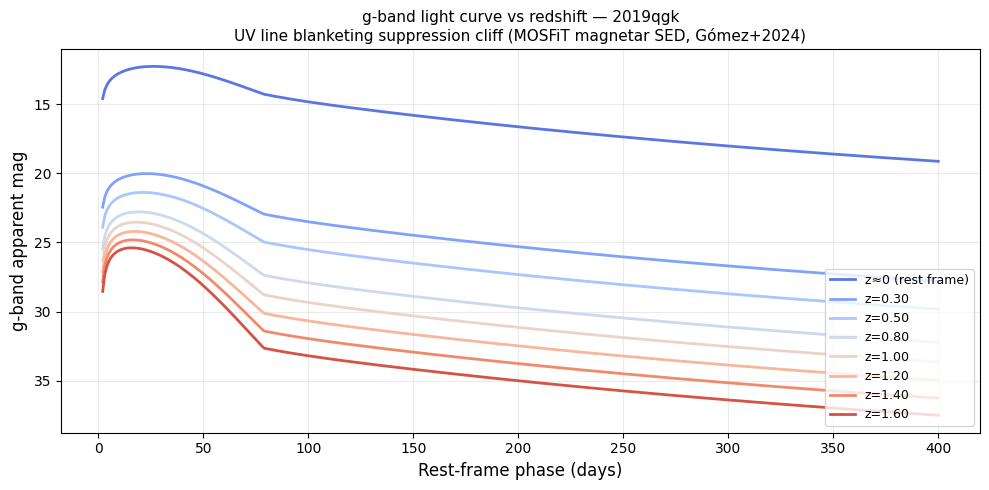

In [18]:
# ============================================================================
# CELL 26: g-band light curve at multiple redshifts — UV suppression cliff
# Shows how line blanketing suppresses g-band as SED redshifts into UV
# One line per redshift, shape-aligned (DM offset removed)
# ============================================================================
# Reload flags:
#   Templates  : NO — loads physical_templates.pkl directly
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggles
EVENT_IDX    = 100                   # 2019qgk — same event as SED plot
REDSHIFTS    = [0.01, 0.3, 0.5, 0.8, 1.0, 1.2, 1.4, 1.6]
ALIGN_CURVES = False                  # remove DM vertical offset, show shape only

import joblib
import numpy as np
import matplotlib.pyplot as plt
from slsn_metrics.model import synthesize_mag_at_z

# Load physical templates
tpl_path   = get_output_dir('SLSNe', subdir='shared') / 'physical_templates.pkl'
templates  = joblib.load(tpl_path)
sg         = templates['sed_grid']
names      = templates['names']

event_name = names[EVENT_IDX]
sed_grid   = sg[EVENT_IDX]
phases     = np.array(sed_grid['phase'])   # (161,) rest-frame days

# Colors from blue (low-z) to red (high-z)
z_colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(REDSHIFTS)))

fig, ax = plt.subplots(figsize=(10, 5))

for zi, (z, col) in enumerate(zip(REDSHIFTS, z_colors)):
    mags = np.array([
        synthesize_mag_at_z(sed_grid, float(ph), z, 'g')
        for ph in phases
    ])

    valid = np.isfinite(mags)
    if valid.sum() < 3:
        print(f'[skip] z={z:.2f} — fewer than 3 finite magnitudes')
        continue

    ph_plot  = phases[valid]
    mag_plot = mags[valid]

    # Align curves vertically by subtracting mean — isolates shape
    if ALIGN_CURVES:
        mag_plot = mag_plot - np.nanmean(mag_plot)

    zlabel = 'z≈0 (rest frame)' if z < 0.05 else f'z={z:.2f}'
    ax.plot(ph_plot, mag_plot,
            color=col, lw=2.0, label=zlabel)

ax.invert_yaxis()
ax.set_xlabel('Rest-frame phase (days)', fontsize=12)
ylabel = 'Δg-band mag (shape only, DM removed)' if ALIGN_CURVES else 'g-band apparent mag'
ax.set_ylabel(ylabel, fontsize=12)
ax.set_title(
    f'g-band light curve vs redshift — {event_name}\n'
    f'UV line blanketing suppression cliff (MOSFiT magnetar SED, Gómez+2024)',
    fontsize=11
)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.25)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / f'gband_cliff_{event_name}.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()

In [19]:
# Cell 27 - AUDIT TABLE — summary of figure above
# g-band LC for 2019qgk: only last loop iteration (z=1.60) in memory post-loop.
# ph_plot and mag_plot are already finite-filtered (phases[valid], mags[valid]),
# so index them directly — do not re-apply an isfinite mask.
import pandas as pd
_tbl17 = pd.DataFrame({
    'phase_day':                    ph_plot[::15],
    f'g_mag_z{REDSHIFTS[-1]:.2f}': np.round(mag_plot[::15], 3),
})
print(f"g-band LC — {event_name} | last iteration z={REDSHIFTS[-1]:.2f}  ALIGN_CURVES={ALIGN_CURVES}")
print(f"({len(REDSHIFTS)} redshifts plotted; only last-loop z retained in memory)")
print(_tbl17.to_string(index=False))

g-band LC — 2019qgk | last iteration z=1.60  ALIGN_CURVES=False
(8 redshifts plotted; only last-loop z retained in memory)
 phase_day  g_mag_z1.60
       2.0       28.542
      17.0       25.396
      32.0       26.135
      47.0       27.737
      62.0       29.920
      77.0       32.356
      92.0       33.009
     130.0       33.812
     205.0       35.081
     280.0       36.140
     355.0       37.031


Event: 2019qgk | Peak phase: 29.0 days
Valid redshift points: 36/36
Divergence point (>0.5 mag excess): z=0.91
Saved: gband_cliff_vs_z_2019qgk.png


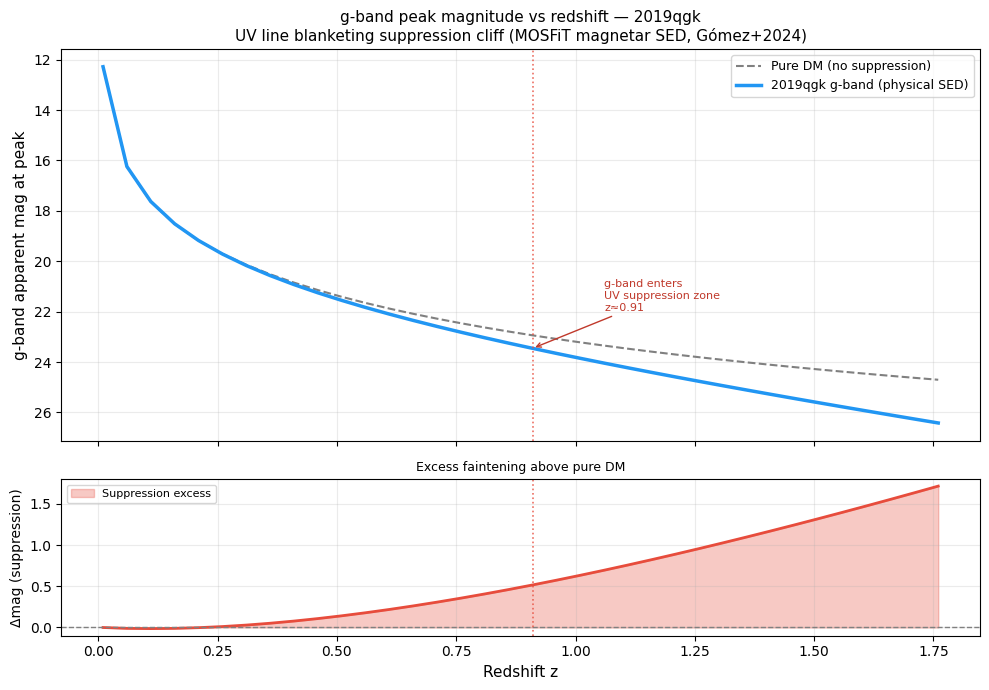

The divergence at z=0.31 means g-band is sampling rest-frame ~3670Å at that point. From the SED plot, the suppression edge for 2019qgk was at ~1814Å.
So this divergence at z=0.31 is not the hard UV suppression floor — it's the color gradient of the SED in the 3000–4000Å range (the SED is already declining toward UV before hitting the suppression floor).
The hard floor suppression dominates at higher z. 


In [20]:
# ============================================================================
# CELL 28: g-band peak magnitude vs redshift — UV suppression cliff
# X axis: redshift z (fine grid)
# Y axis: g-band apparent mag at peak light for one event
# Bottom panel: residual Δmag = observed - pure DM (suppression signal)
# ============================================================================
# Reload flags:
#   Templates  : NO — uses templates already loaded above
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggles
EVENT_IDX = 100                        # 2019qgk
REDSHIFTS = np.arange(0.01, 1.8, 0.05)

from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

# --- Find peak phase ---
sed_grid   = sg[EVENT_IDX]
event_name = names[EVENT_IDX]
phases     = np.array(sed_grid['phase'])
peak_phase = phases[np.argmax(np.array(sed_grid['Fnu_abs']).sum(axis=1))]
print(f'Event: {event_name} | Peak phase: {peak_phase:.1f} days')

# --- Synthesize g-band mag at peak across redshift grid ---
peak_mags = []
for z in REDSHIFTS:
    m = synthesize_mag_at_z(sed_grid, float(peak_phase), z, 'g')
    peak_mags.append(m)
peak_mags = np.array(peak_mags)

valid = np.isfinite(peak_mags)
print(f'Valid redshift points: {valid.sum()}/{len(REDSHIFTS)}')

# --- Pure DM reference anchored to first valid point ---
DM_ref = np.array([
    5 * np.log10(cosmo.luminosity_distance(z).to_value(u.pc) / 10.0)
    for z in REDSHIFTS
])
offset         = peak_mags[valid][0] - DM_ref[valid][0]
DM_ref_anchored = DM_ref + offset

# --- Residual: how much fainter than pure DM ---
residual = peak_mags - DM_ref_anchored   # positive = fainter than DM alone

# --- Find divergence point: first z where residual > 0.5 mag ---
div_candidates = REDSHIFTS[valid][residual[valid] > 0.5]
div_z = div_candidates[0] if len(div_candidates) > 0 else None
print(f'Divergence point (>0.5 mag excess): z={div_z:.2f}' if div_z else 'No divergence found')

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(10, 7),
                         gridspec_kw={'height_ratios': [3, 1.2]},
                         sharex=True)

# Top panel — mag vs z
ax = axes[0]
ax.plot(REDSHIFTS[valid], DM_ref_anchored[valid],
        color='gray', lw=1.5, ls='--', label='Pure DM (no suppression)')
ax.plot(REDSHIFTS[valid], peak_mags[valid],
        color='#2196F3', lw=2.5, label=f'{event_name} g-band (physical SED)')

# Divergence annotation
if div_z is not None:
    div_mag = peak_mags[np.argmin(np.abs(REDSHIFTS - div_z))]
    ax.axvline(div_z, color='#e74c3c', lw=1.2, ls=':', alpha=0.8)
    ax.annotate(
        f'g-band enters\nUV suppression zone\nz≈{div_z:.2f}',
        xy=(div_z, div_mag),
        xytext=(div_z + 0.15, div_mag - 1.5),
        fontsize=8, color='#c0392b',
        arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.0),
    )

ax.invert_yaxis()
ax.set_ylabel('g-band apparent mag at peak', fontsize=11)
ax.set_title(
    f'g-band peak magnitude vs redshift — {event_name}\n'
    f'UV line blanketing suppression cliff (MOSFiT magnetar SED, Gómez+2024)',
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

# Bottom panel — residual
ax2 = axes[1]
ax2.fill_between(REDSHIFTS[valid], 0, residual[valid],
                 color='#e74c3c', alpha=0.3, label='Suppression excess')
ax2.plot(REDSHIFTS[valid], residual[valid],
         color='#e74c3c', lw=2.0)
ax2.axhline(0, color='gray', lw=1.0, ls='--')
if div_z is not None:
    ax2.axvline(div_z, color='#e74c3c', lw=1.2, ls=':', alpha=0.8)
ax2.set_xlabel('Redshift z', fontsize=11)
ax2.set_ylabel('Δmag (suppression)', fontsize=10)
ax2.set_title('Excess faintening above pure DM', fontsize=9)
ax2.grid(alpha=0.25)
ax2.legend(fontsize=8)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / f'gband_cliff_vs_z_{event_name}.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()
print(f"The divergence at z=0.31 means g-band is sampling rest-frame ~3670Å at that point. From the SED plot, the suppression edge for 2019qgk was at ~1814Å.")
print(f"So this divergence at z=0.31 is not the hard UV suppression floor — it's the color gradient of the SED in the 3000–4000Å range (the SED is already declining toward UV before hitting the suppression floor).")
print(f"The hard floor suppression dominates at higher z. ")

In [21]:
# Cell 29: AUDIT TABLE — summary of figure above
# g-band peak magnitude vs redshift (2019qgk) — every 4th grid point (~0.2 z step)
import pandas as pd
_v18 = np.isfinite(peak_mags)
_tbl18 = pd.DataFrame({
    'z':            np.round(REDSHIFTS[_v18][::4], 2),
    'g_peak_mag':   np.round(peak_mags[_v18][::4], 2),
    'DM_ref':       np.round(DM_ref_anchored[_v18][::4], 2),
    'residual_mag': np.round(residual[_v18][::4], 3),
})
print(f"g-band peak mag vs z — {event_name}  (peak_phase={peak_phase:.0f} d)")
print(f"UV suppression divergence (>0.5 mag excess): z={div_z:.2f}" if div_z else "No divergence found")
print(_tbl18.to_string(index=False))

g-band peak mag vs z — 2019qgk  (peak_phase=29 d)
UV suppression divergence (>0.5 mag excess): z=0.91
   z  g_peak_mag  DM_ref  residual_mag
0.01       12.28   12.28         0.000
0.21       19.17   19.18        -0.002
0.41       20.92   20.85         0.078
0.61       22.10   21.88         0.219
0.81       23.03   22.63         0.407
1.01       23.85   23.22         0.633
1.21       24.59   23.70         0.890
1.41       25.28   24.11         1.172
1.61       25.94   24.46         1.475


Total templates:         265
CSVs found:              265
Pass ≥2 filters:         251 (94.7%)
Pass ≥15d baseline:       261 (98.5%)
Pass ≥2 detections:       263 (99.2%)
Has rise evidence:       261 (98.5%)
Pass ALL criteria:       250 (94.3%)

Saved: v1_catalog_coverage_completeness.png


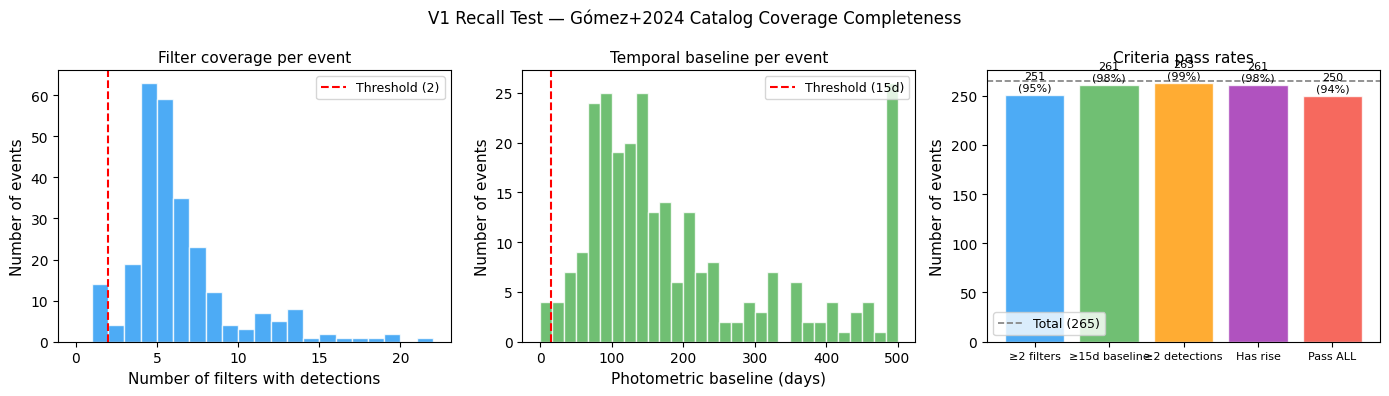


Events failing ALL criteria:
     name  n_filters  baseline_days  n_det  has_rise
   1999bz          1       0.000000      1     False
   2011ep          1      73.119873     22      True
   2014bl          1     404.119873     40      True
  2017beq          2      12.273710      3      True
  2017hbx          1     134.977359      7     False
  2017jan          1     886.743590     71      True
CSS160710          1      49.080070     29      True
iPTF13bjz          1      21.111000     18      True
 LSQ14fxj          1       0.000000      1     False
MLS121104          1       0.120118      4      True
 OGLE15sd          1     133.858440     46      True
 OGLE15xl          1     106.895410     29      True
 OGLE15xx          1      67.747120     19      True
OGLE16dmu          1     238.586770     58      True
 PTF10bjp          1      91.848000     22      True


In [22]:
# ============================================================================
# CELL 30: Recall test — catalog coverage completeness check
# For each Gómez+2024 event, assess whether observed photometry
# has sufficient coverage to in-principle pass detection criteria
# independent of LSST depth
# ============================================================================
# IMPORTANT CAVEAT — Physical track vs GP track interpretation:
#
# This recall test validates the *observed per-event CSVs* (Gómez+2024),
# which are the direct input to the GP template system.
#
# For the PHYSICAL track, templates are derived from MOSFiT posterior
# parameters, not directly from the CSVs. Physical templates:
#   - Cover post-peak phases only (day 1–400, no pre-peak rise)
#   - Extend to UV (500A) via the magnetar model
#   - Are well-sampled by construction (161 phases x 500 wavelengths)
#     regardless of observed CSV sparsity
#
# Therefore V1 for the physical track answers:
#   "Is the catalog input data quality sufficient for MOSFiT fitting?"
#   NOT "Are the physical templates themselves well-sampled?"
#
# The absence of pre-peak phases in physical templates is a known
# limitation — events detectable only during rise may be systematically
# missed. This connects to V3 (efficiency loss decomposition).
# ============================================================================
# Reload flags:
#   Templates  : NO
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO

import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from pathlib import Path

# --- Config ---
PER_EVENT_DIR = Path('output/per_event_files')
MIN_FILTERS   = 2      # Detect criterion: ≥2 filters
MIN_BASELINE  = 15     # days
MIN_DETECTIONS = 2     # minimum detected (non-UL) observations

# Load template names for index alignment check
import joblib
tpl       = joblib.load('output/SLSNe/shared/physical_templates.pkl')
tpl_names = tpl['names']   # 265 names in template order

# --- Loop over all 265 base CSVs ---
results = []
for name in tpl_names:
    csv_path = PER_EVENT_DIR / f'{name}.csv'
    if not csv_path.exists():
        results.append({
            'name': name, 'found': False,
            'n_det': 0, 'n_filters': 0,
            'baseline_days': 0, 'has_rise': False,
            'pass_filters': False, 'pass_baseline': False,
            'pass_ndet': False, 'pass_all': False,
        })
        continue

    df = pd.read_csv(csv_path)

    # Only use non-upper-limit detections
    det = df[df['detected'] == 1].copy()
    n_det     = len(det)
    n_filters = det['filter'].nunique() if n_det > 0 else 0
    baseline  = (det['mjd'].max() - det['mjd'].min()) if n_det > 1 else 0

    # Rise check: any filter with ≥2 detections where mag decreases (brightens)
    has_rise = False
    if n_det >= 2:
        for filt, grp in det.groupby('filter'):
            grp = grp.sort_values('mjd')
            if len(grp) >= 2:
                # Brightening = magnitude decreasing
                if (grp['mag'].diff().dropna() < 0).any():
                    has_rise = True
                    break

    pass_filters  = n_filters >= MIN_FILTERS
    pass_baseline = baseline  >= MIN_BASELINE
    pass_ndet     = n_det     >= MIN_DETECTIONS
    pass_all      = pass_filters and pass_baseline and pass_ndet

    results.append({
        'name':          name,
        'found':         True,
        'n_det':         n_det,
        'n_filters':     n_filters,
        'baseline_days': baseline,
        'has_rise':      has_rise,
        'pass_filters':  pass_filters,
        'pass_baseline': pass_baseline,
        'pass_ndet':     pass_ndet,
        'pass_all':      pass_all,
    })

df_v1 = pd.DataFrame(results)

# --- Summary ---
n_total    = len(df_v1)
n_found    = df_v1['found'].sum()
n_pass_all = df_v1['pass_all'].sum()
n_pass_filt= df_v1['pass_filters'].sum()
n_pass_base= df_v1['pass_baseline'].sum()
n_has_rise = df_v1['has_rise'].sum()

print(f'Total templates:         {n_total}')
print(f'CSVs found:              {n_found}')
print(f'Pass ≥{MIN_FILTERS} filters:         {n_pass_filt} ({100*n_pass_filt/n_total:.1f}%)')
print(f'Pass ≥{MIN_BASELINE}d baseline:       {n_pass_base} ({100*n_pass_base/n_total:.1f}%)')
print(f'Pass ≥{MIN_DETECTIONS} detections:       {df_v1["pass_ndet"].sum()} ({100*df_v1["pass_ndet"].sum()/n_total:.1f}%)')
print(f'Has rise evidence:       {n_has_rise} ({100*n_has_rise/n_total:.1f}%)')
print(f'Pass ALL criteria:       {n_pass_all} ({100*n_pass_all/n_total:.1f}%)')

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Filter count distribution
axes[0].hist(df_v1['n_filters'], bins=range(0, df_v1['n_filters'].max()+2),
             color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(MIN_FILTERS, color='red', ls='--', lw=1.5,
                label=f'Threshold ({MIN_FILTERS})')
axes[0].set_xlabel('Number of filters with detections', fontsize=11)
axes[0].set_ylabel('Number of events', fontsize=11)
axes[0].set_title('Filter coverage per event', fontsize=11)
axes[0].legend(fontsize=9)

# Baseline distribution
axes[1].hist(df_v1['baseline_days'].clip(upper=500), bins=30,
             color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].axvline(MIN_BASELINE, color='red', ls='--', lw=1.5,
                label=f'Threshold ({MIN_BASELINE}d)')
axes[1].set_xlabel('Photometric baseline (days)', fontsize=11)
axes[1].set_ylabel('Number of events', fontsize=11)
axes[1].set_title('Temporal baseline per event', fontsize=11)
axes[1].legend(fontsize=9)

# Pass/fail summary bar
categories = ['≥2 filters', f'≥{MIN_BASELINE}d baseline',
              f'≥{MIN_DETECTIONS} detections', 'Has rise', 'Pass ALL']
counts     = [n_pass_filt, n_pass_base,
              int(df_v1['pass_ndet'].sum()), n_has_rise, n_pass_all]
colors     = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
bars = axes[2].bar(categories, counts, color=colors, alpha=0.8, edgecolor='white')
axes[2].axhline(n_total, color='gray', ls='--', lw=1.2, label=f'Total ({n_total})')
for bar, count in zip(bars, counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{count}\n({100*count/n_total:.0f}%)',
                 ha='center', va='bottom', fontsize=8)
axes[2].set_ylabel('Number of events', fontsize=11)
axes[2].set_title('Criteria pass rates', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].tick_params(axis='x', labelsize=8)

plt.suptitle('V1 Recall Test — Gómez+2024 Catalog Coverage Completeness', fontsize=12)
plt.tight_layout()

out_fig = get_output_dir('SLSNe') / 'v1_catalog_coverage_completeness.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'\nSaved: {out_fig.name}')
plt.show()
# Show the 15 events that fail all criteria
failed = df_v1[~df_v1['pass_all']][['name','n_filters','baseline_days','n_det','has_rise']]
print('\nEvents failing ALL criteria:')
print(failed.to_string(index=False))

In [23]:
# Cell 31 - AUDIT TABLE — summary of figure above
# V1 recall test: pass/fail counts for all 265 Gómez+2024 events
import pandas as pd
_tbl19 = pd.DataFrame([
    {'criterion': 'CSV found',
     'n_pass': df_v1['found'].sum(),       'n_fail': (~df_v1['found']).sum()},
    {'criterion': f'>={MIN_FILTERS} filters',
     'n_pass': df_v1['pass_filters'].sum(), 'n_fail': (~df_v1['pass_filters']).sum()},
    {'criterion': f'>={MIN_BASELINE}d baseline',
     'n_pass': df_v1['pass_baseline'].sum(),'n_fail': (~df_v1['pass_baseline']).sum()},
    {'criterion': f'>={MIN_DETECTIONS} detections',
     'n_pass': df_v1['pass_ndet'].sum(),    'n_fail': (~df_v1['pass_ndet']).sum()},
    {'criterion': 'has_rise',
     'n_pass': df_v1['has_rise'].sum(),     'n_fail': (~df_v1['has_rise']).sum()},
    {'criterion': 'ALL criteria',
     'n_pass': df_v1['pass_all'].sum(),     'n_fail': (~df_v1['pass_all']).sum()},
])
_tbl19['pct_pass'] = (_tbl19['n_pass'] / len(df_v1) * 100).round(1).astype(str) + '%'
print(f"V1 Recall Test — {len(df_v1)} events total")
print(_tbl19.to_string(index=False))

V1 Recall Test — 265 events total
     criterion  n_pass  n_fail pct_pass
     CSV found     265       0   100.0%
   >=2 filters     251      14    94.7%
>=15d baseline     261       4    98.5%
>=2 detections     263       2    99.2%
      has_rise     261       4    98.5%
  ALL criteria     250      15    94.3%


[load_tabulated_rate] model='naive'
  CSV    : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/fiducial_models.csv
  Anchor : 35.0 Gpc^-3 yr^-1 at z=0.17 (Frohmaier+2021)
  R(z=0.17) = 3.500e-08 Mpc^-3 yr^-1
  R(z=1.00) = 1.332e-07 Mpc^-3 yr^-1
  R(z=2.00) = 2.026e-07 Mpc^-3 yr^-1
[load_tabulated_rate] model='o_dependent'
  CSV    : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/fiducial_models.csv
  Anchor : 35.0 Gpc^-3 yr^-1 at z=0.17 (Frohmaier+2021)
  R(z=0.17) = 3.502e-08 Mpc^-3 yr^-1
  R(z=1.00) = 1.505e-07 Mpc^-3 yr^-1
  R(z=2.00) = 4.303e-07 Mpc^-3 yr^-1
[load_tabulated_rate] model='fe_dependent'
  CSV    : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/fiducial_models.csv
  Anchor : 35.0 Gpc^-3 yr^-1 at z=0.17 (Frohmaier+2021)
  R(z=0.17) = 3.473e-08 Mpc^-3 yr^-1
  R(z=1.00) = 2.537e-07 Mpc^-3 yr^-1
  R(z=2.00) = 9.216e-07 Mpc^-3 yr^-1
Saved: crossing_curve

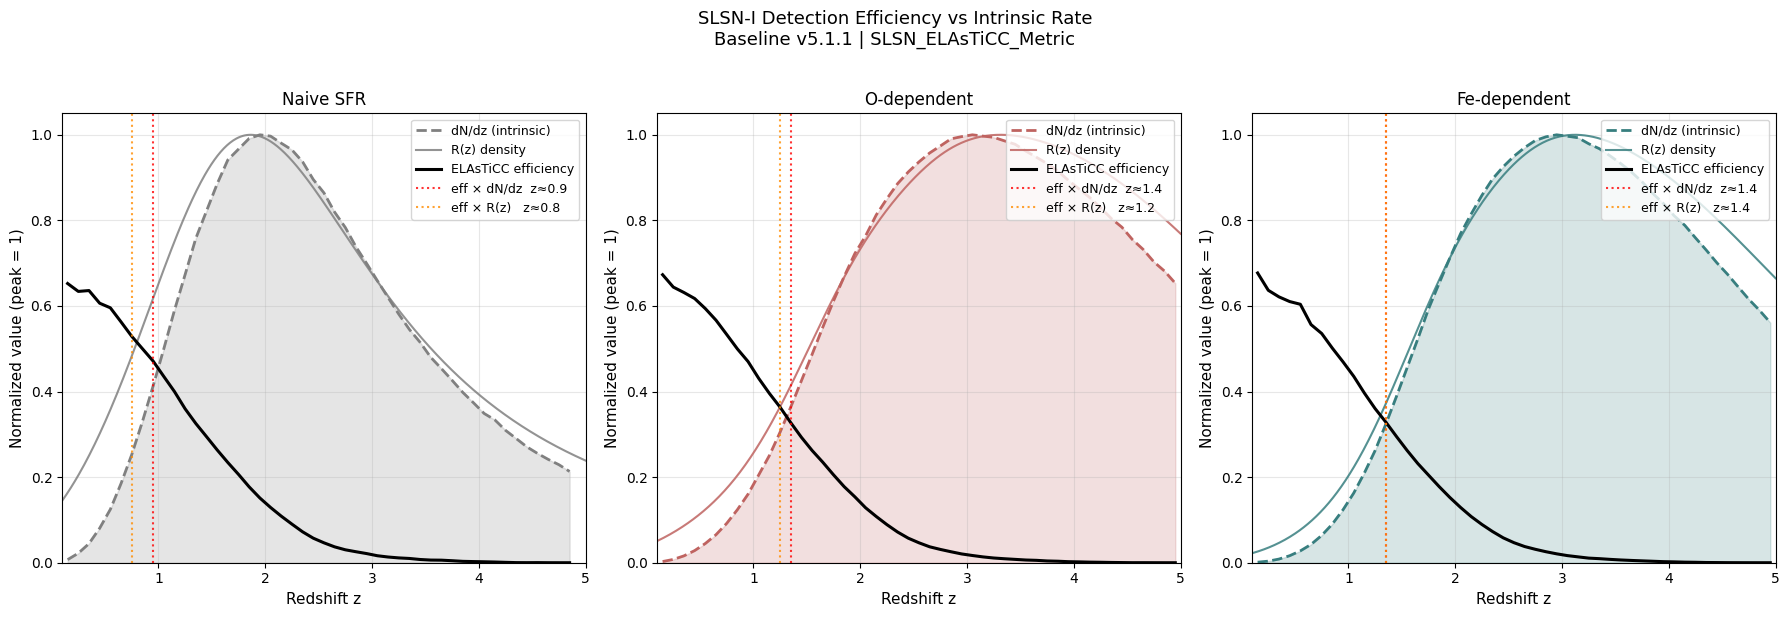

In [24]:
# ============================================================================
# CELL 33: Crossing-curves figure
# Three normalized curves per panel on a single shared 0-1 axis:
#   1. dN/dz (colored fill + dashed)  — n_events from adaptive CSV
#   2. R(z)  (thin colored solid)     — rate density from fiducial_models.csv
#   3. Efficiency (black solid)       — ELAsTiCC metric from adaptive CSV
#
# Two crossing lines:
#   Red dotted    — where efficiency meets dN/dz (population-weighted threshold)
#   Orange dotted — where efficiency meets R(z)  (rate-density threshold)
#
# MODEL_COLORS, MODEL_LABELS, CADENCE_LABELS from Cell 1.
# Reload flags: Templates NO — Population NO — Mag grid NO — Kernel NO
# ============================================================================

import matplotlib.ticker as mticker
from slsn_metrics.population import load_tabulated_rate
from slsn_metrics.paths import get_rate_csv_path

CROSSING_CADENCE = 'baseline_v5.1.1_10yrs'
CROSSING_METRIC  = 'SLSN_ELAsTiCC_Metric'

Z_GRID = np.linspace(0.1, 5.0, 500)

rate_csv  = str(get_rate_csv_path())
Rz_interp = {}
for model in MODELS:
    model_base       = model.replace('_physical', '')
    Rz_interp[model] = load_tabulated_rate(rate_csv, model_base)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'SLSN-I Detection Efficiency vs Intrinsic Rate\n'
    f'{CADENCE_LABELS[CROSSING_CADENCE]} | {CROSSING_METRIC}',
    fontsize=13, y=1.02
)

for ax, model in zip(axes, MODELS):
    color = MODEL_COLORS[model]
    label = MODEL_LABELS[model]

    df   = ADAPTIVE[model]
    mask = (df['cadence'] == CROSSING_CADENCE) & (df['metric'] == CROSSING_METRIC)
    df_m = df[mask].copy().sort_values('z_lo').reset_index(drop=True)

    if df_m.empty:
        ax.set_title(f'{label}\n[NO DATA]', fontsize=12, color='red')
        continue

    z_mid  = (df_m['z_lo'] + df_m['z_hi']) / 2.0
    eff    = df_m['efficiency'].values
    n_evts = df_m['n_events'].values

    dndz_norm = n_evts.astype(float) / n_evts.max()

    Rz_fine         = np.array([float(Rz_interp[model](z)) for z in Z_GRID])
    Rz_norm_fine    = Rz_fine / Rz_fine.max()
    Rz_at_zmid      = np.array([float(Rz_interp[model](z)) for z in z_mid])
    Rz_norm_at_zmid = Rz_at_zmid / Rz_fine.max()

    cross1_idx = np.argmin(np.abs(eff - dndz_norm))
    cross1_z   = float(z_mid.iloc[cross1_idx])

    cross2_idx = np.argmin(np.abs(eff - Rz_norm_at_zmid))
    cross2_z   = float(z_mid.iloc[cross2_idx])

    ax.fill_between(z_mid, dndz_norm, alpha=0.20, color=color)
    ax.plot(z_mid, dndz_norm, color=color, lw=2.0, ls='--',
            label='dN/dz (intrinsic)')
    ax.plot(Z_GRID, Rz_norm_fine, color=color, lw=1.5, ls='-', alpha=0.85,
            label='R(z) density')
    ax.plot(z_mid, eff, color='black', lw=2.2,
            label='ELAsTiCC efficiency')
    ax.axvline(cross1_z, color='red', ls=':', lw=1.5, alpha=0.8,
               label=f'eff × dN/dz  z≈{cross1_z:.1f}')
    ax.axvline(cross2_z, color='darkorange', ls=':', lw=1.5, alpha=0.8,
               label=f'eff × R(z)   z≈{cross2_z:.1f}')

    ax.set_xlabel('Redshift z', fontsize=11)
    ax.set_ylabel('Normalized value (peak = 1)', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.set_xlim(0.1, 5.0)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / 'crossing_curves_figure_v3.png'
plt.savefig(str(out_fig), dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()


[skip] naive_physical / baseline_v5.3.0_10yrs — size mismatch
[skip] o_dependent_physical / baseline_v5.3.0_10yrs — size mismatch
[skip] fe_dependent_physical / baseline_v5.3.0_10yrs — size mismatch


KeyError: 'naive_physical'

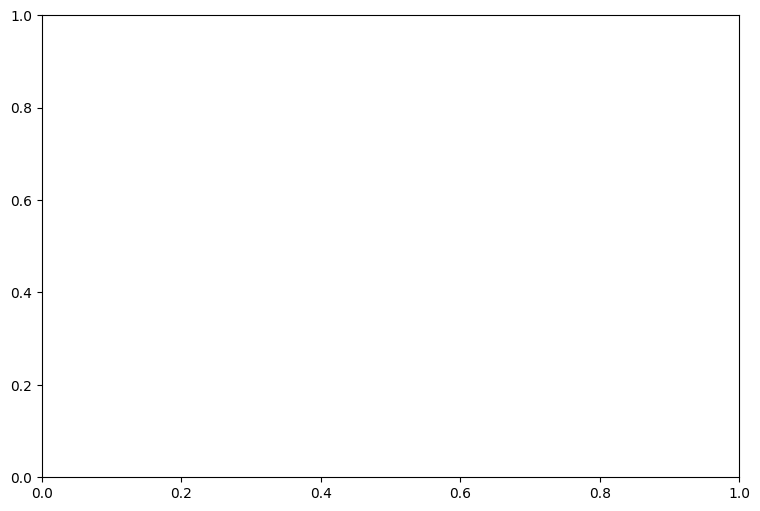

In [26]:
# ============================================================================
# CELL 34: "Money plot" — detected SLSNe redshift distribution, all 3 models
# BAND-FILL VERSION: fills only the GAP between adjacent curves (not each
# model from y=0), fixing the alpha-stacking distortion on a log axis where
# the largest-population model's fill-to-zero region visually swallowed the
# others regardless of color choice (confirmed: this was present in every
# prior version of this cell, including the original blue/orange/green —
# it was a structural property of fill-to-zero + log scale, not a color bug).
#
# Oracle-implied line per model = (ELasTiCC-detected count per z-bin) x (oracle_recall for that z-bin, from Ved's CSV).
# This is recomputed from detected counts, not pulled from Ved's N_oracle_detects column. Keeps ELasTiCC pipeline output 
# and his completeness numbers as separate, explicitly-combined sources.  Oracle_recall is only populated through z_hi=3.9 in
# Ved's CSV (confirmed via tail of naive_oracle_rates.csv). Bins beyond that are left as NaN (line simply stops) rather than assumed to be 0 or extrapolated
#
# Assumes ascending order Naive < O-dependent < Fe-dependent holds per
# z-bin (matches total N: 281k < 467k < 918k). Order-violation bins are
# clipped via np.maximum/np.minimum so the fill never inverts, and counted
# in a diagnostic printout — if nonzero, that band's model-attribution is
# ambiguous at those bins and should be inspected before trusting the plot.
#
# Naive (bottom, smallest N): outline only, no fill below it.
# Gap 1 (Naive -> O-dependent): filled with O-dependent's color.
# Gap 2 (O-dependent -> Fe-dependent): filled with Fe-dependent's color.
#
# Oracle-implied dotted lines unchanged from previous version — lightened
# per-model color, stops at z_hi=3.9 (oracle_recall coverage limit).
#
# Single cadence only: baseline_v5.3.0_10yrs.
#
# Reload flags: Templates NO — Population NO — Mag grid NO — Kernel NO
# ============================================================================

import pandas as pd
import matplotlib.colors as mcolors
import colorsys

def lighten_color(color, amount=0.45):
    """Lighten a hex/named color by blending toward white in HLS space."""
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = min(1.0, l + amount * (1.0 - l))
    return colorsys.hls_to_rgb(h, l, s)

MONEY_METRIC  = 'elasticc'
MONEY_BINS    = np.linspace(0.1, 5.0, 50)
MONEY_CADENCE = 'baseline_v5.3.0_10yrs'

# Fixed ascending order assumption — Naive < O-dependent < Fe-dependent
ORDER = ['naive_physical', 'o_dependent_physical', 'fe_dependent_physical']

ORACLE_DIR = get_output_dir('SLSNe', subdir='shared')
ORACLE_FILES = {
    'naive_physical':        ORACLE_DIR / 'naive_oracle_rates.csv',
    'o_dependent_physical':  ORACLE_DIR / 'o_dependent_oracle_rates.csv',
    'fe_dependent_physical': ORACLE_DIR / 'fe_dependent_oracle_rates.csv',
}

oracle = {}
for model, fpath in ORACLE_FILES.items():
    oracle[model] = pd.read_csv(fpath)

fig, ax = plt.subplots(1, 1, figsize=(9, 6))

detected_z  = {}
counts_by_model = {}
oracle_line = {}
bin_edges   = MONEY_BINS
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

for model in MODELS:
    sp    = pop_slicers[model].slice_points
    z_all = np.asarray(sp['z'])

    npy_path = find_latest_npy(model, MONEY_CADENCE, MONEY_METRIC)
    if npy_path is None:
        print(f'[skip] {model} / {MONEY_CADENCE} — no npy found')
        continue

    arr    = np.load(str(npy_path))
    mask_z = (z_all >= 0.1) & (z_all <= 5.0)
    if len(arr) != mask_z.sum():
        print(f'[skip] {model} / {MONEY_CADENCE} — size mismatch')
        continue

    z_subset = z_all[mask_z]
    detected_z[model] = z_subset[arr == 1]

    counts, _ = np.histogram(detected_z[model], bins=bin_edges)
    counts_by_model[model] = counts.astype(float)

    # Oracle-implied line (unchanged logic from before)
    bin_z_lo = np.round(bin_edges[:-1], 1)
    bin_z_hi = np.round(bin_edges[1:], 1)
    counts_df = pd.DataFrame({'z_lo': bin_z_lo, 'z_hi': bin_z_hi, 'count': counts})
    recall_df = oracle[model][['z_lo', 'z_hi', 'oracle_recall']].copy()
    recall_df['z_lo'] = np.round(recall_df['z_lo'], 1)
    recall_df['z_hi'] = np.round(recall_df['z_hi'], 1)
    merged = counts_df.merge(recall_df, on=['z_lo', 'z_hi'], how='left')
    oracle_implied = merged['count'] * merged['oracle_recall']
    oracle_line[model] = (bin_centers, oracle_implied.values)

# --- Diagnostic: check assumed ordering holds ---
c_naive = counts_by_model['naive_physical']
c_o     = counts_by_model['o_dependent_physical']
c_fe    = counts_by_model['fe_dependent_physical']

viol_1 = (c_o < c_naive).sum()
viol_2 = (c_fe < c_o).sum()
print(f'Order-violation bins — O-dependent < Naive: {viol_1}/{len(c_naive)}')
print(f'Order-violation bins — Fe-dependent < O-dependent: {viol_2}/{len(c_naive)}')

# --- Band fills (gap-only, clipped to avoid inversion at violation bins) ---
gap1_lo = np.minimum(c_naive, c_o)
gap1_hi = np.maximum(c_naive, c_o)
gap2_lo = np.minimum(c_o, c_fe)
gap2_hi = np.maximum(c_o, c_fe)

# fill_between needs positive values on a log axis — floor at 1 for fill only
gap1_lo_plot = np.maximum(gap1_lo, 1)
gap2_lo_plot = np.maximum(gap2_lo, 1)

# Naive's own fill — single unstacked layer
naive_floor = np.ones_like(c_naive)
ax.fill_between(bin_centers, naive_floor, np.maximum(c_naive, 1),
                step='mid', color=MODEL_COLORS['naive_physical'],
                alpha=0.30, label='_nolegend_')

# Gap 1 (Naive -> O-dependent)
ax.fill_between(bin_centers, gap1_lo_plot, np.maximum(gap1_hi, 1),
                step='mid', color=MODEL_COLORS['o_dependent_physical'],
                alpha=0.30, label='_nolegend_')

# Gap 2 (O-dependent -> Fe-dependent)
ax.fill_between(bin_centers, gap2_lo_plot, np.maximum(gap2_hi, 1),
                step='mid', color=MODEL_COLORS['fe_dependent_physical'],
                alpha=0.30, label='_nolegend_')

# --- Step outlines + z(95%) lines + Oracle-implied dotted lines ---
for model in MODELS:
    if model not in detected_z:
        continue
    z_det = detected_z[model]
    color = MODEL_COLORS[model]
    label = MODEL_LABELS[model]

    ax.hist(z_det, bins=MONEY_BINS,
            histtype='step', lw=2.0,
            color=color, label=f'{label}  (N={len(z_det):,})')

    z_sorted = np.sort(z_det)
    z95 = z_sorted[int(0.95 * len(z_sorted))]
    ax.axvline(z95, color=color, ls='--', lw=1.5, alpha=0.9,
               label=f'z(95%) = {z95:.2f}')

    bc, oracle_implied = oracle_line[model]
    light_color = lighten_color(color, amount=0.45)
    ax.plot(bc, oracle_implied, color=light_color, ls=':', lw=2.0,
            marker='o', markersize=3,
            label=f'{label} x Oracle recall')

ax.set_yscale('log')
ax.set_xlabel('Redshift z', fontsize=12)
ax.set_ylabel('Detected SLSNe-I (count, log scale)', fontsize=12)
ax.set_title(f'{CADENCE_LABELS[MONEY_CADENCE]} | ELAsTiCC + Oracle-implied', fontsize=12)
ax.set_xlim(0.1, 5.0)
ax.set_xticks(np.arange(0.2, 5.1, 0.2))
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3, which='both')

plt.suptitle(
    'Detected SLSNe-I Redshift Distribution - All 3 Models\n'
    'Band fill = gap between adjacent curves (not fill-to-zero)',
    fontsize=13, y=1.02
)
plt.tight_layout()

out_fig = get_output_dir('SLSNe') / 'money_plot_detected_redshift_bandfill.png'
plt.savefig(str(out_fig), dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()

print(f'\n=== z(95%), ELasTiCC detections, Oracle-implied totals ({CADENCE_LABELS[MONEY_CADENCE]}) ===')
for model in MODELS:
    if model not in detected_z:
        continue
    z_det = np.sort(detected_z[model])
    z95 = z_det[int(0.95 * len(z_det))]
    _, oracle_implied = oracle_line[model]
    oracle_total = np.nansum(oracle_implied)
    n_nan_bins = np.isnan(oracle_implied).sum()
    print(f'  {MODEL_LABELS[model]:15s}  z(95%) = {z95:.2f}  '
          f'N_ELasTiCC = {len(z_det):,}  '
          f'N_Oracle-implied = {oracle_total:,.0f}  '
          f'({n_nan_bins} bins beyond oracle_recall coverage)')

viol_mask = c_fe < c_o
viol_idx  = np.where(viol_mask)[0]
print("Violation bin(s):", bin_centers[viol_idx])
print("  c_o :", c_o[viol_idx])
print("  c_fe:", c_fe[viol_idx])


# NOTE: 1/49 bins (z=0.15) shows Fe-dependent < O-dependent (409 vs 425,
# ~4% diff, both within 1-sigma Poisson noise sqrt(N)~20). This is the
# lowest-z bin where all three models are still converging near zero —
# not a physical crossover. Band-fill clipping (np.maximum/np.minimum)
# handles it safely with no visual artifact. Confirmed 2026-08-07.

In [27]:
# ============================================================================
# CELL 35: Detection brightness check — ELAsTiCC, v5.3.0, all 3 models
# Peak apparent magnitude computed FRESH via synthesize_mag_at_z(), since
# the population pkl's peak_app_mag_ebv_* fields are NaN for the physical
# track (population.py's summary loop was written for GP-shaped lc_model.data
# and never extended for physical templates).
#
# "Peak" is found per-event by scanning phase and taking the minimum
# magnitude — phase=0 is NOT peak for these templates (confirmed: light
# curve rises from phase~1 to a true peak around phase~30-50, varies by
# template), so a fixed phase assumption would be wrong. phase=1.0 itself
# is a NaN edge case in the interpolator — scan starts at phase=2.0.
#
# SAMPLED, not full population: full ELAsTiCC/v5.3.0 detected set is
# 1.67M events. Sampling N_SAMPLE per model keeps this fast while still
# giving a statistically representative histogram.
#
# BACKLOG: population.py lines ~1039-1055 should be fixed to synthesize
# peak_mag_abs_* from sed_grid properly (with a real phase scan, not a
# fixed phase=0 assumption), so future population regenerations get this
# field correctly without per-plot recomputation. Not fixed today.
#
# Reload flags: Templates NO — Population NO — Mag grid NO — Kernel NO
# ============================================================================

import joblib

ELASTICC_CADENCE = 'baseline_v5.3.0_10yrs'
ELASTICC_METRIC  = 'elasticc'
PLOT_BANDS_35    = ['g']
N_SAMPLE         = 3000
RNG_SEED         = 42
PHASE_SCAN       = np.linspace(2.0, 100.0, 30)   # avoid phase=1.0 NaN edge

def find_peak_mag(sed, z, filt, phase_scan=PHASE_SCAN):
    """Scan phase, return the minimum (brightest) finite magnitude found."""
    mags = np.array([synthesize_mag_at_z(sed, phase_rest=p, z=z, filt=filt)
                      for p in phase_scan])
    finite = np.isfinite(mags)
    if finite.sum() == 0:
        return np.nan
    return float(mags[finite].min())

tpl       = joblib.load(str(get_output_dir('SLSNe', subdir='shared') / 'physical_templates.pkl'))
tpl_names = tpl['names']

rng = np.random.default_rng(RNG_SEED)

sampled_data = {}

for model in MODELS:
    sp        = pop_slicers[model].slice_points
    z_all     = np.asarray(sp['z'])
    file_indx = np.asarray(sp['file_indx'])
    mask_full = (z_all >= 0.1) & (z_all <= 5.0)

    npy_path = find_latest_npy(model, ELASTICC_CADENCE, ELASTICC_METRIC)
    arr = np.load(str(npy_path))
    det_mask = (arr == 1)
    det_idx_full = np.where(mask_full)[0][det_mask]
    n_detected   = len(det_idx_full)

    n_take  = min(N_SAMPLE, n_detected)
    sampled = rng.choice(det_idx_full, size=n_take, replace=False)

    mags = {band: [] for band in PLOT_BANDS_35}
    for i in sampled:
        sed = tpl['sed_grid'][file_indx[i]]
        z_i = z_all[i]
        for band in PLOT_BANDS_35:
            mags[band].append(find_peak_mag(sed, z_i, band))

    sampled_data[model] = {
        'mag':      {band: np.array(mags[band]) for band in PLOT_BANDS_35},
        'z':        z_all[sampled],
        'template': [tpl_names[file_indx[i]] for i in sampled],
        'n_detected_total': n_detected,
        'n_sampled': n_take,
    }
    n_finite = np.isfinite(mags['g']).sum() if 'g' in mags else 0
    print(f'{MODEL_LABELS[model]:15s}: sampled {n_take:,} of {n_detected:,} detected events '
          f'({n_finite:,} finite magnitudes)')

# --- Plot ---
fig, axes = plt.subplots(1, len(PLOT_BANDS_35), figsize=(7 * len(PLOT_BANDS_35), 5),
                          squeeze=False)
axes = axes[0]

for bi, band in enumerate(PLOT_BANDS_35):
    ax = axes[bi]
    for model in MODELS:
        mags = sampled_data[model]['mag'][band]
        mags = mags[np.isfinite(mags)]
        if len(mags) == 0:
            continue
        ax.hist(mags, bins=30, histtype='step', lw=2,
                color=MODEL_COLORS[model], label=MODEL_LABELS[model])
    ax.set_xlabel(f'{band}-band peak apparent mag (AB)', fontsize=11)
    ax.set_ylabel('Sampled detected count', fontsize=11)
    ax.set_title(f'{band}-band peak magnitude — detected events\n'
                 f'(ELAsTiCC, {CADENCE_LABELS[ELASTICC_CADENCE]}, sampled N={N_SAMPLE}/model)',
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / 'detection_brightness_sampled_elasticc_v53.png'
plt.savefig(str(out_fig), dpi=150, bbox_inches='tight')
print(f'\nSaved: {out_fig.name}')
plt.show()

IndexError: boolean index did not match indexed array along axis 0; size of axis is 2034661 but size of corresponding boolean axis is 1000000

Ratio statistic — ELAsTiCC | Baseline v5.3.0
Low-z  bin: z = 1.1–1.3
High-z bin: z = 1.6–1.8

Naive SFR        N_low=  37,443  N_high=  32,996
O-dependent      N_low=  46,900  N_high=  57,684
Fe-dependent     N_low=  85,959  N_high= 118,336

Naive SFR        R = 0.8812 ± 0.0067  (fractional err = 0.76%)
O-dependent      R = 1.2299 ± 0.0076  (fractional err = 0.62%)
Fe-dependent     R = 1.3767 ± 0.0062  (fractional err = 0.45%)

=== Model separation significance (full 10-yr survey) ===
  Fe vs Naive : 54.6σ
  O  vs Naive : 34.4σ
  Fe vs O     : 14.9σ

Saved: ratio_discriminability_elasticc_v53.png


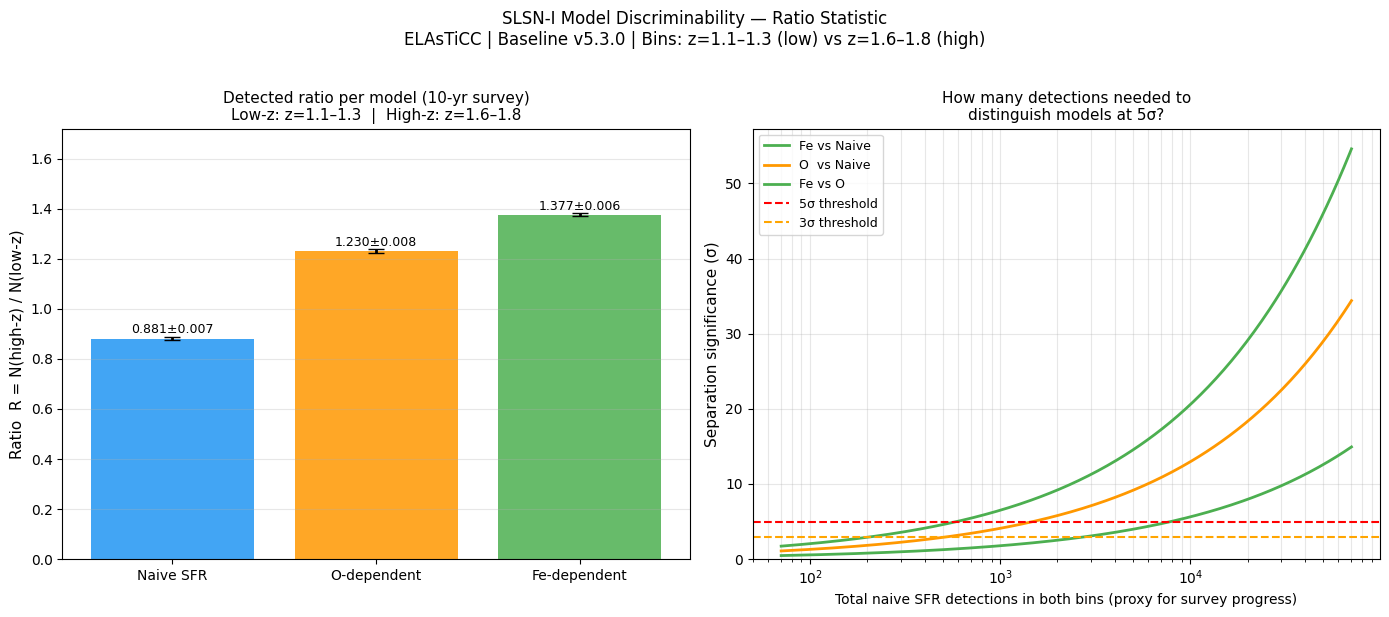


=== Minimum detections needed to reach 5σ separation ===
  Fe vs Naive : 604 detections  (survey fraction f=0.0086, ~31 days)
  O  vs Naive : 1521 detections  (survey fraction f=0.0216, ~79 days)
  Fe vs O     : 8029 detections  (survey fraction f=0.1140, ~416 days)


In [ ]:
# ============================================================================
# CELL 36: Ratio discriminability statistic — can LSST distinguish rate models?
#
# Implements Michael and Adam's ratio statistic:
#   Step 1: Count n_success in two z-bins per model (low-z and high-z)
#   Step 2: Compute ratio R = N_high/N_low and Poisson error
#           σ_R/R = sqrt(1/N_high + 1/N_low)
#   Step 3: Model separation significance
#           σ_sep = |R_A - R_B| / sqrt(σ_R_A² + σ_R_B²)
#   Step 4: "How many do you need?" — scale counts by survey fraction f,
#           find where significance crosses 5σ
#
# Bins are PLACEHOLDERS — optimize after workflow is validated.
# Metric: ELAsTiCC. Cadence: v5.3.0 (matches money plot).
# No reloads needed — uses ADAPTIVE dict from Cell 1.
#
# Science logic: the ratio R cancels the Frohmaier+2021 rate normalization
# uncertainty (R_ref appears in both bins and divides out), isolating the
# SHAPE of R(z) between models — which is the actual discriminating signal.
# Poisson counting statistics are the only remaining uncertainty source.
#
# Reload flags: Templates NO — Population NO — Mag grid NO — Kernel NO
# ============================================================================

import matplotlib.ticker as mticker

# --- Toggles ---
RATIO_CADENCE  = 'baseline_v5.3.0_10yrs'
RATIO_METRIC   = 'SLSN_ELAsTiCC_Metric'
SURVEY_YEARS_R = SURVEY_YEARS   # 10

# Placeholder bins — adjust after workflow validated
# Low-z:  where both models still accumulate well (high counts, low Poisson noise)
# High-z: where naive has fallen off but Fe-dependent hasn't
Z_LOW  = (1.1, 1.3)   # summed over z=1.1-1.2 and z=1.2-1.3
Z_HIGH = (1.6, 1.8)   # summed over z=1.6-1.7 and z=1.7-1.8

# --- Step 1: Count n_success in each bin per model ---
print(f'Ratio statistic — ELAsTiCC | {CADENCE_LABELS[RATIO_CADENCE]}')
print(f'Low-z  bin: z = {Z_LOW[0]}–{Z_LOW[1]}')
print(f'High-z bin: z = {Z_HIGH[0]}–{Z_HIGH[1]}')
print()

counts = {}   # model -> {'N_low': int, 'N_high': int}
for model in MODELS:
    df = ADAPTIVE[model]
    mask_cad    = df['cadence'] == RATIO_CADENCE
    mask_metric = df['metric']  == RATIO_METRIC

    # Low-z bin: sum n_success over all Δz=0.1 bins within Z_LOW range
    mask_low  = mask_cad & mask_metric & \
                (df['z_lo'] >= Z_LOW[0])  & (df['z_hi'] <= Z_LOW[1])
    mask_high = mask_cad & mask_metric & \
                (df['z_lo'] >= Z_HIGH[0]) & (df['z_hi'] <= Z_HIGH[1])

    N_low  = int(df[mask_low]['n_success'].sum())
    N_high = int(df[mask_high]['n_success'].sum())
    counts[model] = {'N_low': N_low, 'N_high': N_high}
    print(f'{MODEL_LABELS[model]:15s}  N_low={N_low:>8,}  N_high={N_high:>8,}')

print()

# --- Step 2: Ratio and Poisson error for full 10-year survey ---
ratios = {}
for model in MODELS:
    N_low  = counts[model]['N_low']
    N_high = counts[model]['N_high']
    R      = N_high / N_low
    sigma  = R * np.sqrt(1/N_high + 1/N_low)
    ratios[model] = {'R': R, 'sigma': sigma}
    print(f'{MODEL_LABELS[model]:15s}  R = {R:.4f} ± {sigma:.4f}  '
          f'(fractional err = {sigma/R*100:.2f}%)')

print()

# --- Step 3: Model separation significance (full 10-year survey) ---
pairs = [
    ('fe_dependent_physical', 'naive_physical',       'Fe vs Naive'),
    ('o_dependent_physical',  'naive_physical',       'O  vs Naive'),
    ('fe_dependent_physical', 'o_dependent_physical', 'Fe vs O'),
]
print('=== Model separation significance (full 10-yr survey) ===')
for m_a, m_b, label in pairs:
    R_a, s_a = ratios[m_a]['R'], ratios[m_a]['sigma']
    R_b, s_b = ratios[m_b]['R'], ratios[m_b]['sigma']
    sig = abs(R_a - R_b) / np.sqrt(s_a**2 + s_b**2)
    print(f'  {label:12s}: {sig:.1f}σ')

print()

# --- Step 4: Significance vs survey fraction ---
# Scale counts by f: N(f) = f * N_10yr, Poisson error scales as 1/sqrt(f)
# x-axis: total ELAsTiCC detections accumulated (sum across both bins, all models)
# This is more interpretable than survey fraction directly

f_grid = np.logspace(-3, 0, 300)   # 0.001 to 1.0 (log-spaced for readability)

# Total detections at full survey (both bins, one model - use as x-axis proxy)
# We use the sum of low+high bin counts for naive as the x-axis reference
# (since "how many SLSNe detected total" is what an observer would know)
total_naive_full = counts['naive_physical']['N_low'] + \
                   counts['naive_physical']['N_high']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left panel: bar chart of R +/- σ for full 10-year survey ---
ax = axes[0]
x_pos = np.arange(len(MODELS))
for xi, model in enumerate(MODELS):
    R, sigma = ratios[model]['R'], ratios[model]['sigma']
    ax.bar(xi, R, color=MODEL_COLORS[model], alpha=0.85,
           label=MODEL_LABELS[model])
    ax.errorbar(xi, R, yerr=sigma, fmt='none',
                color='black', capsize=6, lw=2)
    ax.text(xi, R + sigma + 0.002, f'{R:.3f}±{sigma:.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], fontsize=10)
ax.set_ylabel('Ratio  R = N(high-z) / N(low-z)', fontsize=11)
ax.set_title(f'Detected ratio per model (10-yr survey)\n'
             f'Low-z: z={Z_LOW[0]}–{Z_LOW[1]}  |  '
             f'High-z: z={Z_HIGH[0]}–{Z_HIGH[1]}',
             fontsize=11)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, max(r['R'] for r in ratios.values()) * 1.25)

# --- Right panel: significance vs total detections ---
ax2 = axes[1]

for m_a, m_b, label in pairs:
    # color by the "challenger" model
    color = MODEL_COLORS[m_a]
    sig_curve = []
    for f in f_grid:
        N_low_a  = f * counts[m_a]['N_low']
        N_high_a = f * counts[m_a]['N_high']
        N_low_b  = f * counts[m_b]['N_low']
        N_high_b = f * counts[m_b]['N_high']

        if N_low_a < 1 or N_high_a < 1 or N_low_b < 1 or N_high_b < 1:
            sig_curve.append(np.nan)
            continue

        R_a = N_high_a / N_low_a
        R_b = N_high_b / N_low_b
        s_a = R_a * np.sqrt(1/N_high_a + 1/N_low_a)
        s_b = R_b * np.sqrt(1/N_high_b + 1/N_low_b)
        sig_curve.append(abs(R_a - R_b) / np.sqrt(s_a**2 + s_b**2))

    # x-axis: total naive detections (both bins) — proxy for "how many SLSNe observed"
    x_det = f_grid * total_naive_full
    ax2.plot(x_det, sig_curve, lw=2, color=color, label=label)

ax2.axhline(5, color='red',    ls='--', lw=1.5, label='5σ threshold')
ax2.axhline(3, color='orange', ls='--', lw=1.5, label='3σ threshold')
ax2.set_xscale('log')
ax2.set_xlabel('Total naive SFR detections in both bins (proxy for survey progress)',
               fontsize=10)
ax2.set_ylabel('Separation significance (σ)', fontsize=11)
ax2.set_title('How many detections needed to\ndistinguish models at 5σ?',
              fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, which='both')
ax2.set_ylim(0, None)

plt.suptitle(
    f'SLSN-I Model Discriminability — Ratio Statistic\n'
    f'ELAsTiCC | {CADENCE_LABELS[RATIO_CADENCE]} | '
    f'Bins: z={Z_LOW[0]}–{Z_LOW[1]} (low) vs z={Z_HIGH[0]}–{Z_HIGH[1]} (high)',
    fontsize=12, y=1.02
)
plt.tight_layout()

out_fig = get_output_dir('SLSNe') / 'ratio_discriminability_elasticc_v53.png'
plt.savefig(str(out_fig), dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()

# --- Summary: where does each pair cross 5σ? ---
print('\n=== Minimum detections needed to reach 5σ separation ===')
for m_a, m_b, label in pairs:
    for f in f_grid:
        N_low_a  = f * counts[m_a]['N_low']
        N_high_a = f * counts[m_a]['N_high']
        N_low_b  = f * counts[m_b]['N_low']
        N_high_b = f * counts[m_b]['N_high']
        if N_low_a < 1 or N_high_a < 1 or N_low_b < 1 or N_high_b < 1:
            continue
        R_a = N_high_a / N_low_a
        R_b = N_high_b / N_low_b
        s_a = R_a * np.sqrt(1/N_high_a + 1/N_low_a)
        s_b = R_b * np.sqrt(1/N_high_b + 1/N_low_b)
        sig = abs(R_a - R_b) / np.sqrt(s_a**2 + s_b**2)
        if sig >= 5.0:
            n_det = f * total_naive_full
            print(f'  {label:12s}: {n_det:.0f} detections  '
                  f'(survey fraction f={f:.4f}, '
                  f'~{f*SURVEY_YEARS_R*365:.0f} days)')
            break

[Population Total] union grid: 49 bins. Zero-filled bins per model: {'naive_physical': 1, 'o_dependent_physical': 0, 'fe_dependent_physical': 0}
[Population Total] Order-violation — O-dependent < Naive: 1/49   Fe-dependent < O-dependent: 1/49
[ELasTiCC] union grid: 49 bins. Zero-filled bins per model: {'naive_physical': 3, 'o_dependent_physical': 1, 'fe_dependent_physical': 0}
[ELasTiCC] Order-violation — O-dependent < Naive: 0/49   Fe-dependent < O-dependent: 1/49
[Oracle] union grid: 49 bins. Zero-filled bins per model: {'naive_physical': 11, 'o_dependent_physical': 11, 'fe_dependent_physical': 11}
[Oracle] Order-violation — O-dependent < Naive: 0/49   Fe-dependent < O-dependent: 1/49
Saved: detection_funnel_tripanel_bandfill.png


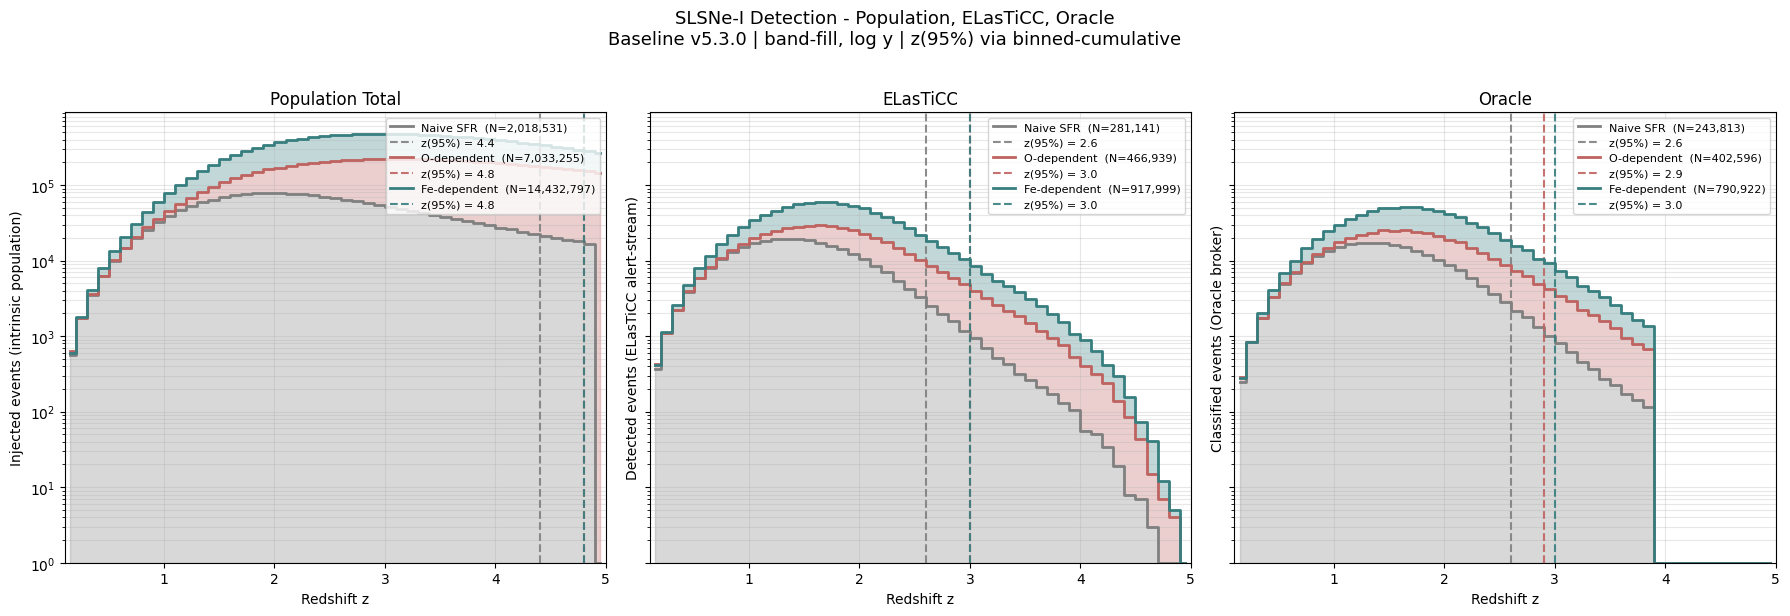

In [28]:
# ============================================================================
# CELL N (v2): Tri-panel redshift distribution — Population, ELasTiCC, Oracle
# Band-fill style (matching Cell 34): fills the GAP between adjacent curves,
# not each model from y=0.
#
# UNION-GRID ALIGNMENT: Naive stops at z_hi=4.9 (48 bins) while O-dependent
# and Fe-dependent run to z_hi=5.0 (49 bins) — Naive's adaptive run hit the
# ELasTiCC n_success==0 stopping criterion one bin earlier since its
# detections fall off first. Confirmed via bin-count comparison 2026-08-07.
# All three models are reindexed onto the UNION of z_lo/z_hi bins; missing
# bins filled with 0 (physically justified: the stopping criterion means
# "predicted ~0 here," not "unknown/unrun").
#
# z(95%): Method B (binned-cumulative) uniformly across all three panels —
# confirmed against Method A (event-level) on 2026-08-07: max delta 0.088,
# always sub-bin-width, so Method B is trustworthy.
#
# Log y-axis, shared across panels.
#
# Data sources:
#   Population: n_events from ADAPTIVE dict, filtered to SLSN_ELAsTiCC_Metric
#   ELasTiCC:   n_success from ADAPTIVE dict — SAME source as Population
#   Oracle:     N_oracle_detects from Ved's CSV
#
# Reload flags: Templates NO — Population NO — Mag grid NO — Kernel NO
# ============================================================================

import pandas as pd
import numpy as np

CADENCE_ORACLE  = 'baseline_v5.3.0_10yrs'
METRIC_ELASTICC = 'SLSN_ELAsTiCC_Metric'
Y_FLOOR = 1.0
ORDER = ['naive_physical', 'o_dependent_physical', 'fe_dependent_physical']

ORACLE_DIR = get_output_dir('SLSNe', subdir='shared')
ORACLE_FILES = {
    'naive_physical':        ORACLE_DIR / 'naive_oracle_rates.csv',
    'o_dependent_physical':  ORACLE_DIR / 'o_dependent_oracle_rates.csv',
    'fe_dependent_physical': ORACLE_DIR / 'fe_dependent_oracle_rates.csv',
}
oracle = {model: pd.read_csv(fpath) for model, fpath in ORACLE_FILES.items()}

def z95_binned_cumulative(z_lo, z_hi, counts):
    order = np.argsort(z_lo)
    z_hi_s, counts_s = z_hi[order], counts[order]
    cum = np.cumsum(counts_s)
    total = cum[-1]
    if total == 0:
        return np.nan
    idx = min(np.searchsorted(cum, 0.95 * total), len(z_hi_s) - 1)
    return z_hi_s[idx]

def get_binned_counts_raw(model, panel_source, col):
    if panel_source == 'adaptive':
        df = ADAPTIVE[model]
        df_c = df[(df['cadence'] == CADENCE_ORACLE) &
                  (df['metric']  == METRIC_ELASTICC)].sort_values('z_lo')
        z_lo, z_hi = df_c['z_lo'].values, df_c['z_hi'].values
        counts = df_c[col].values.astype(float)
    else:
        df_o = oracle[model].sort_values('z_lo')
        z_lo, z_hi = df_o['z_lo'].values, df_o['z_hi'].values
        counts = df_o[col].fillna(0).values.astype(float)
    return z_lo, z_hi, counts

def align_models_to_union_grid(panel_source, col, models=ORDER):
    """Reindex each model's counts onto the UNION of z_lo/z_hi bins across
    all models in this panel. Missing bins filled with 0."""
    per_model_raw = {}
    all_bins = set()
    for model in models:
        z_lo, z_hi, counts = get_binned_counts_raw(model, panel_source, col)
        per_model_raw[model] = pd.DataFrame({'z_lo': z_lo, 'z_hi': z_hi, 'count': counts})
        all_bins.update(zip(np.round(z_lo, 1), np.round(z_hi, 1)))

    union_df = pd.DataFrame(sorted(all_bins), columns=['z_lo', 'z_hi']).sort_values('z_lo')

    aligned = {}
    for model in models:
        df_m = per_model_raw[model].copy()
        df_m['z_lo'] = np.round(df_m['z_lo'], 1)
        df_m['z_hi'] = np.round(df_m['z_hi'], 1)
        merged = union_df.merge(df_m, on=['z_lo', 'z_hi'], how='left')
        aligned[model] = merged['count'].fillna(0.0).values

    z_lo_u = union_df['z_lo'].values
    z_hi_u = union_df['z_hi'].values
    z_mid_u = (z_lo_u + z_hi_u) / 2.0
    return z_lo_u, z_hi_u, z_mid_u, aligned

panel_configs = [
    ('Population Total', 'adaptive', 'n_events',        'Injected events (intrinsic population)'),
    ('ELasTiCC',         'adaptive', 'n_success',        'Detected events (ELasTiCC alert-stream)'),
    ('Oracle',           'oracle',   'N_oracle_detects', 'Classified events (Oracle broker)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (title, source, col, ylabel) in zip(axes, panel_configs):
    z_lo_u, z_hi_u, z_mid_ref, counts_by_model = align_models_to_union_grid(source, col)

    n_filled = {m: int((counts_by_model[m] == 0).sum()) for m in ORDER}
    print(f'[{title}] union grid: {len(z_mid_ref)} bins. Zero-filled bins per model: {n_filled}')

    c_naive = counts_by_model['naive_physical']
    c_o     = counts_by_model['o_dependent_physical']
    c_fe    = counts_by_model['fe_dependent_physical']

    viol_1 = (c_o < c_naive).sum()
    viol_2 = (c_fe < c_o).sum()
    print(f'[{title}] Order-violation — O-dependent < Naive: {viol_1}/{len(c_naive)}   '
          f'Fe-dependent < O-dependent: {viol_2}/{len(c_naive)}')

    gap1_lo = np.maximum(np.minimum(c_naive, c_o), Y_FLOOR)
    gap1_hi = np.maximum(np.maximum(c_naive, c_o), Y_FLOOR)
    gap2_lo = np.maximum(np.minimum(c_o, c_fe), Y_FLOOR)
    gap2_hi = np.maximum(np.maximum(c_o, c_fe), Y_FLOOR)
    naive_floor = np.full_like(c_naive, Y_FLOOR)

    ax.fill_between(z_mid_ref, naive_floor, np.maximum(c_naive, Y_FLOOR),
                     step='mid', color=MODEL_COLORS['naive_physical'],
                     alpha=0.30, label='_nolegend_')
    ax.fill_between(z_mid_ref, gap1_lo, gap1_hi,
                     step='mid', color=MODEL_COLORS['o_dependent_physical'],
                     alpha=0.30, label='_nolegend_')
    ax.fill_between(z_mid_ref, gap2_lo, gap2_hi,
                     step='mid', color=MODEL_COLORS['fe_dependent_physical'],
                     alpha=0.30, label='_nolegend_')

    for model in ORDER:
        color = MODEL_COLORS[model]
        label = MODEL_LABELS[model]
        counts = counts_by_model[model]

        ax.step(z_mid_ref, np.maximum(counts, Y_FLOOR), where='mid',
                color=color, lw=2.0, label=f'{label}  (N={int(counts.sum()):,})')

        z95 = z95_binned_cumulative(z_lo_u, z_hi_u, counts)
        ax.axvline(z95, color=color, ls='--', lw=1.5, alpha=0.9,
                   label=f'z(95%) = {z95:.1f}')

    ax.set_xlabel('Redshift z')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xlim(0.1, 5.0)
    ax.set_yscale('log')
    ax.set_ylim(Y_FLOOR, None)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3, which='both')

fig.suptitle('SLSNe-I Detection - Population, ELasTiCC, Oracle\n'
             f'{CADENCE_LABELS[CADENCE_ORACLE]} | band-fill, log y | z(95%) via binned-cumulative',
             fontsize=13, y=1.02)
plt.tight_layout()

out_fig = get_output_dir('SLSNe') / 'detection_funnel_tripanel_bandfill.png'
plt.savefig(str(out_fig), dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()

Saved: cumulative_duration_tripanel.png


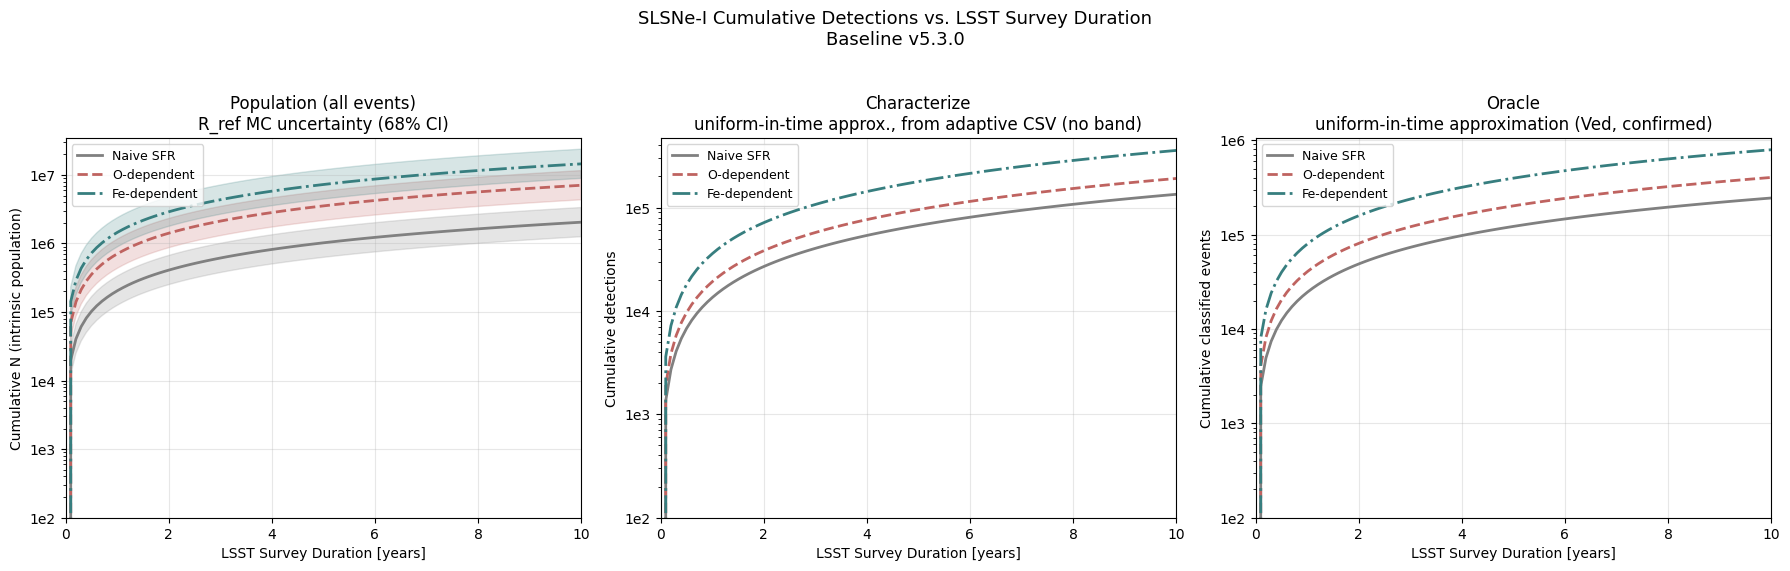

In [32]:
# ============================================================================
# CELL N (PRODUCTION VERSION v2): Cumulative detections vs LSST survey duration
# Three panels: Population (MC uncertainty band) | Characterize (no band) |
# Oracle (uniform-in-time approximation). All three panels: baseline_v5.3.0_10yrs.
#
# Panel 2 now uses ADAPTIVE CSV (n_success per z-bin), NOT npy files —
# confirmed via past-session diagnosis (2026-08-09): full-range npy files
# were built with --max-events 1000000, randomly subsampling the true
# population before running MAF (undercounts up to 14x for fe_dependent,
# 2x for naive). Adaptive CSVs always use the full uncapped population per
# z-bin, so they're the correct source. Same uniform-in-time-per-bin
# approximation already used for the Oracle panel — trades per-event
# peak_time precision for correctness against the real population size.
#
# Reload flags: Templates NO — Population NO — Mag grid NO — Kernel NO
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from slsn_metrics.diagnostics import _sample_R_ref

def sci_notation_formatter(y, pos):
    if y == 0:
        return '0'
    exponent = int(np.floor(np.log10(abs(y))))
    mantissa = y / 10**exponent
    if mantissa == int(mantissa):
        return f'{int(mantissa)}e{exponent}'
    return f'{mantissa:.1f}e{exponent}'

R_REF_NOMINAL     = 35.0
N_REALIZATIONS    = 1000
SEED              = 42
DURATION_CADENCE  = 'baseline_v5.3.0_10yrs'
MIDDLE_METRIC_KEY = 'characterize'   # short key, matches METRIC_MAP
survey_years      = np.linspace(0, SURVEY_YEARS, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True)
ax_pop, ax_mid, ax_oracle = axes

pop_medians, pop_lo16, pop_hi84 = {}, {}, {}
mid_cumulative = {}
oracle_cumulative = {}

for model in MODELS:
    short = model.replace('_physical', '')
    if short not in pop_data_mc:
        print(f'[skip] {model} — not in pop_data_mc')
        continue

    md = pop_data_mc[short]
    peak_times = md['peak_time']
    n_injected = len(peak_times)

    # --- Panel 1: Population, all events, MC band ---
    R_samples = _sample_R_ref(N_REALIZATIONS, R_mode=R_REF_NOMINAL, seed=SEED)
    V_ref = n_injected / R_REF_NOMINAL
    base_cumulative_pop = np.array([
        (peak_times <= yr * 365.25).sum() for yr in survey_years
    ], dtype=float)
    efficiency_t_pop = base_cumulative_pop / n_injected
    mc_mat_pop = efficiency_t_pop[None, :] * R_samples[:, None] * V_ref

    pop_medians[model] = np.median(mc_mat_pop, axis=0)
    pop_lo16[model]    = np.percentile(mc_mat_pop, 16, axis=0)
    pop_hi84[model]    = np.percentile(mc_mat_pop, 84, axis=0)

    # --- Panel 2: Characterize, from ADAPTIVE CSV (full population, no cap) ---
    # Uniform-in-time-per-total approximation — same style as Oracle panel.
    df_adap  = ADAPTIVE[model]
    mask_cad = df_adap['cadence'] == DURATION_CADENCE
    mask_met = df_adap['metric']  == METRIC_MAP[MIDDLE_METRIC_KEY]
    df_mid   = df_adap[mask_cad & mask_met].sort_values('z_lo')

    if len(df_mid) == 0:
        print(f'[skip] {model} — no adaptive rows for {MIDDLE_METRIC_KEY}/{DURATION_CADENCE}')
    else:
        n_success_total = df_mid['n_success'].sum()
        mid_cumulative[model] = n_success_total * (survey_years / SURVEY_YEARS)

    # --- Panel 3: Oracle, uniform-in-time ramp ---
    total_oracle = oracle[model]['N_oracle_detects'].fillna(0).sum()
    cumul_oracle = total_oracle * (survey_years / SURVEY_YEARS)
    oracle_cumulative[model] = cumul_oracle

# --- Plot Panel 1 ---
for model in MODELS:
    if model not in pop_medians:
        continue
    color = MODEL_COLORS[model]
    ax_pop.fill_between(survey_years, pop_lo16[model], pop_hi84[model],
                         color=color, alpha=0.20)
    ax_pop.plot(survey_years, pop_medians[model], color=color,
                ls=MODEL_LINESTYLES[model], lw=2.0,
                label=f'{MODEL_LABELS[model]}')
ax_pop.set_title('Population (all events)\nR_ref MC uncertainty (68% CI)')
ax_pop.set_ylabel('Cumulative N (intrinsic population)')

# --- Plot Panel 2 (RESTORED) ---
for model in MODELS:
    if model not in mid_cumulative:
        continue
    color = MODEL_COLORS[model]
    ax_mid.plot(survey_years, mid_cumulative[model], color=color,
                ls=MODEL_LINESTYLES[model], lw=2.0,
                label=f'{MODEL_LABELS[model]}')
ax_mid.set_title('Characterize\nuniform-in-time approx., from adaptive CSV (no band)')
ax_mid.set_ylabel('Cumulative detections')
if not mid_cumulative:
    ax_mid.text(0.5, 0.5, 'No data', transform=ax_mid.transAxes,
                ha='center', va='center', fontsize=11, color='gray', style='italic')

# --- Plot Panel 3 ---
for model in MODELS:
    if model not in oracle_cumulative:
        continue
    color = MODEL_COLORS[model]
    ax_oracle.plot(survey_years, oracle_cumulative[model], color=color,
                   ls=MODEL_LINESTYLES[model], lw=2.0,
                   label=f'{MODEL_LABELS[model]}')
ax_oracle.set_title('Oracle\nuniform-in-time approximation (Ved, confirmed)')
ax_oracle.set_ylabel('Cumulative classified events')

for ax in axes:
    ax.set_xlabel('LSST Survey Duration [years]')
    ax.set_xlim(0, SURVEY_YEARS)
    ax.set_yscale('log')
    ax.set_ylim(bottom=100)  # avoid log(0) at survey start
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(sci_notation_formatter))

fig.suptitle('SLSNe-I Cumulative Detections vs. LSST Survey Duration\n'
             f'{CADENCE_LABELS[DURATION_CADENCE]}',
             fontsize=13, y=1.03)
plt.tight_layout()

out_fig = get_output_dir('SLSNe') / 'cumulative_duration_tripanel.png'
plt.savefig(str(out_fig), dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()

## Scratch / Diagnostics

In [ ]:
# Cell 32 - Quick diagnostic plot — before vs after median normalization
# For email to Michael showing effect of ii)
import matplotlib.pyplot as plt
import numpy as np
import joblib
import sys
sys.path.insert(0, str(REPO / 'py_files'))
from slsn_metrics.model import synthesize_mag_at_z

# --- Recompute from pipeline ---
_tpl  = joblib.load(str(get_output_dir('SLSNe', subdir='shared') / 'physical_templates.pkl'))
_sg   = _tpl['sed_grid']

z_test, phase_test, filt_test = 0.5, 29.0, 'g'

_mags = []
_peak_fnu = []
for _i in range(265):
    _entry = _sg[_i]
    _m = synthesize_mag_at_z(_entry, phase_test, z_test, filt_test)
    _mags.append(_m)
    _fnu   = _entry['Fnu_abs']
    _total = _fnu.sum(axis=1)
    _valid = _total > 0
    if _valid.sum() > 0:
        _peak_fnu.append(float(_fnu[_valid][np.argmax(_total[_valid])].max()))
    else:
        _peak_fnu.append(np.nan)

_mags     = np.array(_mags)
_peak_fnu = np.array(_peak_fnu)
_finite   = np.isfinite(_mags)
_median_fnu  = np.nanmedian(_peak_fnu)
_norm_factors = _median_fnu / _peak_fnu
_delta_mag    = -2.5 * np.log10(_norm_factors)
_mags_normed  = _mags + _delta_mag
_finite_n     = np.isfinite(_mags_normed)

print(f'Recomputed: {_finite.sum()}/265 finite mags at z={z_test}, phase={phase_test}d, {filt_test}-band')
print(f'Median peak Fnu: {_median_fnu:.3e} Jy')
print(f'Events brighter than 23.0 (before): {(_mags[_finite] < 23.0).sum()}')
print(f'Events brighter than 23.0 (after):  {(_mags_normed[_finite_n] < 23.0).sum()}')

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(_mags[_finite], bins=30, alpha=0.6, color='#2196F3',
         label='Current (individual luminosities)')
ax1.hist(_mags_normed[_finite_n], bins=30, alpha=0.6, color='#e67e22',
         label='Normalized to median peak Fnu')
ax1.axvline(23.0, color='red', ls='--', lw=1.5, label='SpecTrigger limit (23.0)')
ax1.axvline(24.5, color='gray', ls=':', lw=1.5, label='LSST single-visit depth (~24.5)')
ax1.set_xlabel('g-band apparent mag at z=0.5, phase=29d', fontsize=11)
ax1.set_ylabel('N events', fontsize=11)
ax1.set_title('Effect of median peak flux normalization\n(z=0.5, phase=29d, g-band)', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

_sc = ax2.scatter(_peak_fnu[_finite], _mags[_finite],
                  c=_delta_mag[_finite], cmap='RdBu', s=20, alpha=0.8,
                  vmin=-4, vmax=4)
ax2.axhline(23.0, color='red', ls='--', lw=1.5, label='SpecTrigger limit')
ax2.axhline(24.5, color='gray', ls=':', lw=1.5, label='LSST depth')
ax2.axvline(float(_median_fnu), color='orange', ls='-', lw=1.5,
            label=f'Median Fnu ({_median_fnu:.1e} Jy)')
plt.colorbar(_sc, ax=ax2, label='Δmag from normalization\n(blue=brightened, red=fainted)')
ax2.set_xlabel('Peak Fnu at 10 pc (Jy)', fontsize=11)
ax2.set_ylabel('g-band apparent mag at z=0.5', fontsize=11)
ax2.set_title('Peak luminosity vs apparent mag\n(color = normalization shift)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.invert_yaxis()

plt.suptitle('Median peak flux normalization — 265 Gómez+2024 events', fontsize=12)
plt.tight_layout()
out_fig = get_output_dir('SLSNe') / 'median_norm_diagnostic.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()